<a href="https://colab.research.google.com/github/pineapple-666/Veritus-Augustin-Hackathon/blob/main/notebook/Combined_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
sns.set()
from sklearn.linear_model import LinearRegression
from scipy import stats  # for mode
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
staff_path = '/content/drive/My Drive/MESA/AI/Veritus/Staff_Survey_anonymized.csv'
staff = pd.read_csv(staff_path, header=0).drop(['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'RecordedDate'], axis=1)
staff.head(5)

,Finished,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q2.3_1,...,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5
0,Finished,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,What should Augustin College actively seek to ...,...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,Are there any other ideas or priorities you be...,"As you look ahead, how can Augustin College be...","Looking forward, how can Augustin College cult..."
1,"{""ImportId"":""finished""}","{""ImportId"":""QID21_1""}","{""ImportId"":""QID21_2""}","{""ImportId"":""QID21_3""}","{""ImportId"":""QID21_4""}","{""ImportId"":""QID21_5""}","{""ImportId"":""QID21_6""}","{""ImportId"":""QID21_7""}","{""ImportId"":""QID21_8""}","{""ImportId"":""QID45_1""}",...,"{""ImportId"":""QID39_3""}","{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}","{""ImportId"":""QID46_TEXT""}","{""ImportId"":""QID47_TEXT""}"
2,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TRUE,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,4,...,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important,NaN,NaN,NaN
4,TRUE,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,1,...,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,NaN,Increase emphasis on policy and procedure inte...,Streamline communication with all staff member...


In [4]:
faculty_path = '/content/drive/My Drive/MESA/AI/Veritus/Faculty_Survey_anonymized.csv'
faculty = pd.read_csv(faculty_path, header=0).drop(['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'RecordedDate'], axis=1)
faculty.head(5)

,Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q2.2_1,Q2.2_2,Q2.2_3,...,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5,Q5.6
0,Finished,What is your gender?,What is your race/ethnicity?,How many years have you been teaching for Augu...,What Augustin College programs do you teach in?,Which undergraduate programs do you currently ...,Which graduate programs do you currently teach...,How important are the following aspects for pr...,How important are the following aspects for pr...,How important are the following aspects for pr...,...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,Are there any other ideas or priorities you be...,How can Augustin College support you better in...,How can Augustin College cultivate a stronger ...,"In the future, how can Augustin College cultiv..."
1,"{""ImportId"":""finished""}","{""ImportId"":""QID1""}","{""ImportId"":""QID5""}","{""ImportId"":""QID10_TEXT""}","{""ImportId"":""QID15""}","{""ImportId"":""QID17""}","{""ImportId"":""QID44""}","{""ImportId"":""QID21_1""}","{""ImportId"":""QID21_2""}","{""ImportId"":""QID21_3""}",...,"{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}","{""ImportId"":""QID46_TEXT""}","{""ImportId"":""QID47_TEXT""}","{""ImportId"":""QID48_TEXT""}"
2,TRUE,Female,Asian,1,Undergraduate Programs,Undergrad Program 1,NaN,Very important,Extremely important,Very important,...,Very important,Very important,Very important,Very important,Very important,Very important,Importance of environmental sustainability and...,Better career advancement,Organize more team building events,Organize more team building events
3,TRUE,Female,White,4,Graduate Programs,NaN,Graduate Program 1,Very important,Extremely important,Extremely important,...,Moderately important,Very important,Very important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
4,TRUE,Male,White,8,Undergraduate Programs,Undergrad Program 2,NaN,Very important,Very important,Extremely important,...,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,NaN,NaN,NaN,NaN


In [5]:
student_path = '/content/drive/My Drive/MESA/AI/Veritus/Student_Survey_anonymized.csv'
# Try common encodings
student = pd.read_csv(student_path, encoding='ISO-8859-1', header=0).drop(['Progress', 'Duration (in seconds)'], axis=1)
student.head(5)


,Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q1.9,Q1.10,Q1.11,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3
0,Finished,What is your gender?,What is your age?,Are you an international student?,What is your race/ethnicity?,Are you the first person in your family to att...,Do you identify as a person with a disability?,Are you currently serving in the U.S. military...,Where do you currently live while attending Au...,Do you have previous work experience (excludin...,...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,How important should each of the following ide...,Are there any other ideas or priorities you be...
1,"{""ImportId"":""finished""}","{""ImportId"":""QID1""}","{""ImportId"":""QID3_TEXT""}","{""ImportId"":""QID4""}","{""ImportId"":""QID5""}","{""ImportId"":""QID6""}","{""ImportId"":""QID7""}","{""ImportId"":""QID8""}","{""ImportId"":""QID9""}","{""ImportId"":""QID10""}",...,"{""ImportId"":""QID39_1""}","{""ImportId"":""QID39_2""}","{""ImportId"":""QID39_3""}","{""ImportId"":""QID39_4""}","{""ImportId"":""QID39_5""}","{""ImportId"":""QID39_6""}","{""ImportId"":""QID39_7""}","{""ImportId"":""QID39_8""}","{""ImportId"":""QID39_9""}","{""ImportId"":""QID40_TEXT""}"
2,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TRUE,Female,21,No,White,Yes,No,No,With family or relatives,"Yes, less than 5 years",...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,NaN
4,TRUE,Male,19,No,Hispanic or Latino,No,No,No,With family or relatives,No,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,NaN


In [6]:
student = pd.read_csv(student_path, encoding='ISO-8859-1')
student_cleaned = student.drop(index=[0, 1]).reset_index(drop=True)
student_cleaned.head()

,Progress,Duration (in seconds),Finished,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q1.9,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3
0,100,84,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100,795,TRUE,Female,21,No,White,Yes,No,No,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,NaN
2,100,832,TRUE,Male,19,No,Hispanic or Latino,No,No,No,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,NaN
3,100,736,TRUE,Male,43,No,White,Yes,No,No,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,NaN
4,100,300,TRUE,Male,35,No,Asian,No,No,No,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,NaN


In [7]:
# Step 1: Extract the first row from each dataset
staff_row = staff.iloc[0]
student_row = student.iloc[0]
faculty_row = faculty.iloc[0]

# Step 2: Find the shared values among the three first rows
common_values = set(staff_row) & set(student_row) & set(faculty_row)

# Step 3: Print the column name and value for shared items (based on staff’s columns)
print("Shared columns (header + value) in the first row across all three datasets:\n")
for col, val in staff_row.items():
    if val in common_values:
        print(f"{col}: {val}")


Shared columns (header + value) in the first row across all three datasets:

Finished: Finished
Q3.2_1: How important are the following aspects to the future learning experience at Augustin College? - Small class sizes and individualized attention
Q3.2_2: How important are the following aspects to the future learning experience at Augustin College? - Experiential learning opportunities (e.g., internships, client projects)
Q3.2_3: How important are the following aspects to the future learning experience at Augustin College? - Courses that develop leadership and communication skills
Q3.2_4: How important are the following aspects to the future learning experience at Augustin College? - In-person learning opportunities
Q3.2_5: How important are the following aspects to the future learning experience at Augustin College? - Daytime course offerings
Q3.2_6: How important are the following aspects to the future learning experience at Augustin College? - Online synchronous learning opportuniti

In [8]:
# Get the list of common column names and sort them alphabetically
common_columns = sorted(list(set(staff.columns) & set(student.columns) & set(faculty.columns)))

# Set pandas display options to show all rows
pd.set_option('display.max_rows', None)

# Iterate through each common column and print the first row value for each dataset
for col in common_columns:
    print(f"--- Column: {col} ---")
    print(f"Student: {student.iloc[0][col]}")
    print(f"Faculty: {faculty.iloc[0][col]}")
    print(f"Staff: {staff.iloc[0][col]}")
    print("-" * 10) # Separator for readability

# Reset pandas display options to default
pd.reset_option('display.max_rows')

--- Column: Finished ---
Student: Finished
Faculty: Finished
Staff: Finished
----------
--- Column: Q2.2_1 ---
Student: How important are the following aspects for promoting Augustin College to future students? - Flexible learning Options (e.g., online, evening, hybrid)
Faculty: How important are the following aspects for promoting Augustin College to future students?* - Flexible learning Options (e.g., online, evening, hybrid)
Staff: How important are the following aspects for promoting Augustin College to future students?* - Flexible learning Options (e.g., online, evening, hybrid)
----------
--- Column: Q2.2_2 ---
Student: How important are the following aspects for promoting Augustin College to future students? - Career-focused programs aligned with workforce needs
Faculty: How important are the following aspects for promoting Augustin College to future students?* - Career-focused programs aligned with workforce needs
Staff: How important are the following aspects for promoting Aug

In [9]:
# Select all columns that match your desired ranges
cols_to_keep = (
    [f'Q2.2_{i}' for i in range(1, 9)] +     # Q2.2_1 to Q2.2_8
    [f'Q4.6_{i}' for i in range(1, 9)] +     # Q4.6_1 to Q4.6_8
    [f'Q5.2_{i}' for i in range(1, 10)]      # Q5.2_1 to Q5.2_9
)

# Filter your DataFrame
student_subset = student_cleaned[cols_to_keep]

# Preview result
student_subset.head()


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Very important,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Extremely important,Extremely important,...,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,...,Extremely important,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Very important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important


In [10]:
student_subset.shape

(220, 25)

In [11]:
#student_subset.dtypes

In [12]:
student_subset['dataset'] = 'student'
student_subset.head()

/tmp/ipython-input-1603133406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_subset['dataset'] = 'student'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,student
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Extremely important,Extremely important,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,student


In [13]:
satff = pd.read_csv(staff_path)
staff_cleaned = staff.drop(index=[0, 1]).reset_index(drop=True)
staff_cleaned.head()

,Finished,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q2.3_1,...,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5
0,TRUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TRUE,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,4,...,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important,NaN,NaN,NaN
2,TRUE,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,1,...,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,NaN,Increase emphasis on policy and procedure inte...,Streamline communication with all staff member...
3,TRUE,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,1,...,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important,More hands-on opportunities for community enga...,"Please continue the good transparency, communi...",I think we should continue doing the kinds of ...
4,FALSE,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
staff.shape

(22, 95)

In [15]:
# Filter your DataFrame
staff_subset = staff_cleaned[cols_to_keep]

# Preview result
staff_subset.head()

,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,Extremely important,Extremely important,...,Extremely important,Moderately important,Extremely important,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important
2,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,...,Extremely important,Moderately important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important
3,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Very important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important
4,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
staff_subset.shape
#staff_subset.dtypes

(20, 25)

In [17]:
student_subset['dataset'] = 'student'
student_subset.head()

/tmp/ipython-input-1603133406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_subset['dataset'] = 'student'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,student
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Extremely important,Extremely important,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,student


In [18]:
staff_subset['dataset'] = 'staff'
staff_subset.head()

/tmp/ipython-input-2478255036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staff_subset['dataset'] = 'staff'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,staff
1,Extremely important,Extremely important,Extremely important,Moderately Important,Very important,Moderately Important,Very important,Moderately Important,Extremely important,Extremely important,...,Moderately important,Extremely important,Moderately important,Extremely important,Extremely important,Moderately important,Very important,Moderately important,Extremely important,staff
2,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,...,Moderately important,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,staff
3,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Extremely important,Extremely important,...,Extremely important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Extremely important,Very important,staff
4,Extremely important,Extremely important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,Very important,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,staff


In [19]:
faculty = pd.read_csv(faculty_path)
faculty_cleaned = faculty.drop(index=[0, 1]).reset_index(drop=True)
faculty_cleaned.head()

,StartDate,EndDate,Progress,Duration (in seconds),Finished,RecordedDate,Q1.3,Q1.4,Q1.5,Q1.6,...,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,Q5.3,Q5.4,Q5.5,Q5.6
0,5/8/2025 15:03,5/8/2025 15:14,100,663,TRUE,5/8/2025 15:14,Female,Asian,1,Undergraduate Programs,...,Very important,Very important,Very important,Very important,Very important,Very important,Importance of environmental sustainability and...,Better career advancement,Organize more team building events,Organize more team building events
1,5/8/2025 15:07,5/8/2025 15:14,100,418,TRUE,5/8/2025 15:14,Female,White,4,Graduate Programs,...,Moderately important,Very important,Very important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
2,5/8/2025 15:08,5/8/2025 15:20,100,721,TRUE,5/8/2025 15:20,Male,White,8,Undergraduate Programs,...,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,NaN,NaN,NaN,NaN
3,5/8/2025 15:13,5/8/2025 15:20,100,428,TRUE,5/8/2025 15:21,Female,"American Indian or Alaska Native,White",8,"Undergraduate Programs,Graduate Programs",...,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important,NaN,NaN,NaN,NaN
4,5/8/2025 15:17,5/8/2025 15:22,100,305,TRUE,5/8/2025 15:22,Male,White,3,Graduate Programs,...,Slightly important,Very important,Very important,Very important,Very important,Very important,No,All is good right now.,NaN,NaN


In [20]:
faculty.shape

(114, 108)

In [21]:
# Filter your DataFrame
faculty_subset = faculty_cleaned[cols_to_keep]

# Preview result
faculty_subset.head()

,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q4.6_8,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9
0,Very important,Extremely important,Very important,Moderately Important,Very important,Very important,Very important,Extremely important,Very important,Very important,...,NaN,Not at all important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important
1,Very important,Extremely important,Extremely important,Moderately Important,Very important,Very important,Moderately Important,Extremely important,Very important,Very important,...,Extremely important,Moderately important,Very important,Extremely important,Moderately important,Very important,Very important,Very important,Very important,Extremely important
2,Very important,Very important,Extremely important,Moderately Important,Moderately Important,Very important,Very important,Very important,Very important,Very important,...,Very important,Extremely important,Very important,Very important,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important
3,Extremely important,Extremely important,Very important,Very important,Extremely important,Very important,Extremely important,Very important,Extremely important,Extremely important,...,Extremely important,Moderately important,Extremely important,Moderately important,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important
4,Very important,Extremely important,Very important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Very important,Moderately important,...,Very important,Very important,NaN,Moderately important,Slightly important,Very important,Very important,Very important,Very important,Very important


In [22]:
faculty_subset.shape
#faculty_subset.dtypes

(112, 25)

In [23]:
faculty_subset['dataset'] = 'faculty'
faculty_subset.head()

/tmp/ipython-input-3646259319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faculty_subset['dataset'] = 'faculty'


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,Very important,Extremely important,Very important,Moderately Important,Very important,Very important,Very important,Extremely important,Very important,Very important,...,Not at all important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,faculty
1,Very important,Extremely important,Extremely important,Moderately Important,Very important,Very important,Moderately Important,Extremely important,Very important,Very important,...,Moderately important,Very important,Extremely important,Moderately important,Very important,Very important,Very important,Very important,Extremely important,faculty
2,Very important,Very important,Extremely important,Moderately Important,Moderately Important,Very important,Very important,Very important,Very important,Very important,...,Extremely important,Very important,Very important,Moderately important,Very important,Very important,Moderately important,Slightly important,Very important,faculty
3,Extremely important,Extremely important,Very important,Very important,Extremely important,Very important,Extremely important,Very important,Extremely important,Extremely important,...,Moderately important,Extremely important,Moderately important,Moderately important,Extremely important,Extremely important,Very important,Very important,Extremely important,faculty
4,Very important,Extremely important,Very important,Extremely important,Extremely important,Moderately Important,Extremely important,Extremely important,Very important,Moderately important,...,Very important,NaN,Moderately important,Slightly important,Very important,Very important,Very important,Very important,Very important,faculty


In [24]:
# Check column names
print("Student columns:", list(student_subset.columns))
print("Faculty columns:", list(faculty_subset.columns))
print("Staff columns:", list(staff_subset.columns))


Student columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']
Faculty columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']
Staff columns: ['Q2.2_1', 'Q2.2_2', 'Q2.2_3', 'Q2.2_4', 'Q2.2_5', 'Q2.2_6', 'Q2.2_7', 'Q2.2_8', 'Q4.6_1', 'Q4.6_2', 'Q4.6_3', 'Q4.6_4', 'Q4.6_5', 'Q4.6_6', 'Q4.6_7', 'Q4.6_8', 'Q5.2_1', 'Q5.2_2', 'Q5.2_3', 'Q5.2_4', 'Q5.2_5', 'Q5.2_6', 'Q5.2_7', 'Q5.2_8', 'Q5.2_9', 'dataset']


In [25]:
# Compare column sets
columns_match = (list(student_subset.columns) == list(faculty_subset.columns) == list(staff_subset.columns))
print("Do all three datasets have the same columns?", columns_match)

Do all three datasets have the same columns? True


In [26]:
combined_df = pd.concat([student_subset, faculty_subset, staff_subset], ignore_index=True)
combined_df.head()
#combined_df.shape


,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately Important,Very important,Very important,Very important,Moderately Important,Moderately Important,Very important,Very important,Moderately important,Moderately important,...,Moderately important,Moderately important,Moderately important,Very important,Very important,Very important,Extremely important,Very important,Very important,student
2,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Extremely important,Extremely important,...,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Extremely important,Very important,Very important,Moderately Important,Very important,Extremely important,Extremely important,Extremely important,Very important,Extremely important,...,Slightly important,Extremely important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,student
4,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,Very important,...,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,student


In [27]:
combined_df.shape

(352, 26)

In [28]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Q2.2_1   334 non-null    object
 1   Q2.2_2   333 non-null    object
 2   Q2.2_3   332 non-null    object
 3   Q2.2_4   333 non-null    object
 4   Q2.2_5   333 non-null    object
 5   Q2.2_6   330 non-null    object
 6   Q2.2_7   334 non-null    object
 7   Q2.2_8   334 non-null    object
 8   Q4.6_1   305 non-null    object
 9   Q4.6_2   306 non-null    object
 10  Q4.6_3   307 non-null    object
 11  Q4.6_4   306 non-null    object
 12  Q4.6_5   307 non-null    object
 13  Q4.6_6   307 non-null    object
 14  Q4.6_7   306 non-null    object
 15  Q4.6_8   303 non-null    object
 16  Q5.2_1   304 non-null    object
 17  Q5.2_2   303 non-null    object
 18  Q5.2_3   304 non-null    object
 19  Q5.2_4   304 non-null    object
 20  Q5.2_5   303 non-null    object
 21  Q5.2_6   304 non-null    object
 22  Q5

In [29]:
# Step 1: Define mapping dictionary
importance_mapping = {
    'Not at all important': 1,
    'Slightly important': 2,
    'Moderately Important': 3,
    'moderately important': 3,
    'Very important': 4,
    'Extremely important': 5
}

# Step 2: Prepare lowercase mapping for robustness
mapping_lower = {k.lower(): v for k, v in importance_mapping.items()}

# Step 3: Function to map text to number
def map_importance(x):
    if pd.isna(x):
        return x  # keep NaN as is
    x_clean = str(x).strip().lower()  # remove extra spaces and lowercase
    return mapping_lower.get(x_clean, x)  # map if exists, else keep original

# Step 4: Select columns to map (all except the last one)
cols_to_map = combined_df.columns[:-1]

# Step 5: Apply mapping to all selected columns
combined_df[cols_to_map] = combined_df[cols_to_map].applymap(map_importance)

# Step 6: Optional - check unique values per column to verify mapping
for col in cols_to_map:
    print(col, combined_df[col].unique())


Q2.2_1 [nan  3.  4.  5.  2.  1.]
Q2.2_2 [nan  4.  5.  3.  2.  1.]
Q2.2_3 [nan  4.  5.  2.  3.  1.]
Q2.2_4 [nan  4.  3.  5.  2.  1.]
Q2.2_5 [nan  3.  4.  5.  1.  2.]
Q2.2_6 [nan  3.  4.  5.  1.  2.]
Q2.2_7 [nan  4.  5.  2.  3.  1.]
Q2.2_8 [nan  4.  5.  3.  2.  1.]
Q4.6_1 [nan  3.  5.  4.  2.  1.]
Q4.6_2 [nan  3.  5.  4.  2.  1.]
Q4.6_3 [nan  3.  5.  4.  2.  1.]
Q4.6_4 [nan  4.  5.  3.  2.  1.]
Q4.6_5 [nan  4.  5.  2.  3.  1.]
Q4.6_6 [nan  4.  5.  2.  3.  1.]
Q4.6_7 [nan  5.  4.  3.  2.  1.]
Q4.6_8 [nan  4.  5.  3.  2.  1.]
Q5.2_1 [nan  3.  4.  2.  5.  1.]
Q5.2_2 [nan  3.  4.  5.  2.  1.]
Q5.2_3 [nan  3.  4.  5.  2.  1.]
Q5.2_4 [nan  4.  3.  1.  5.  2.]
Q5.2_5 [nan  4.  3.  5.  2.  1.]
Q5.2_6 [nan  4.  3.  5.  2.  1.]
Q5.2_7 [nan  5.  4.  3.  2.  1.]
Q5.2_8 [nan  4.  3.  5.  2.  1.]
Q5.2_9 [nan  4.  3.  5.  2.  1.]


/tmp/ipython-input-1727853944.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined_df[cols_to_map] = combined_df[cols_to_map].applymap(map_importance)


In [30]:
combined_df.sample(3)

,Q2.2_1,Q2.2_2,Q2.2_3,Q2.2_4,Q2.2_5,Q2.2_6,Q2.2_7,Q2.2_8,Q4.6_1,Q4.6_2,...,Q5.2_1,Q5.2_2,Q5.2_3,Q5.2_4,Q5.2_5,Q5.2_6,Q5.2_7,Q5.2_8,Q5.2_9,dataset
179,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,student
348,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,4.0,4.0,4.0,5.0,5.0,5.0,4.0,4.0,staff
349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,staff


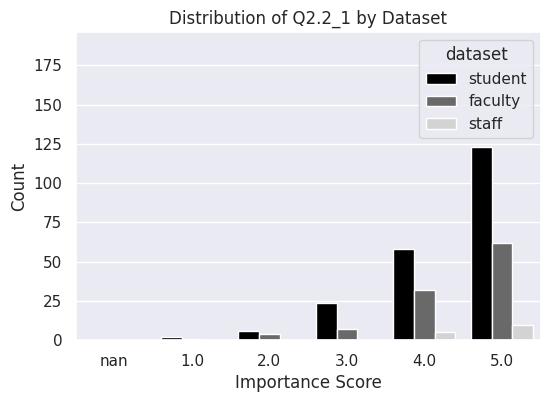

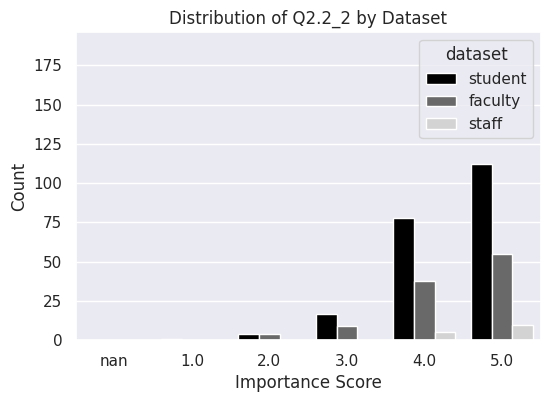

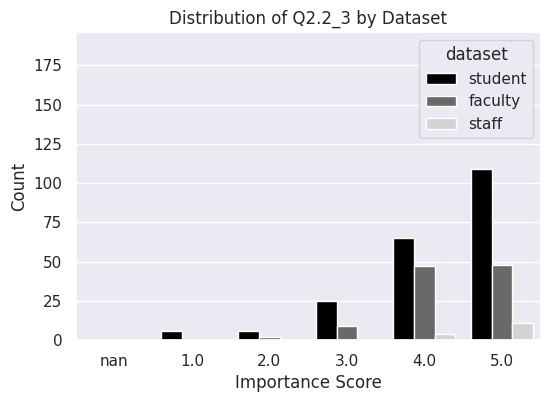

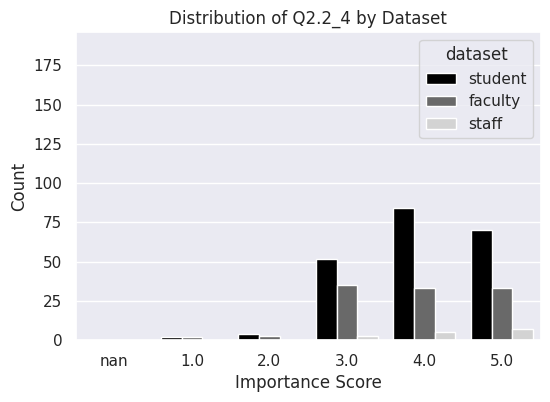

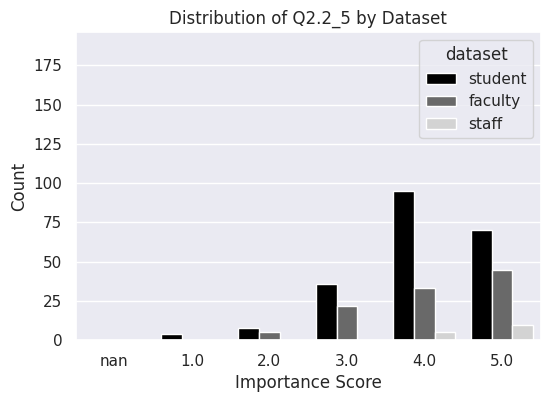

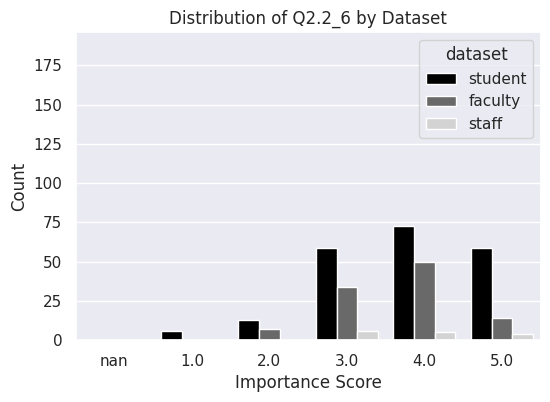

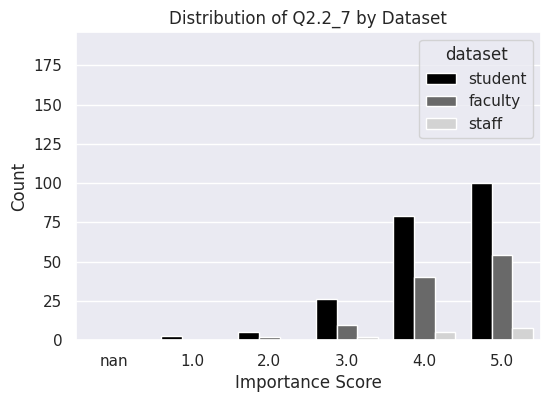

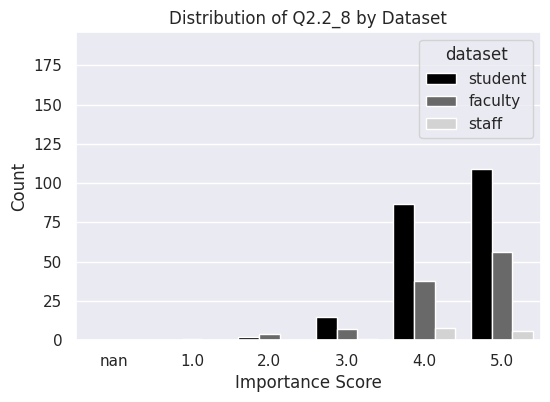

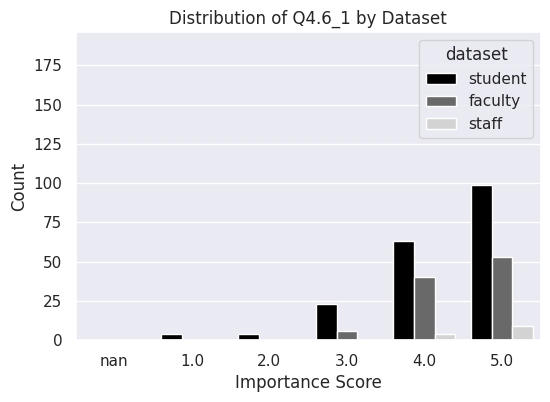

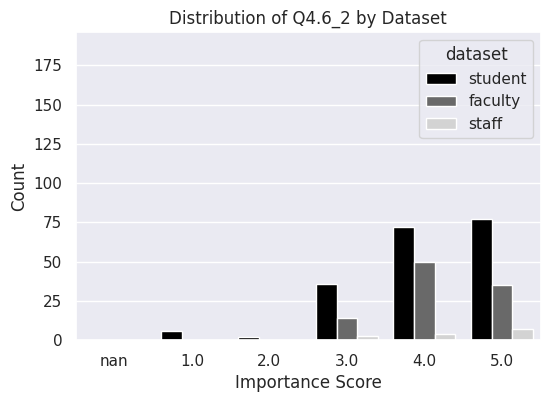

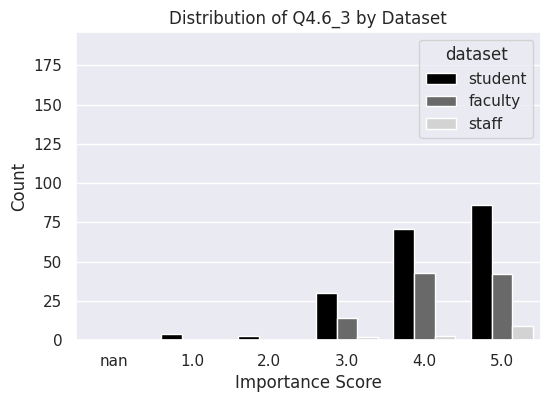

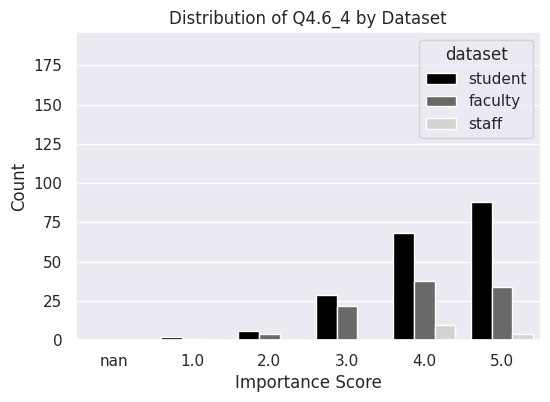

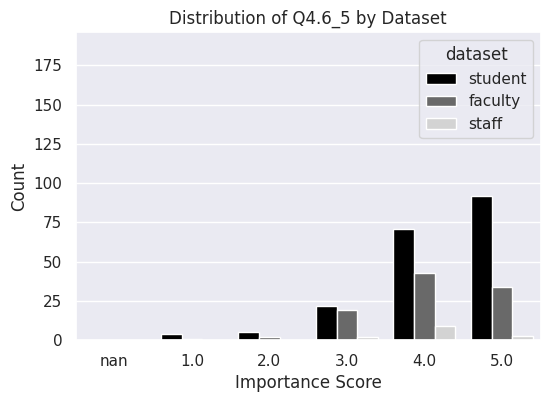

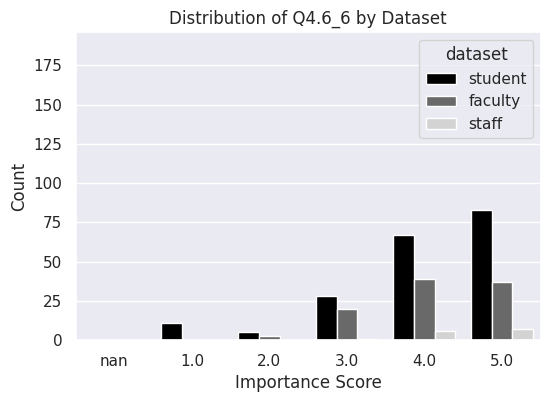

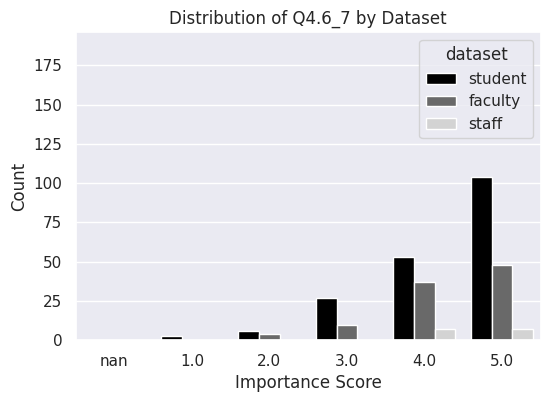

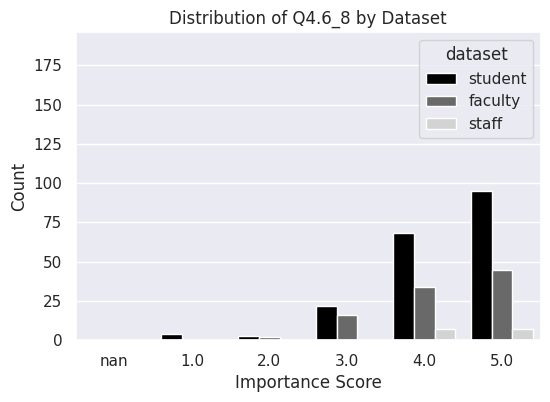

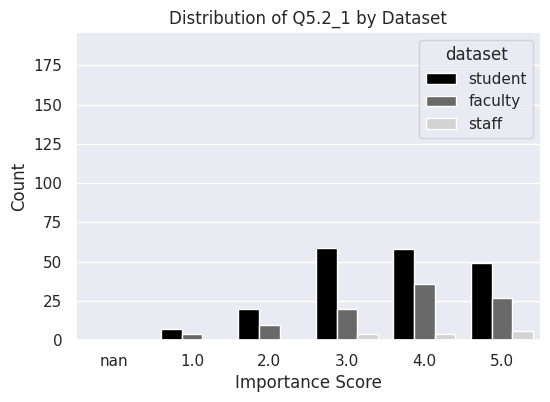

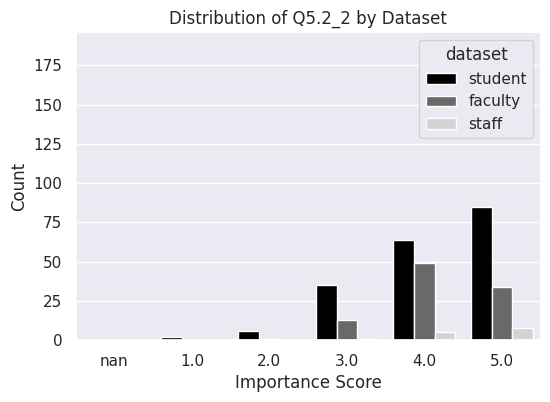

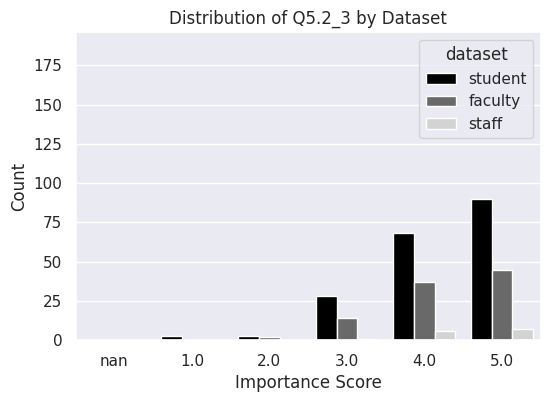

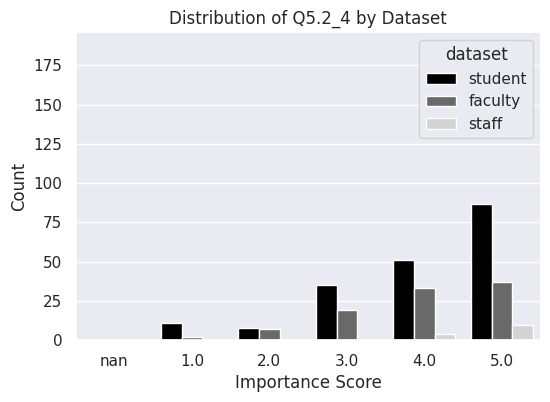

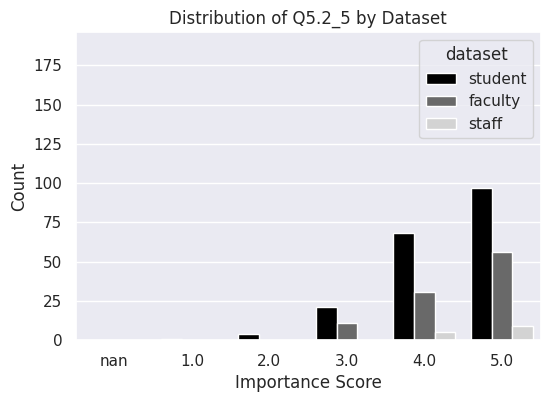

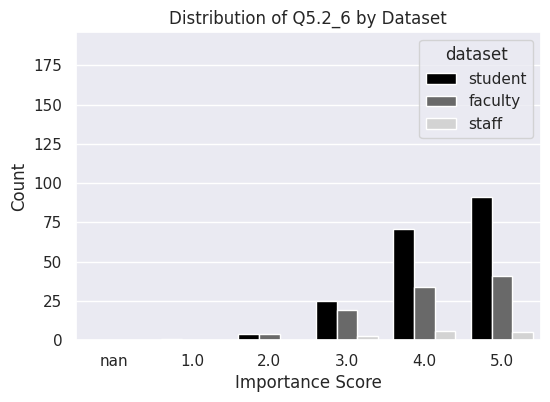

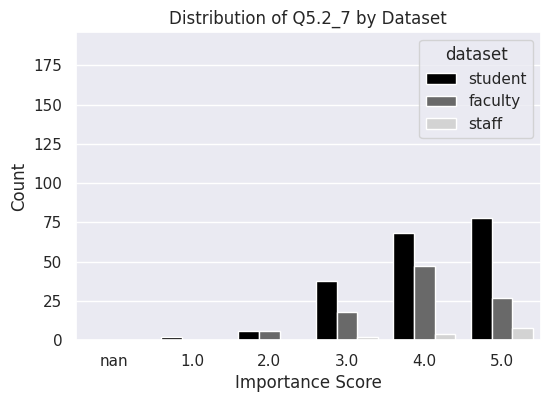

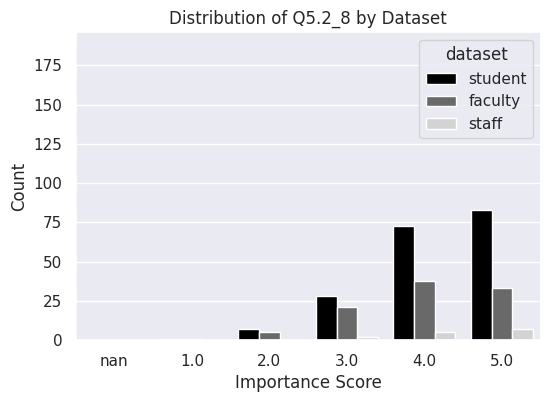

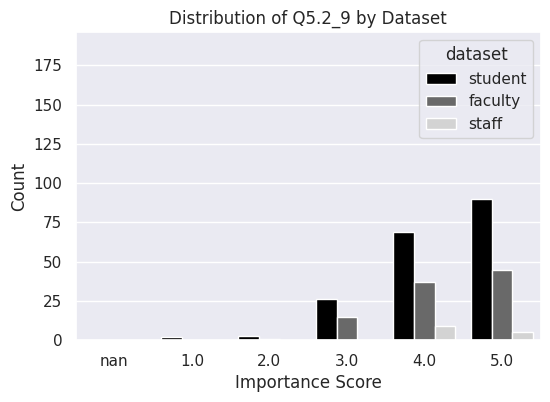

In [31]:
# Define a consistent order and palette for the datasets
dataset_order = ['student', 'faculty', 'staff']
palette = {'student': 'black', 'faculty': 'dimgray', 'staff': 'lightgray'}

# Determine the maximum count across all columns for a consistent y-axis
max_count = 0
cols = combined_df.columns.drop('dataset')
for col in cols:
    col_max = combined_df[col].value_counts().max()
    if col_max > max_count:
        max_count = col_max

# Plot each column
for col in cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=combined_df,
        x=col,
        hue='dataset',
        order=sorted(combined_df[col].unique()),  # ensures x-axis sorted
        hue_order=dataset_order,
        palette=palette
    )
    plt.title(f'Distribution of {col} by Dataset')
    plt.xlabel('Importance Score')
    plt.ylabel('Count')
    plt.ylim(0, max_count + 1)  # consistent y-axis across all plots
    plt.show()


In [32]:
desc_stats = {}

for col in cols_to_map:
    data = combined_df[col].dropna()  # exclude NaN
    # Use pandas mode as a safer alternative
    mode_val = data.mode()
    mode_val = mode_val.iloc[0] if not mode_val.empty else None

    desc_stats[col] = {
        'mean': data.mean(),
        'min_value': data.min(),
        'max_value': data.max(),
        '25th_percentile': data.quantile(0.25),
        'median': data.median(),
        '75th_percentile': data.quantile(0.75),
        'mode': mode_val,
        'variance': data.var(),
        'standard_deviation': data.std()
    }

# Convert to DataFrame
desc_stats_df = pd.DataFrame(desc_stats).T.round(2)

# Sort by median -> mode -> mean descending
desc_stats_sorted = desc_stats_df.sort_values(
    by=['median', 'mode', 'mean'],
    ascending=[False, False, False]
)

desc_stats_sorted


,mean,min_value,max_value,25th_percentile,median,75th_percentile,mode,variance,standard_deviation
Q2.2_1,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.72,0.85
Q2.2_2,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.58,0.76
Q2.2_8,4.40,1.0,5.0,4.0,5.0,5.0,5.0,0.52,0.72
Q5.2_5,4.39,1.0,5.0,4.0,5.0,5.0,5.0,0.57,0.76
Q4.6_1,4.37,1.0,5.0,4.0,5.0,5.0,5.0,0.66,0.81
Q2.2_3,4.30,1.0,5.0,4.0,5.0,5.0,5.0,0.78,0.88
Q4.6_7,4.30,1.0,5.0,4.0,5.0,5.0,5.0,0.77,0.88
Q2.2_7,4.30,1.0,5.0,4.0,4.0,5.0,5.0,0.67,0.82
Q4.6_8,4.29,1.0,5.0,4.0,4.0,5.0,5.0,0.72,0.85
Q5.2_9,4.28,1.0,5.0,4.0,4.0,5.0,5.0,0.63,0.80


In [33]:
# Get the top 10 questions by mean
top_10_cols = desc_stats_sorted.index[:10].tolist()
# Second row in student dataset contains full question text
# Note: pandas indexing starts at 0, so second row is index 1
second_row = student.iloc[0]
top_10_questions = second_row[top_10_cols]
pd.set_option('display.max_colwidth', None)
top_10_questions


,0
Q2.2_1,"How important are the following aspects for promoting Augustin College to future students? - Flexible learning Options (e.g., online, evening, hybrid)"
Q2.2_2,How important are the following aspects for promoting Augustin College to future students? - Career-focused programs aligned with workforce needs
Q2.2_8,How important are the following aspects for promoting Augustin College to future students? - Strong faculty with industry experience
Q5.2_5,How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement
Q4.6_1,How important are the following priorities for preparing students for life after Augustin College? - Opportunities for career networking
Q2.2_3,How important are the following aspects for promoting Augustin College to future students? - Competitive tuition and robust financial aid support
Q4.6_7,How important are the following priorities for preparing students for life after Augustin College? - Networking
Q2.2_7,How important are the following aspects for promoting Augustin College to future students? - Strong Veritus Imperial University reputation and alumni network
Q4.6_8,How important are the following priorities for preparing students for life after Augustin College? - Clearer alignment between academic programs and professional goals
Q5.2_9,How important should each of the following ideas be in shaping the future mission of Augustin College? - Aligning with the evolving challenges and opportunities of the future workforce


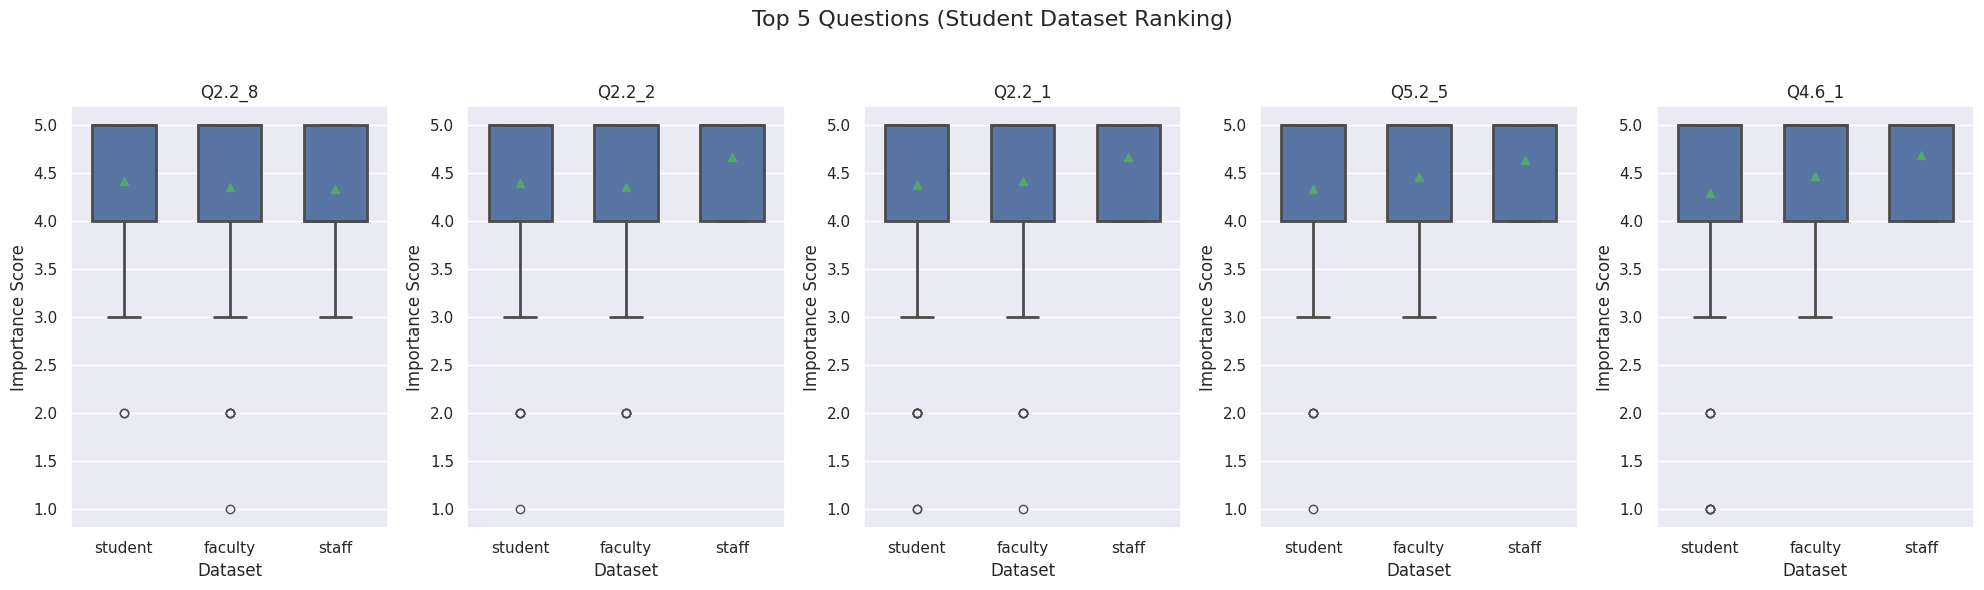

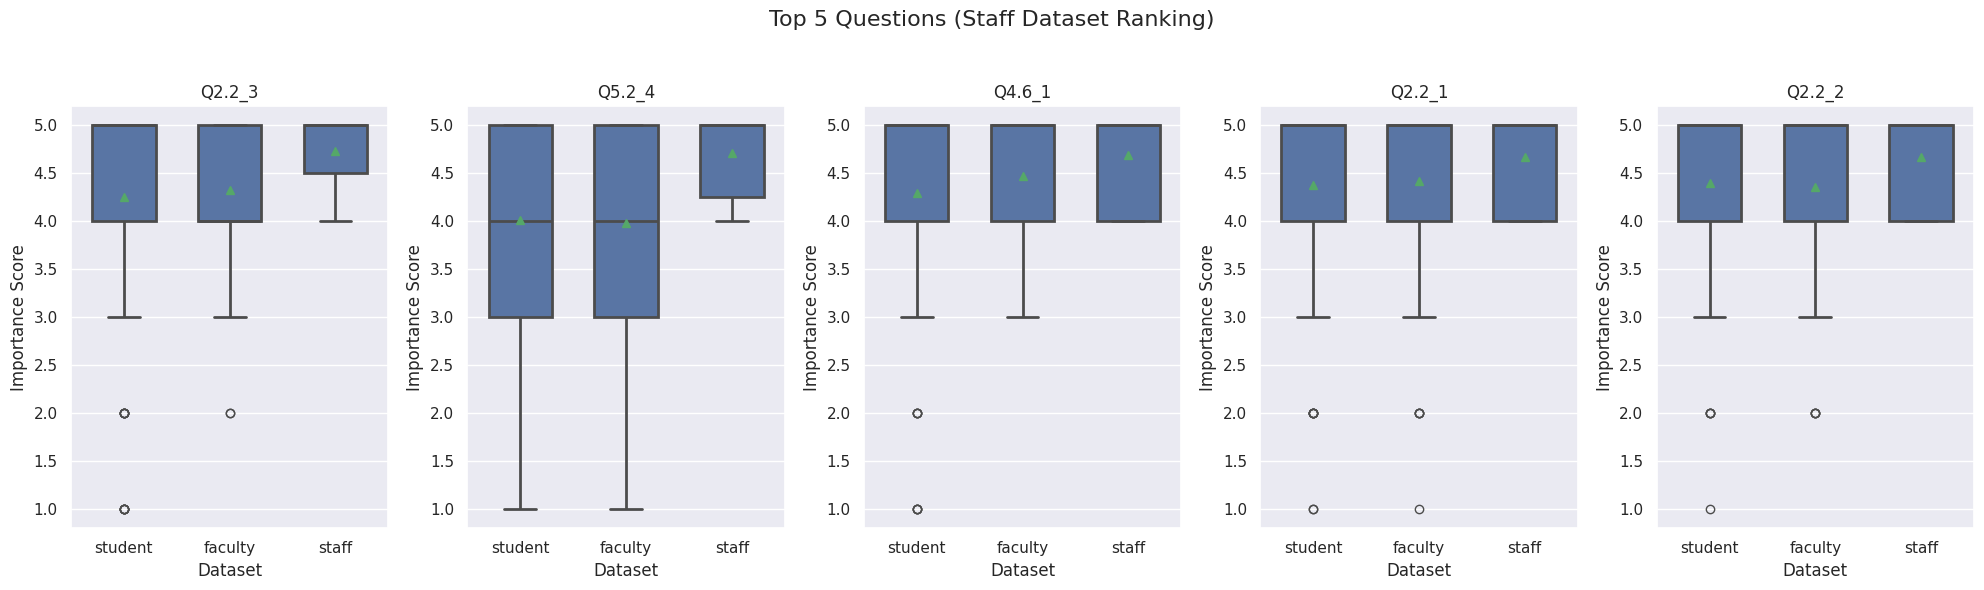

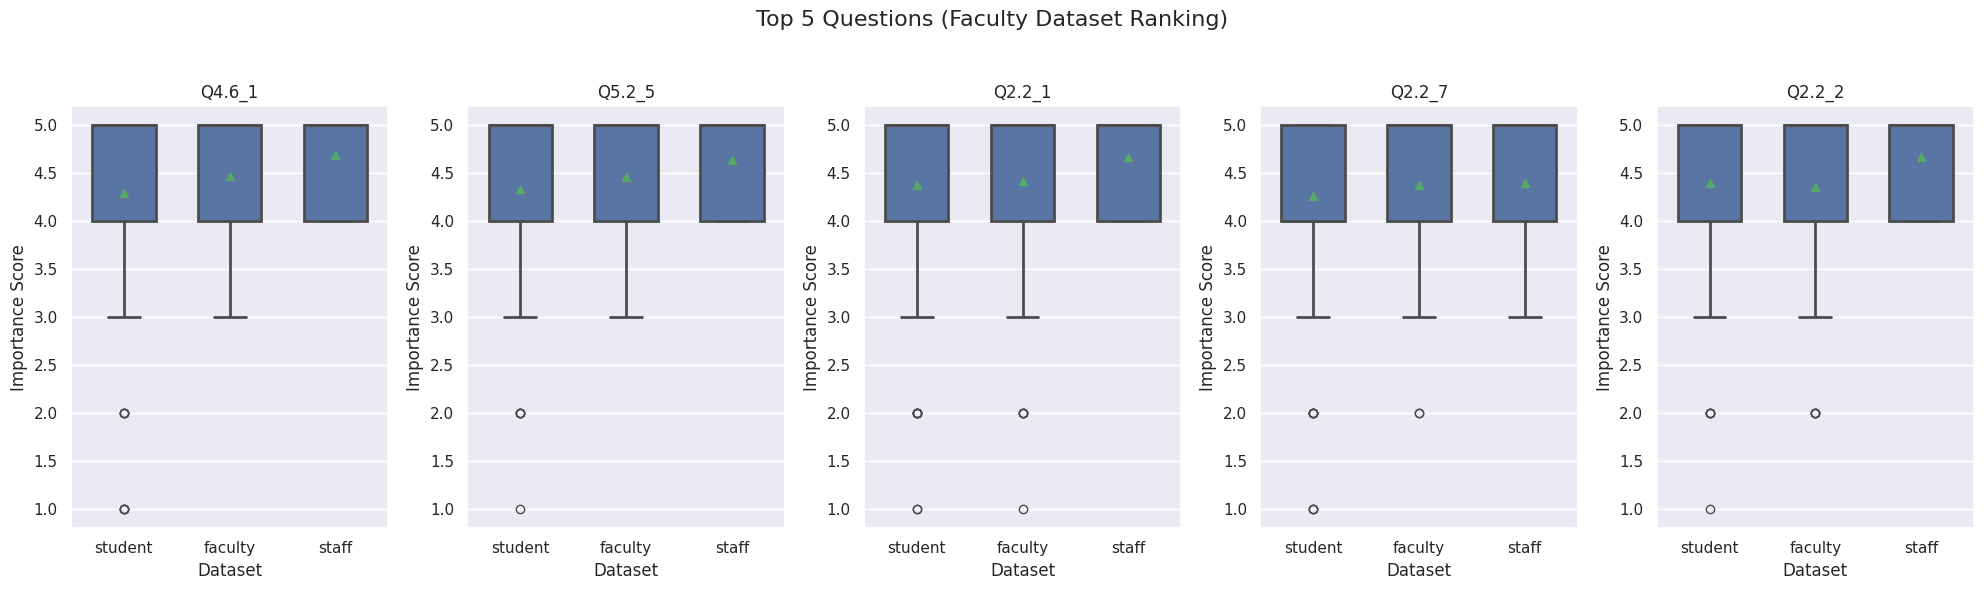

In [34]:
#Step 1: Function to compute descriptive stats
def compute_desc_stats(df, cols):
    desc_stats = {}
    for col in cols:
        data = df[col].dropna()
        mode_val = data.mode()
        mode_val = mode_val.iloc[0] if not mode_val.empty else None
        desc_stats[col] = {
            'mean': data.mean(),
            'median': data.median(),
            'mode': mode_val,
            'min_value': data.min(),
            'max_value': data.max(),
            '25th_percentile': data.quantile(0.25),
            '75th_percentile': data.quantile(0.75),
            'variance': data.var(),
            'standard_deviation': data.std()
        }
    return pd.DataFrame(desc_stats).T

# Step 2: Select question columns (exclude 'dataset')
cols_to_use = combined_df.columns.drop('dataset')

# Step 3: Compute descriptive stats for each dataset
stats_student = compute_desc_stats(combined_df[combined_df['dataset']=='student'], cols_to_use)
stats_staff = compute_desc_stats(combined_df[combined_df['dataset']=='staff'], cols_to_use)
stats_faculty = compute_desc_stats(combined_df[combined_df['dataset']=='faculty'], cols_to_use)

# Step 4: Select top 5 columns for each dataset based on mean → median → mode descending
top5_student = stats_student.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_staff   = stats_staff.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_faculty = stats_faculty.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()

# Step 5: Plot boxplots grouped by dataset
def plot_boxplot(top_cols, title):
    plt.figure(figsize=(20,6))
    for i, col in enumerate(top_cols, 1):
        plt.subplot(1,5,i)
        sns.boxplot(x='dataset', y=col, data=combined_df, width=0.6, linewidth=2, showmeans=True)
        plt.title(col)
        plt.ylabel('Importance Score')
        plt.xlabel('Dataset')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Student top 5
plot_boxplot(top5_student, 'Top 5 Questions (Student Dataset Ranking)')

# Staff top 5
plot_boxplot(top5_staff, 'Top 5 Questions (Staff Dataset Ranking)')

# Faculty top 5
plot_boxplot(top5_faculty, 'Top 5 Questions (Faculty Dataset Ranking)')


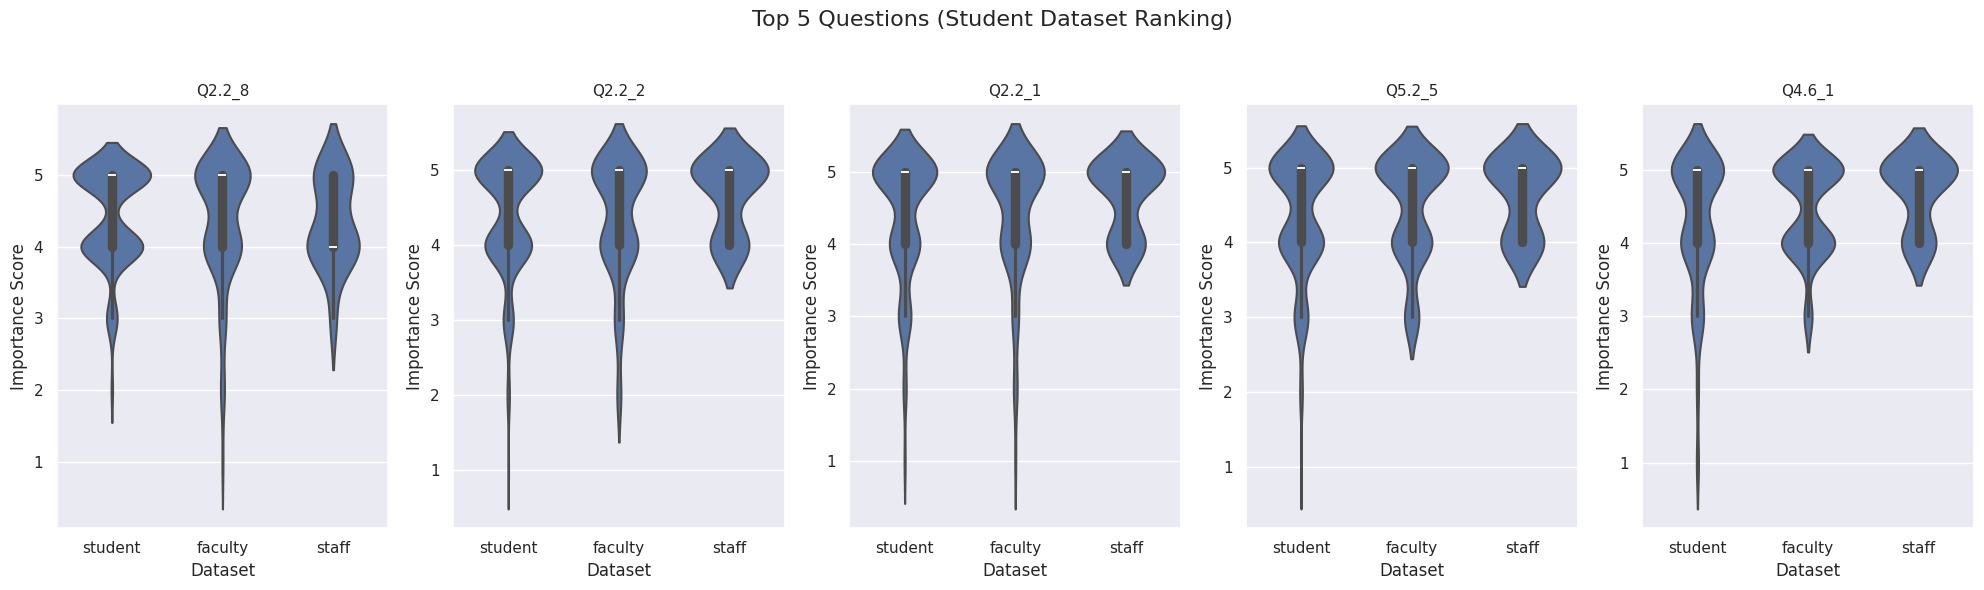

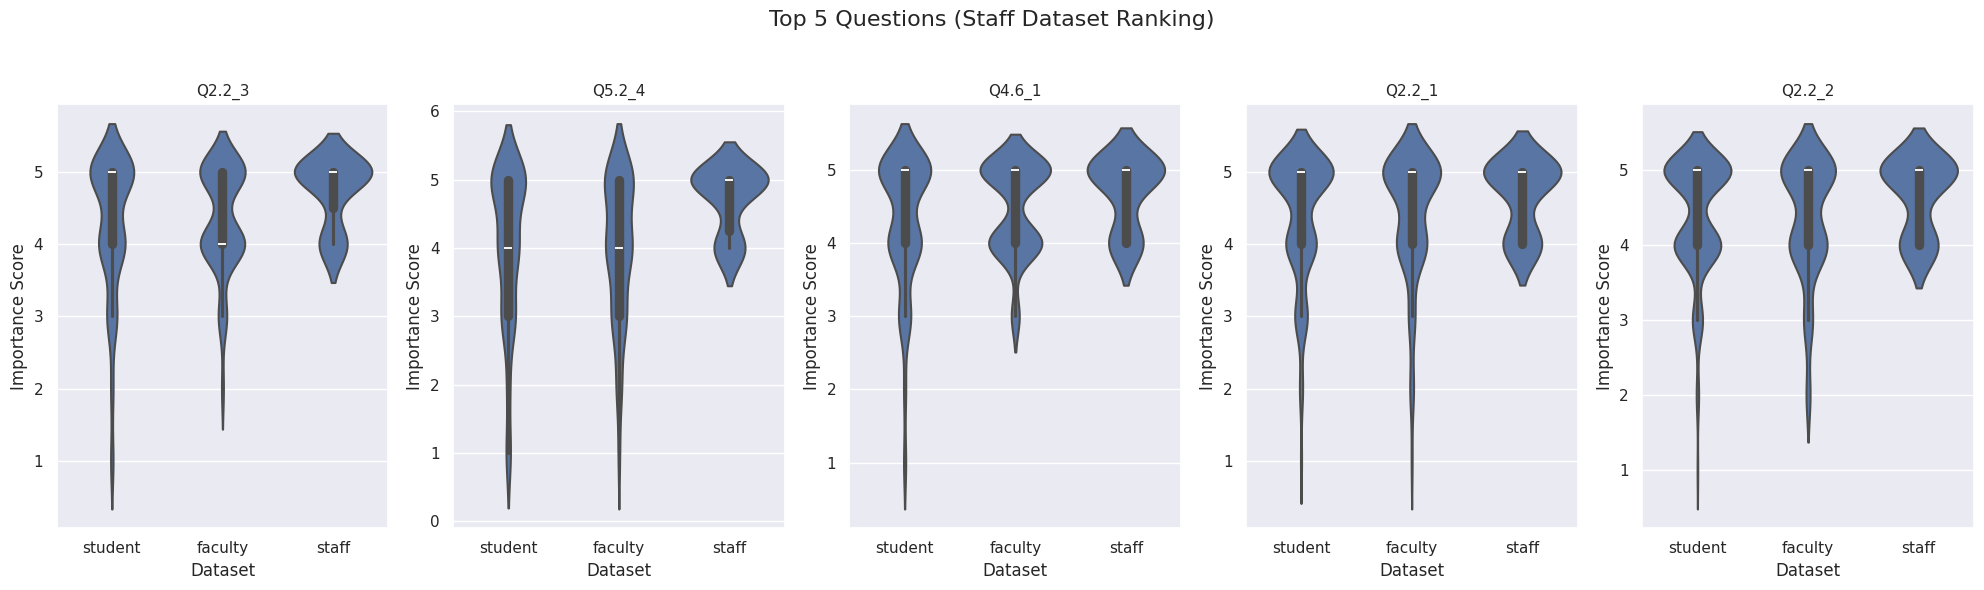

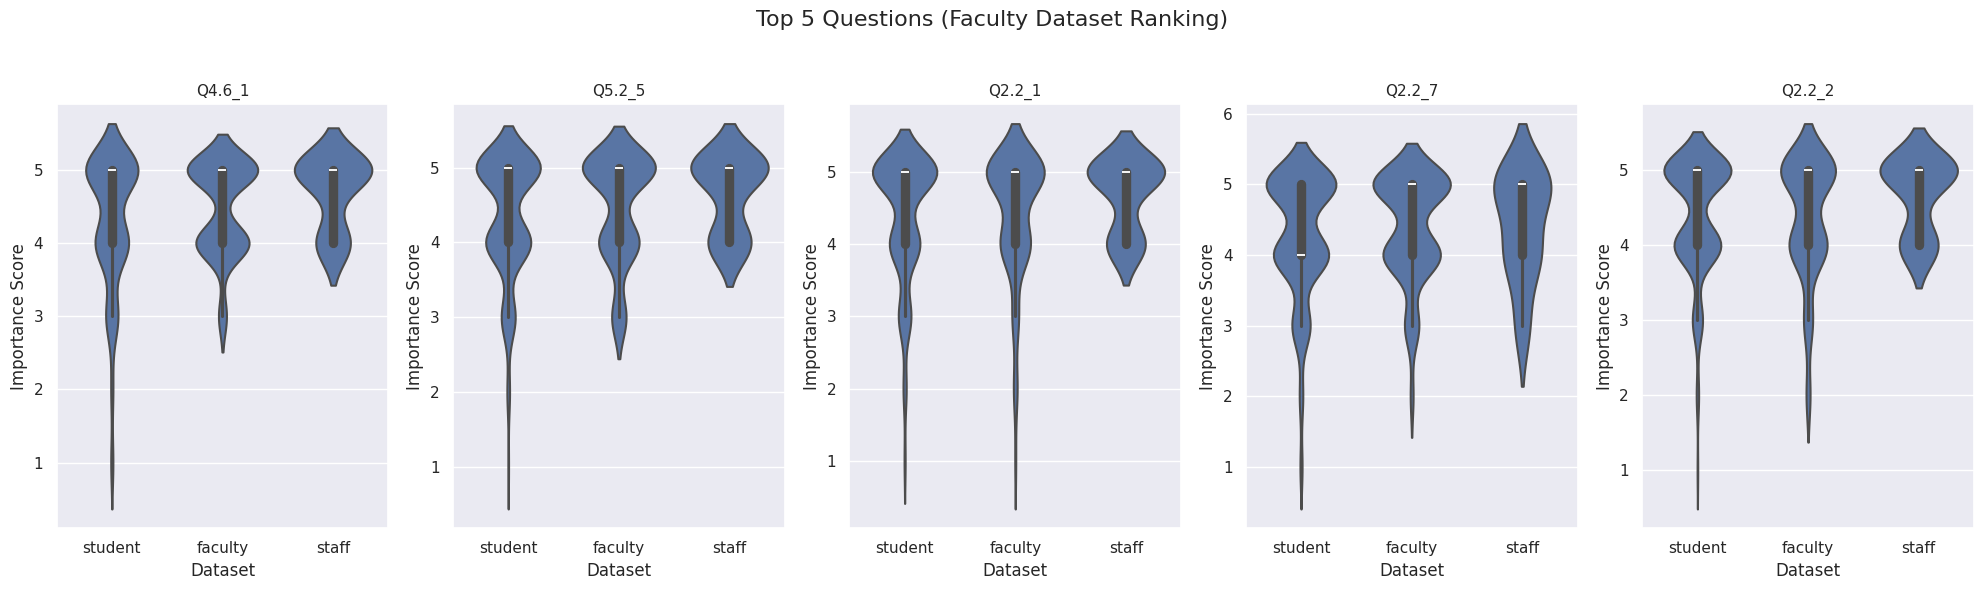

In [35]:
# Step 1: Function to compute descriptive stats
def compute_desc_stats(df, cols):
    desc_stats = {}
    for col in cols:
        data = df[col].dropna()
        mode_val = data.mode()
        mode_val = mode_val.iloc[0] if not mode_val.empty else None
        desc_stats[col] = {
            'mean': data.mean(),
            'median': data.median(),
            'mode': mode_val,
            'min_value': data.min(),
            'max_value': data.max(),
            '25th_percentile': data.quantile(0.25),
            '75th_percentile': data.quantile(0.75),
            'variance': data.var(),
            'standard_deviation': data.std()
        }
    return pd.DataFrame(desc_stats).T

# Step 2: Select question columns (exclude 'dataset')
cols_to_use = combined_df.columns.drop('dataset')

# Step 3: Compute descriptive stats for each dataset
stats_student = compute_desc_stats(combined_df[combined_df['dataset']=='student'], cols_to_use)
stats_staff = compute_desc_stats(combined_df[combined_df['dataset']=='staff'], cols_to_use)
stats_faculty = compute_desc_stats(combined_df[combined_df['dataset']=='faculty'], cols_to_use)

# Step 4: Select top 5 columns for each dataset based on mean → median → mode descending
top5_student = stats_student.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_staff   = stats_staff.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()
top5_faculty = stats_faculty.sort_values(by=['mean','median','mode'], ascending=[False,False,False]).index[:5].tolist()

# Step 5: Plot violinplots grouped by dataset
def plot_violinplot(top_cols, title):
    plt.figure(figsize=(20,6))
    for i, col in enumerate(top_cols, 1):
        plt.subplot(1,5,i)
        sns.violinplot(
            x='dataset',
            y=col,
            data=combined_df,
            inner='box',       # show median and IQR box inside violin
            linewidth=1.5,
            width=0.7
        )
        plt.title(col, fontsize=11)
        plt.ylabel('Importance Score')
        plt.xlabel('Dataset')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Student top 5
plot_violinplot(top5_student, 'Top 5 Questions (Student Dataset Ranking)')

# Staff top 5
plot_violinplot(top5_staff, 'Top 5 Questions (Staff Dataset Ranking)')

# Faculty top 5
plot_violinplot(top5_faculty, 'Top 5 Questions (Faculty Dataset Ranking)')


In [36]:
# Replace all non-alphanumeric characters (like ., ?, space) with underscores
combined_df.columns = combined_df.columns.str.replace(r'[^0-9a-zA-Z_]', '_', regex=True)


=== Checking ANOVA assumptions for: Q2_2_1 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.4437 → ✅ OK
Independence: Assumed based on study design ✅


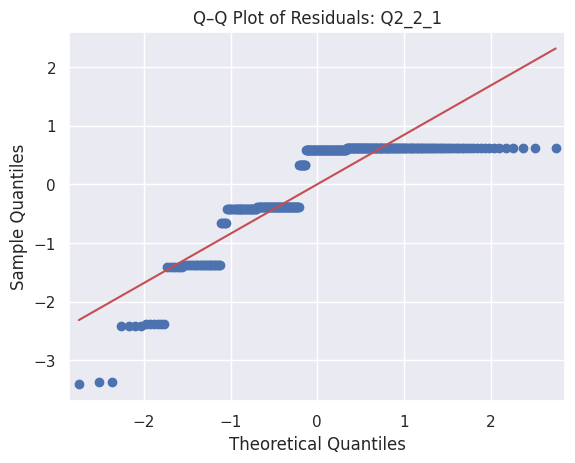


=== Checking ANOVA assumptions for: Q2_2_2 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.3403 → ✅ OK
Independence: Assumed based on study design ✅


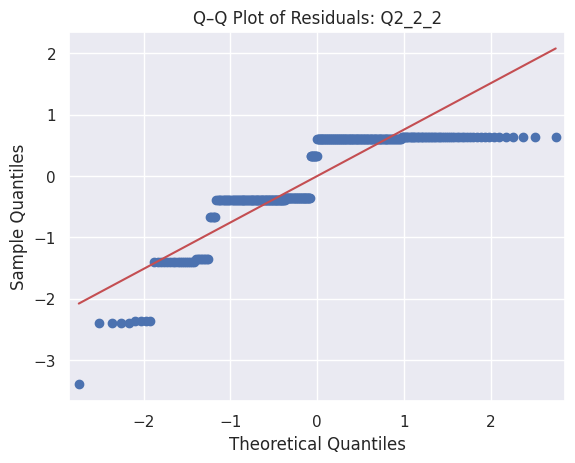


=== Checking ANOVA assumptions for: Q2_2_3 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0406 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


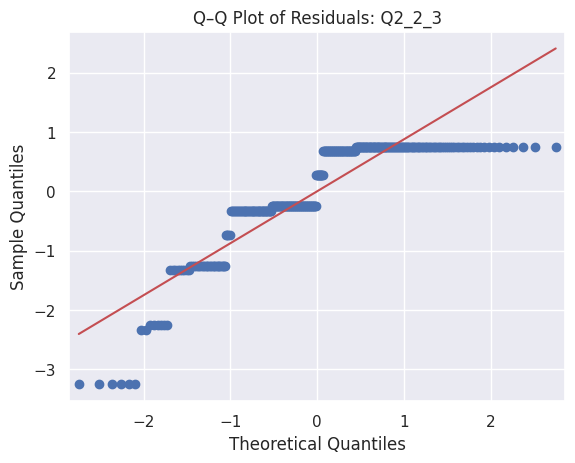


=== Checking ANOVA assumptions for: Q2_2_4 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.2567 → ✅ OK
Independence: Assumed based on study design ✅


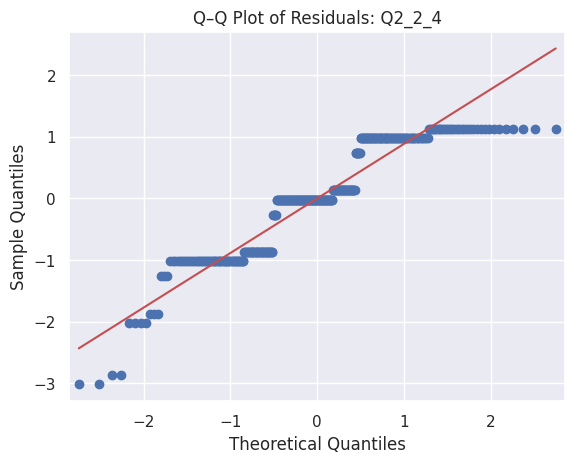


=== Checking ANOVA assumptions for: Q2_2_5 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0461 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


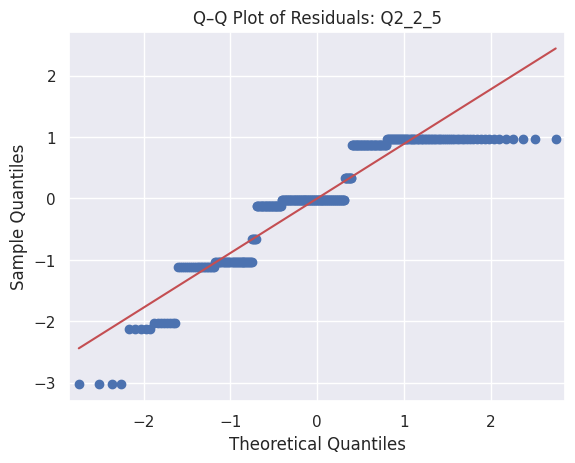


=== Checking ANOVA assumptions for: Q2_2_6 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0703 → ✅ OK
Independence: Assumed based on study design ✅


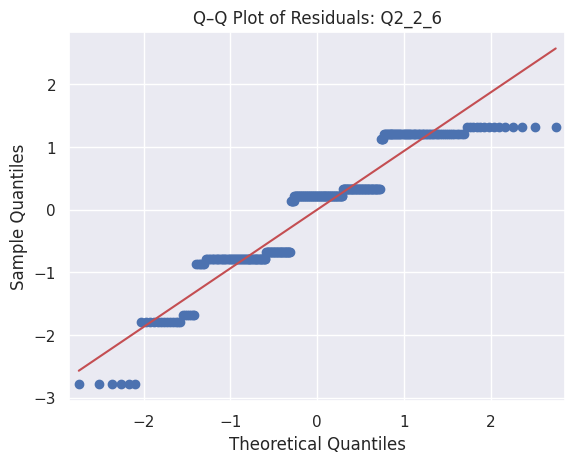


=== Checking ANOVA assumptions for: Q2_2_7 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.7053 → ✅ OK
Independence: Assumed based on study design ✅


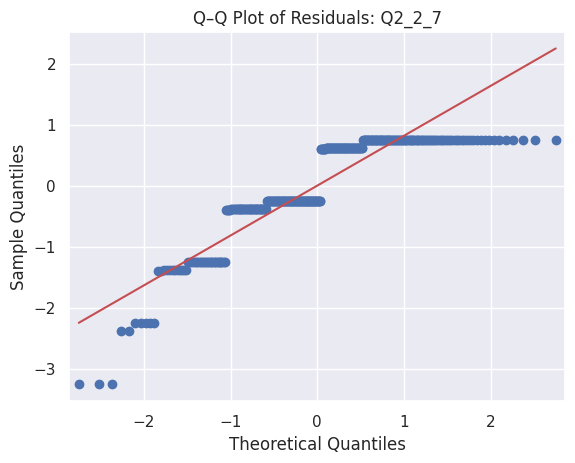


=== Checking ANOVA assumptions for: Q2_2_8 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.5953 → ✅ OK
Independence: Assumed based on study design ✅


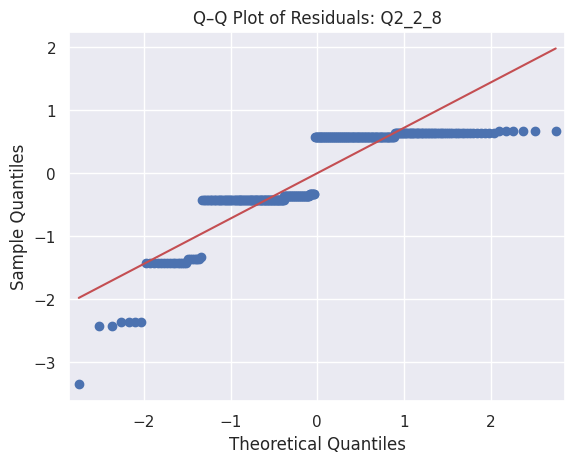


=== Checking ANOVA assumptions for: Q4_6_1 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0620 → ✅ OK
Independence: Assumed based on study design ✅


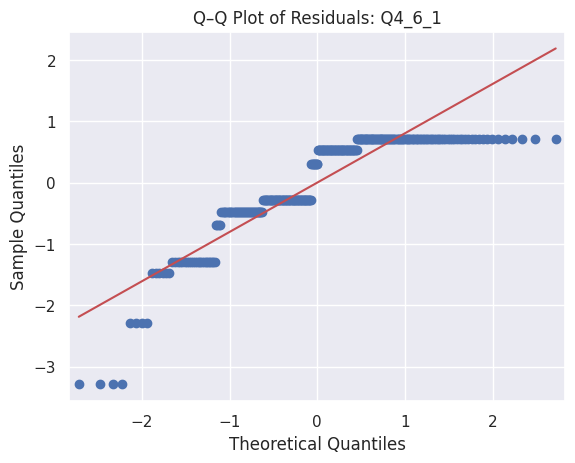


=== Checking ANOVA assumptions for: Q4_6_2 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0196 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


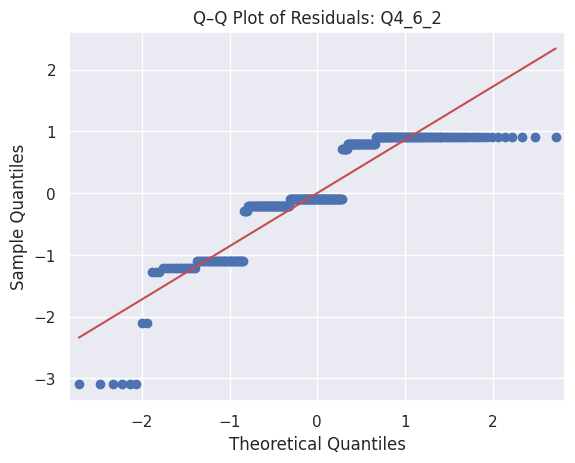


=== Checking ANOVA assumptions for: Q4_6_3 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.1451 → ✅ OK
Independence: Assumed based on study design ✅


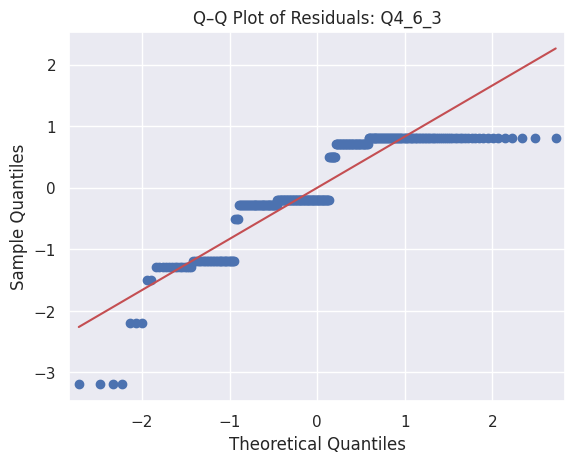


=== Checking ANOVA assumptions for: Q4_6_4 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0387 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


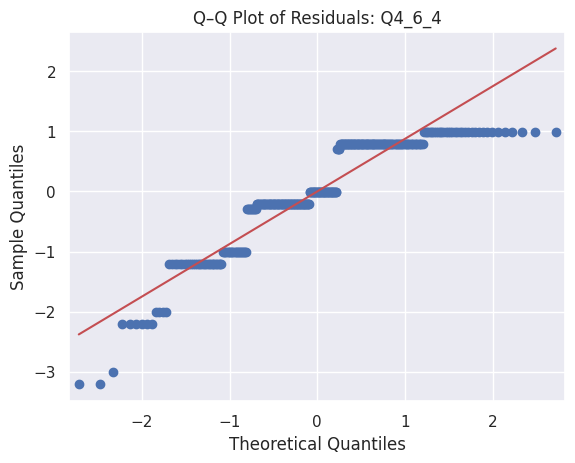


=== Checking ANOVA assumptions for: Q4_6_5 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0777 → ✅ OK
Independence: Assumed based on study design ✅


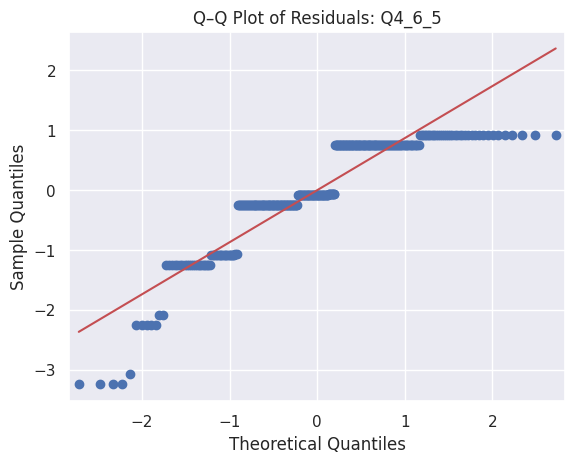


=== Checking ANOVA assumptions for: Q4_6_6 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.1106 → ✅ OK
Independence: Assumed based on study design ✅


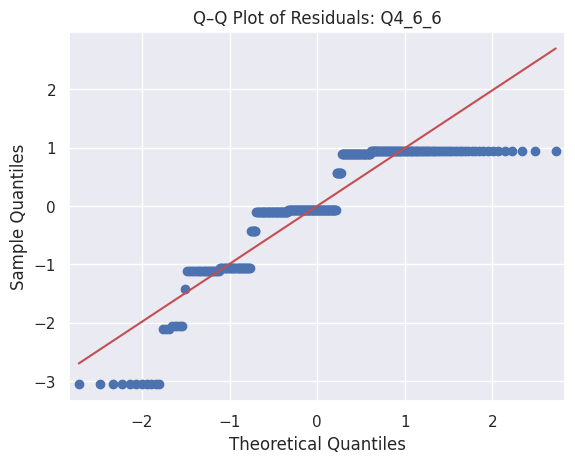


=== Checking ANOVA assumptions for: Q4_6_7 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.6141 → ✅ OK
Independence: Assumed based on study design ✅


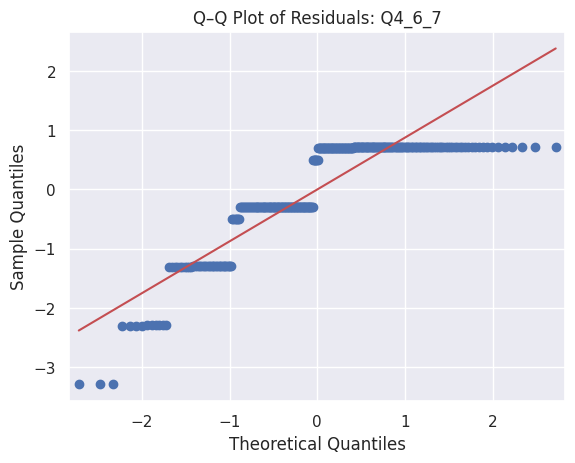


=== Checking ANOVA assumptions for: Q4_6_8 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.4143 → ✅ OK
Independence: Assumed based on study design ✅


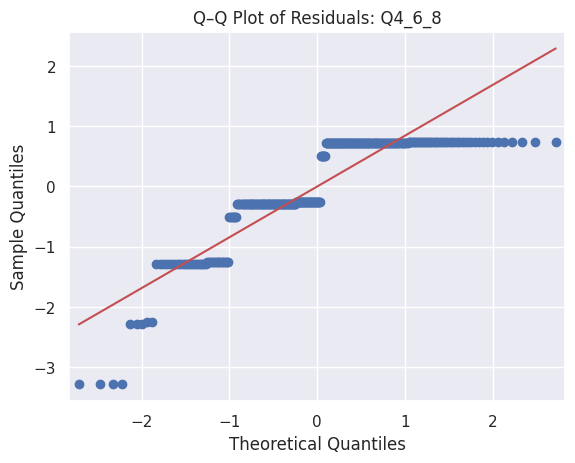


=== Checking ANOVA assumptions for: Q5_2_1 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.6294 → ✅ OK
Independence: Assumed based on study design ✅


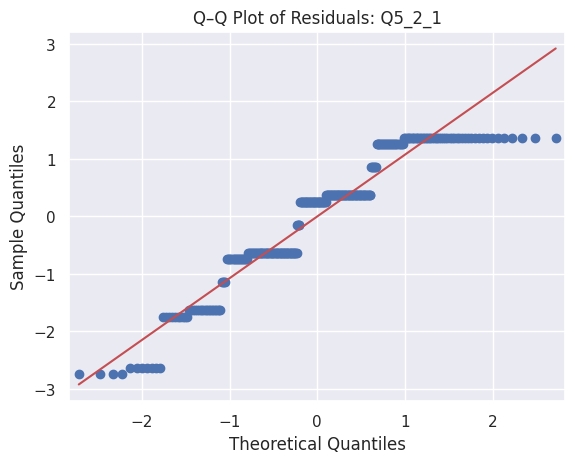


=== Checking ANOVA assumptions for: Q5_2_2 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0065 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


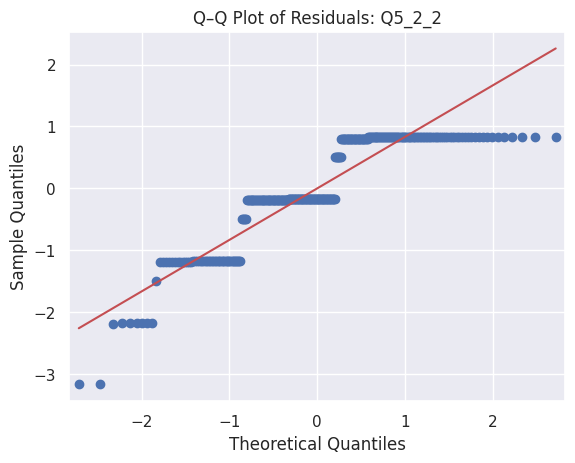


=== Checking ANOVA assumptions for: Q5_2_3 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.6068 → ✅ OK
Independence: Assumed based on study design ✅


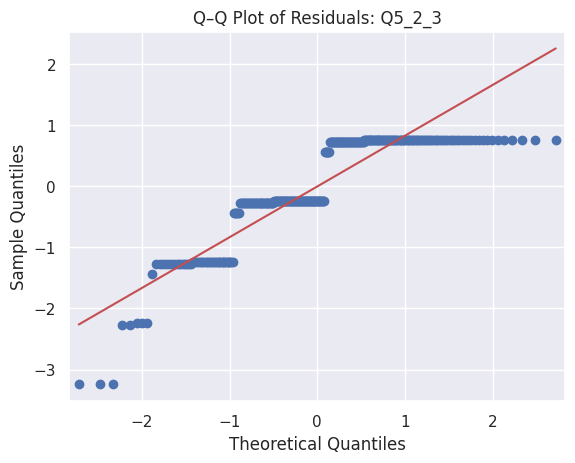


=== Checking ANOVA assumptions for: Q5_2_4 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.0056 → ⚠️ Unequal variances
Independence: Assumed based on study design ✅


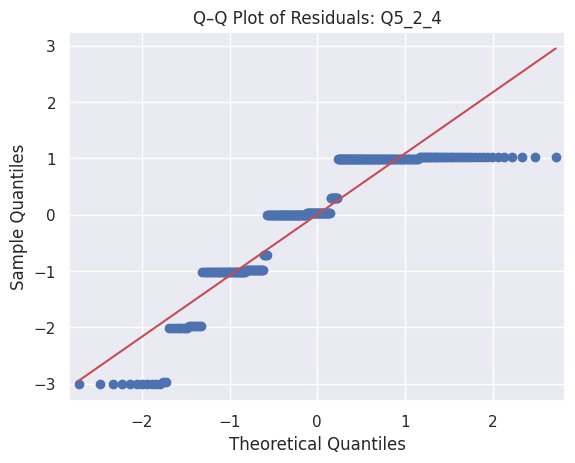


=== Checking ANOVA assumptions for: Q5_2_5 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.2009 → ✅ OK
Independence: Assumed based on study design ✅


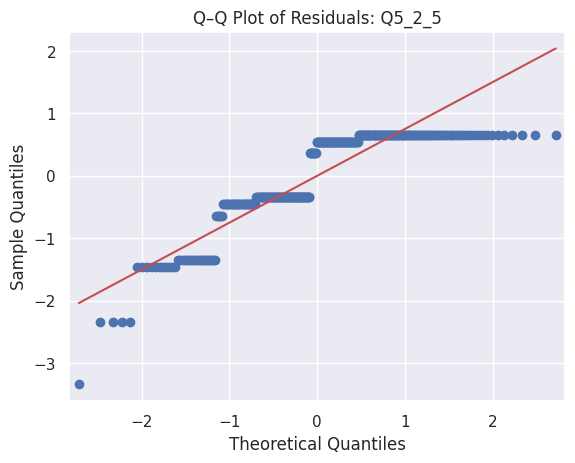


=== Checking ANOVA assumptions for: Q5_2_6 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.7087 → ✅ OK
Independence: Assumed based on study design ✅


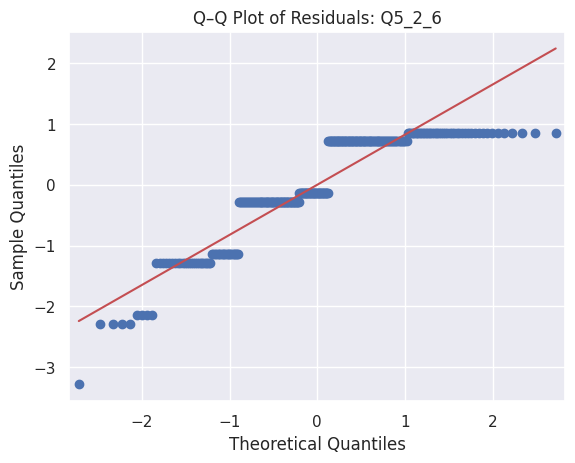


=== Checking ANOVA assumptions for: Q5_2_7 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.2564 → ✅ OK
Independence: Assumed based on study design ✅


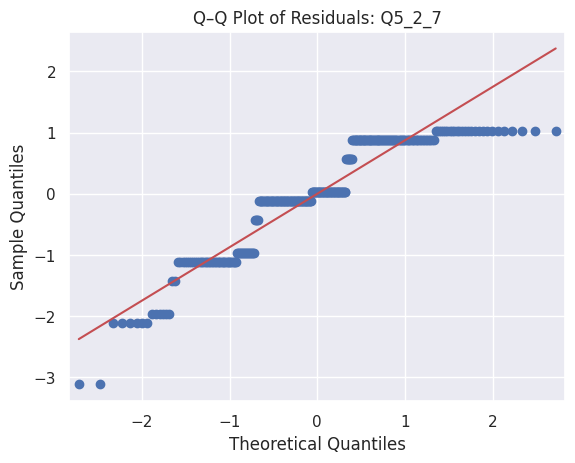


=== Checking ANOVA assumptions for: Q5_2_8 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.9559 → ✅ OK
Independence: Assumed based on study design ✅


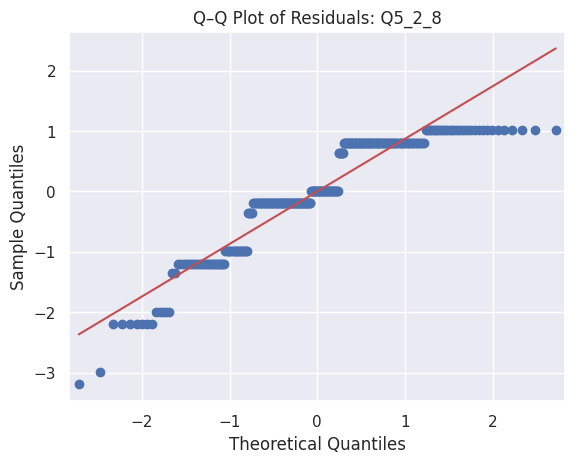


=== Checking ANOVA assumptions for: Q5_2_9 ===
Shapiro–Wilk test (residuals normal?): p = 0.0000 → ⚠️ Not normal
Levene’s test (equal variances?): p = 0.1053 → ✅ OK
Independence: Assumed based on study design ✅


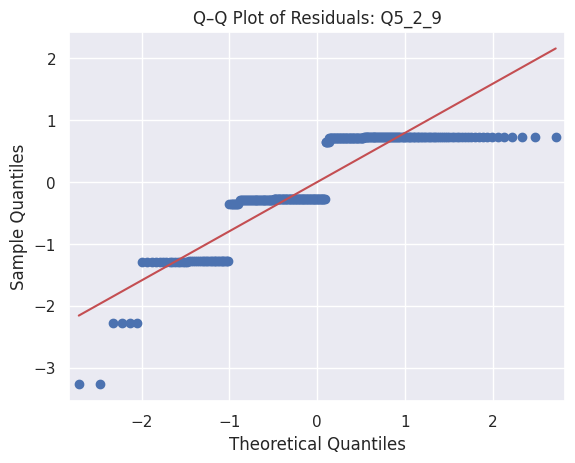

In [37]:
## Check ANOVA assumptions
# Define your grouping variable
group_col = 'dataset'

# Loop through each question column
for col in combined_df.columns[:-1]:
    print(f"\n=== Checking ANOVA assumptions for: {col} ===")

    # Drop NaN values
    data = combined_df[[col, group_col]].dropna()

    # Separate by group
    groups = [group[col].values for name, group in data.groupby(group_col)]

    # --- 1. Normality of residuals (Shapiro–Wilk) ---
    model = ols(f"{col} ~ C({group_col})", data=data).fit()
    w_stat, p_shapiro = stats.shapiro(model.resid)
    print(f"Shapiro–Wilk test (residuals normal?): p = {p_shapiro:.4f} → {'✅ OK' if p_shapiro > 0.05 else '⚠️ Not normal'}")

    # --- 2. Homogeneity of variances (Levene’s test) ---
    w_levene, p_levene = stats.levene(*groups)
    print(f"Levene’s test (equal variances?): p = {p_levene:.4f} → {'✅ OK' if p_levene > 0.05 else '⚠️ Unequal variances'}")

    # --- 3. Independence of observations ---
    print("Independence: Assumed based on study design ✅")

    # --- 4. Q–Q Plot for residuals (visual normality check) ---
    sm.qqplot(model.resid, line='s')
    plt.title(f"Q–Q Plot of Residuals: {col}")
    plt.show()


In [38]:
## ANOVA test
import scipy.stats as stats

for col in combined_df.columns[:-1]:
    groups = [g[col].dropna().values for name, g in combined_df.groupby('dataset')]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.3f}, p={p_val:.4f}")


Q2_2_1: F=0.815, p=0.4437
Q2_2_2: F=1.081, p=0.3403
Q2_2_3: F=2.147, p=0.1184
Q2_2_4: F=1.823, p=0.1632
Q2_2_5: F=3.720, p=0.0253
Q2_2_6: F=0.622, p=0.5375
Q2_2_7: F=0.856, p=0.4260
Q2_2_8: F=0.340, p=0.7123
Q4_6_1: F=2.806, p=0.0620
Q4_6_2: F=0.763, p=0.4671
Q4_6_3: F=1.078, p=0.3416
Q4_6_4: F=1.907, p=0.1502
Q4_6_5: F=1.315, p=0.2699
Q4_6_6: F=0.903, p=0.4065
Q4_6_7: F=0.372, p=0.6897
Q4_6_8: F=0.500, p=0.6068
Q5_2_1: F=1.621, p=0.1994
Q5_2_2: F=1.040, p=0.3546
Q5_2_3: F=0.331, p=0.7185
Q5_2_4: F=2.874, p=0.0580
Q5_2_5: F=1.614, p=0.2009
Q5_2_6: F=1.061, p=0.3475
Q5_2_7: F=2.031, p=0.1330
Q5_2_8: F=2.293, p=0.1028
Q5_2_9: F=0.073, p=0.9295


In [39]:
## Bootstrapped ANOVA
#This resamples your data many times to estimate the F-statistic distribution, so you don’t rely on normality.

def bootstrap_anova(df, col, group_col='dataset', n_bootstrap=10000, random_state=42):
    np.random.seed(random_state)

    # Extract groups
    groups = [g[col].dropna().values for _, g in df.groupby(group_col)]

    # Original F-statistic
    F_orig, _ = f_oneway(*groups)

    # Bootstrap F-statistics
    F_boot = []
    combined = np.concatenate(groups)
    sizes = [len(g) for g in groups]

    for _ in range(n_bootstrap):
        resampled_groups = [np.random.choice(combined, size=size, replace=True)
                            for size in sizes]
        F_b, _ = f_oneway(*resampled_groups)
        F_boot.append(F_b)

    # Compute bootstrap p-value
    p_boot = np.mean(np.array(F_boot) >= F_orig)

    return F_orig, p_boot

# Example usage for one column
F_val, p_val = bootstrap_anova(combined_df, 'Q2_2_1')
print(f"Bootstrapped ANOVA → F={F_val:.3f}, p={p_val:.4f}")


Bootstrapped ANOVA → F=0.815, p=0.4401


Bootstrapped ANOVA is a reasonable approach for your data, and it’s more appropriate than classical ANOVA for ordinal or non-normal data. Here’s why:

Why it works better than classical ANOVA:

Standard ANOVA assumes normally distributed residuals and continuous outcomes.

Bootstrapping resamples your observed data many times to empirically estimate the F-statistic distribution.

It does not rely on the normality assumption, so it can handle ordinal or skewed data.

What it tells you:

The F-statistic is calculated from your original data.

The bootstrapped p-value is the proportion of resampled F-statistics greater than or equal to the observed F.

This gives a more robust estimate of significance under violated assumptions.

Limitations:

Bootstrapping still assumes that your data are independent within and across groups.

For very small sample sizes, the estimates may be less stable.

It interprets your ordinal Likert scale as numeric (1–6), so it still assumes “equal spacing” between categories — which is a common but imperfect approximation.

✅ Conclusion: For ordinal Likert data with three groups, bootstrapped ANOVA is a valid, robust approach. If you wanted a strictly ordinal model, Kruskal–Wallis or ordinal regression would be alternatives.

In [40]:
# Bootstrapped ANOVA function (as you already have)
def bootstrap_anova(df, col, group_col='dataset', n_bootstrap=10000, random_state=42):
    np.random.seed(random_state)

    # Extract groups
    groups = [g[col].dropna().values for _, g in df.groupby(group_col)]

    # Original F-statistic
    F_orig, _ = f_oneway(*groups)

    # Bootstrap F-statistics
    F_boot = []
    combined = np.concatenate(groups)
    sizes = [len(g) for g in groups]

    for _ in range(n_bootstrap):
        resampled_groups = [np.random.choice(combined, size=size, replace=True)
                            for size in sizes]
        F_b, _ = f_oneway(*resampled_groups)
        F_boot.append(F_b)

    # Compute bootstrap p-value
    p_boot = np.mean(np.array(F_boot) >= F_orig)

    return F_orig, p_boot

# Loop through all columns except 'dataset'
cols_to_test = combined_df.columns.drop('dataset')
anova_results = []

for col in cols_to_test:
    F_val, p_val = bootstrap_anova(combined_df, col)
    anova_results.append({'Column': col, 'F_stat': F_val, 'p_value': p_val})

# Convert to DataFrame
anova_df = pd.DataFrame(anova_results)

# Display results sorted by F-statistic descending
anova_df.sort_values(by='F_stat', ascending=False, inplace=True)
print(anova_df)


    Column    F_stat  p_value
4   Q2_2_5  3.720165   0.0249
19  Q5_2_4  2.874182   0.0604
8   Q4_6_1  2.806057   0.0621
23  Q5_2_8  2.292646   0.0963
2   Q2_2_3  2.147195   0.1162
22  Q5_2_7  2.030882   0.1377
11  Q4_6_4  1.907374   0.1498
3   Q2_2_4  1.822580   0.1639
16  Q5_2_1  1.621095   0.2000
20  Q5_2_5  1.613641   0.2046
12  Q4_6_5  1.315330   0.2724
1   Q2_2_2  1.081358   0.3462
10  Q4_6_3  1.077773   0.3440
21  Q5_2_6  1.060752   0.3498
17  Q5_2_2  1.040373   0.3603
13  Q4_6_6  0.902814   0.4118
6   Q2_2_7  0.855502   0.4353
0   Q2_2_1  0.814550   0.4401
9   Q4_6_2  0.763125   0.4663
5   Q2_2_6  0.621967   0.5363
15  Q4_6_8  0.500444   0.6109
14  Q4_6_7  0.371961   0.6925
7   Q2_2_8  0.339609   0.7136
18  Q5_2_3  0.330896   0.7154
24  Q5_2_9  0.073154   0.9285


In [41]:
## Regroup into 3 groups

# --- Define regrouping function ---
def regroup_importance(x):
    if pd.isna(x):
        return np.nan
    elif x == 1:
        return 1  # Not important
    elif x in [2, 3]:
        return 2  # Moderately important
    elif x in [4, 5]:
        return 3  # Highly important
    else:
        return np.nan

# --- Make a copy of the original dataset ---
regroup_df = combined_df.copy()

# --- Identify all Likert columns (exclude 'dataset' or any non-numeric column) ---
likert_cols = [col for col in regroup_df.columns if col != 'dataset' and pd.api.types.is_numeric_dtype(regroup_df[col])]

# --- Apply regrouping function to each Likert column ---
for col in likert_cols:
    regroup_df[col] = regroup_df[col].apply(regroup_importance)

# --- Optional: Map new numeric codes to labels for easier reading ---
label_map = {
    1: "Not important",
    2: "Moderately important",
    3: "Highly important"
}

# If you want a version with text labels:
regroup_labeled_df = regroup_df.copy()
for col in likert_cols:
    regroup_labeled_df[col] = regroup_labeled_df[col].map(label_map)

# --- Display a preview ---
print("Numeric regrouped data:")
print(regroup_df.head())

print("\nLabeled regrouped data:")
print(regroup_labeled_df.head())


Numeric regrouped data:
   Q2_2_1  Q2_2_2  Q2_2_3  Q2_2_4  Q2_2_5  Q2_2_6  Q2_2_7  Q2_2_8  Q4_6_1  \
0     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
1     2.0     3.0     3.0     3.0     2.0     2.0     3.0     3.0     2.0   
2     3.0     3.0     3.0     3.0     3.0     3.0     3.0     3.0     3.0   
3     3.0     3.0     3.0     2.0     3.0     3.0     3.0     3.0     3.0   
4     3.0     3.0     3.0     3.0     3.0     3.0     3.0     3.0     3.0   

   Q4_6_2  ...  Q5_2_1  Q5_2_2  Q5_2_3  Q5_2_4  Q5_2_5  Q5_2_6  Q5_2_7  \
0     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
1     2.0  ...     2.0     2.0     2.0     3.0     3.0     3.0     3.0   
2     3.0  ...     3.0     3.0     3.0     3.0     3.0     3.0     3.0   
3     3.0  ...     2.0     3.0     3.0     3.0     3.0     3.0     3.0   
4     3.0  ...     2.0     2.0     2.0     2.0     2.0     2.0     2.0   

   Q5_2_8  Q5_2_9  dataset  
0     NaN     NaN  student  
1     3.0 

=== Percentage distribution (all datasets combined) ===
        Highly important  Moderately important  Not important
Q2_2_1              86.8                  12.3            0.9
Q2_2_2              89.5                  10.2            0.3
Q2_2_3              85.5                  12.7            1.8
Q2_2_4              69.7                  29.1            1.2
Q2_2_5              77.5                  21.3            1.2
Q2_2_6              62.1                  36.1            1.8
Q2_2_7              85.6                  13.5            0.9
Q2_2_8              91.0                   8.7            0.3
Q4_6_1              87.9                  10.8            1.3
Q4_6_2              80.1                  18.0            2.0
Q4_6_3              82.7                  16.0            1.3
Q4_6_4              79.1                  19.9            1.0
Q4_6_5              82.1                  16.3            1.6
Q4_6_6              77.9                  18.6            3.6
Q4_6_7        

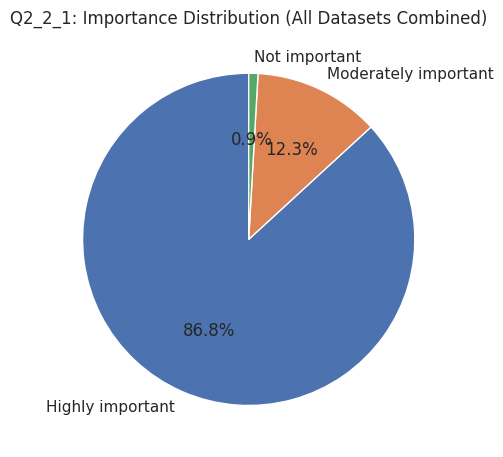

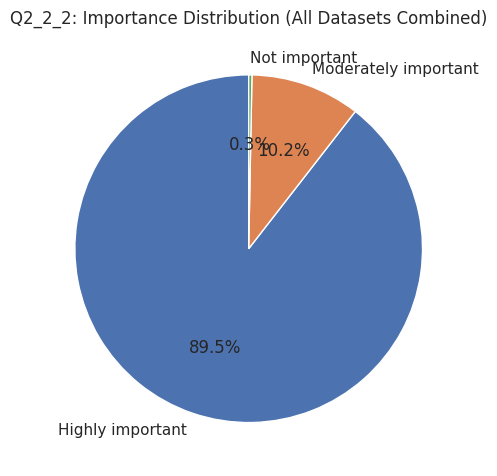

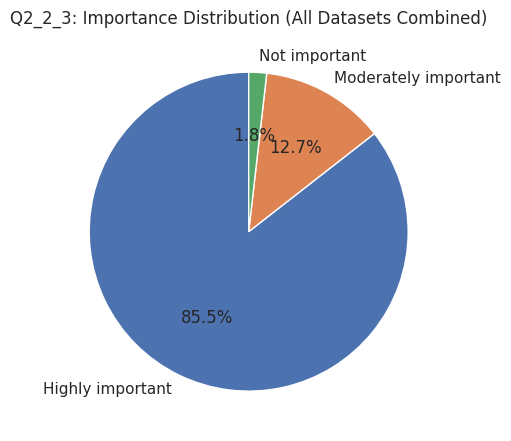

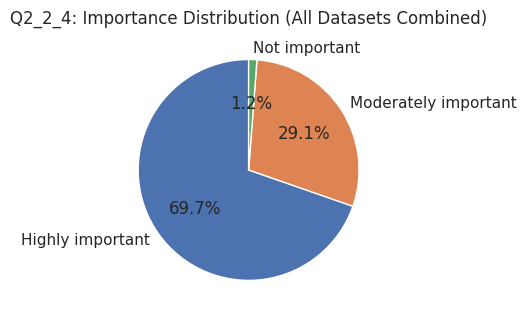

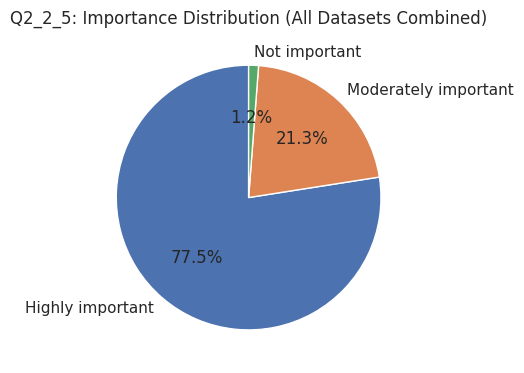

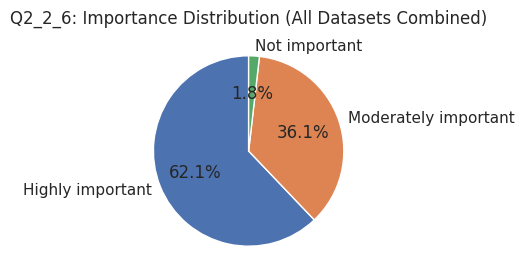

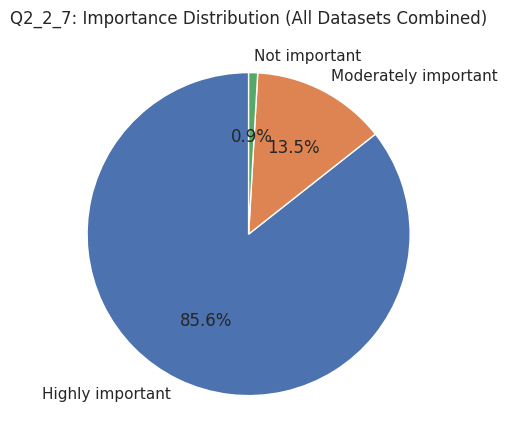

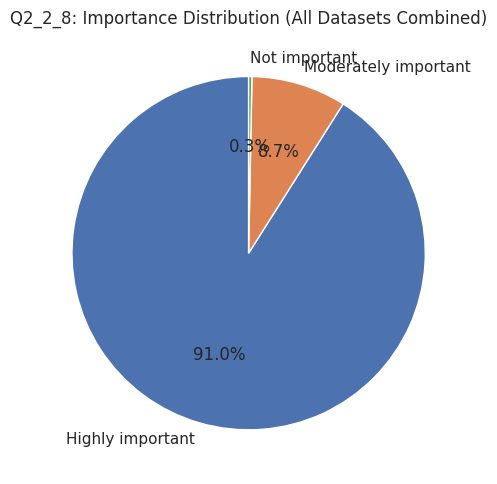

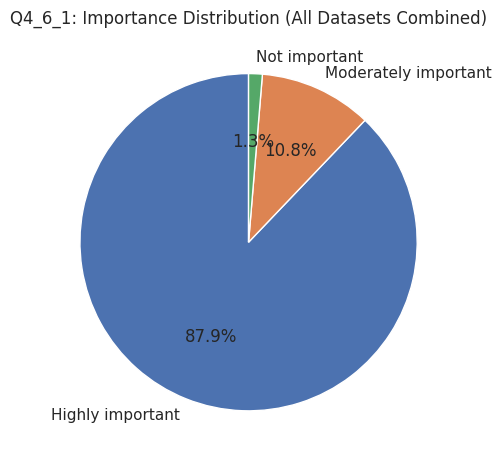

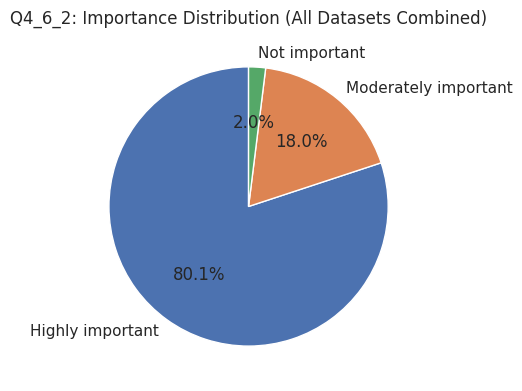

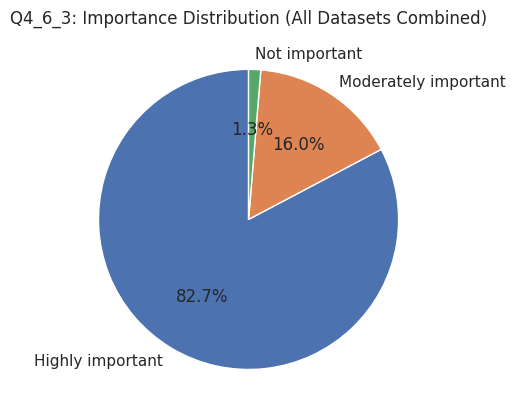

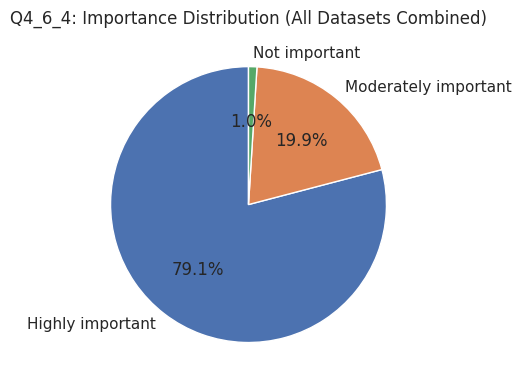

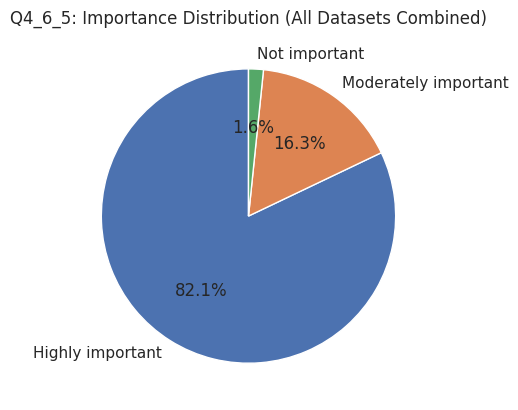

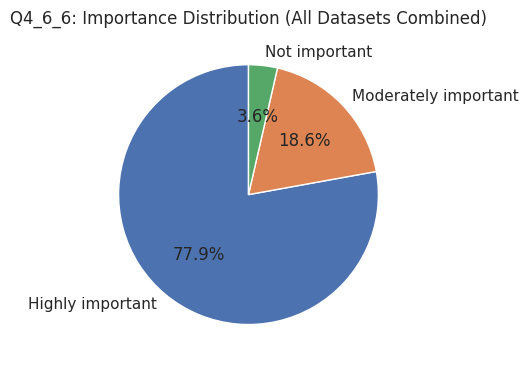

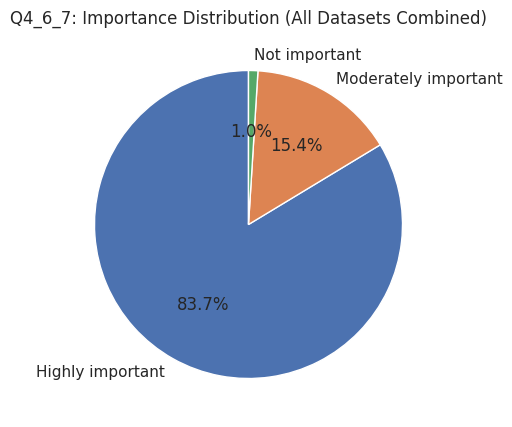

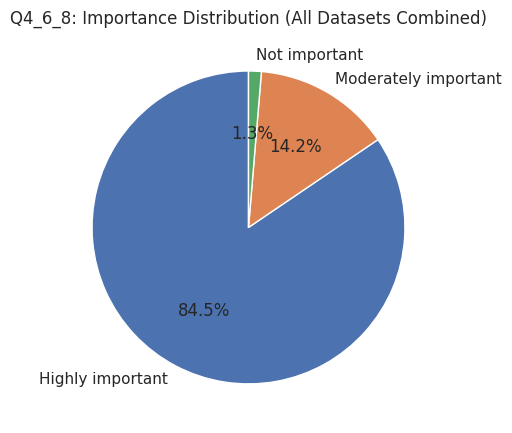

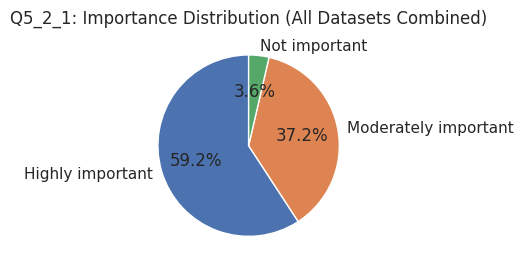

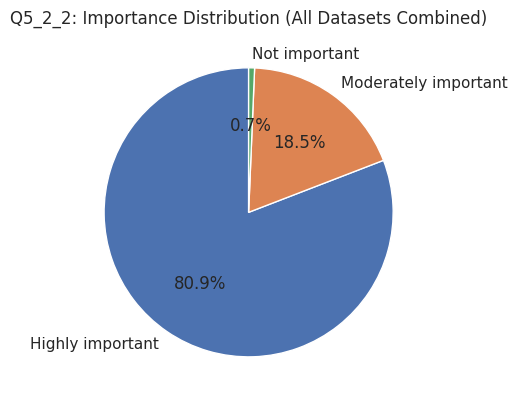

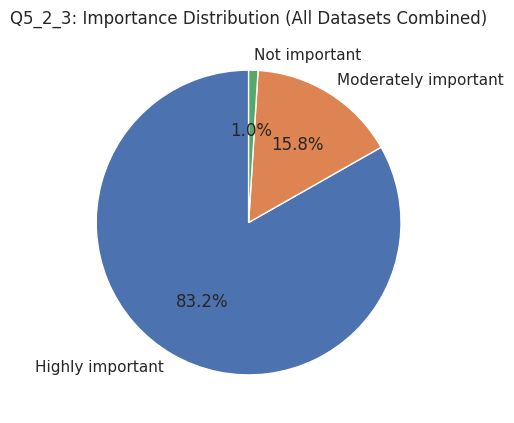

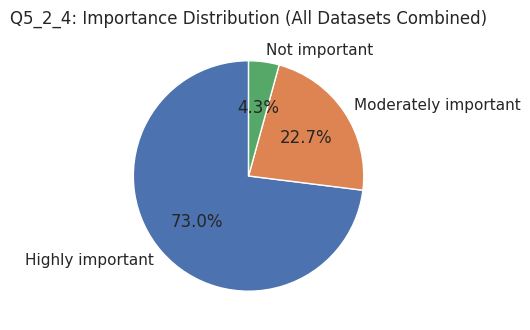

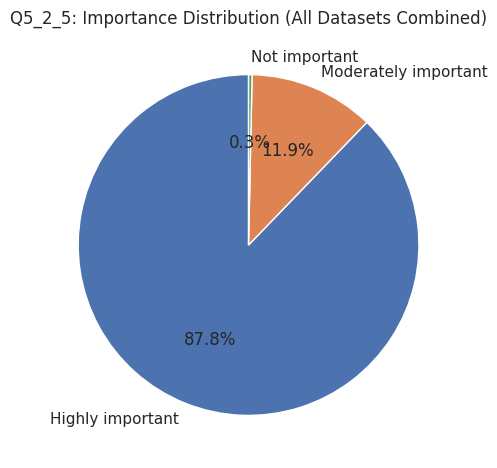

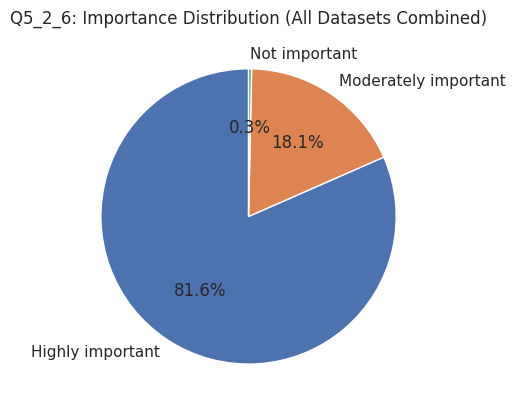

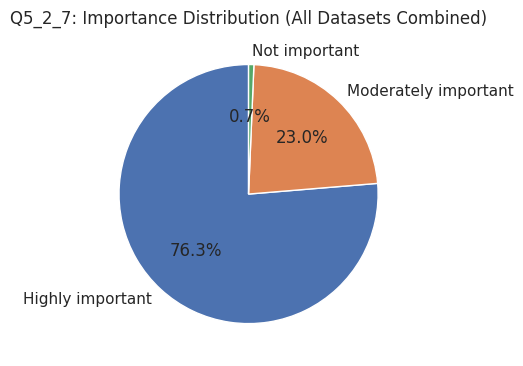

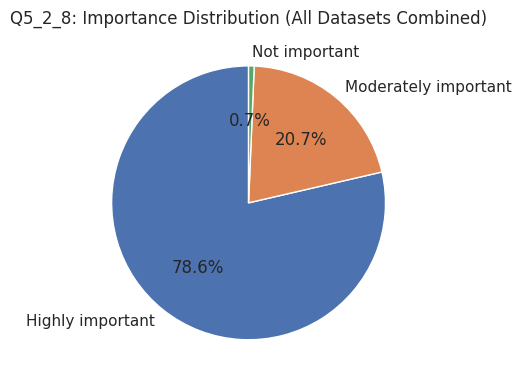

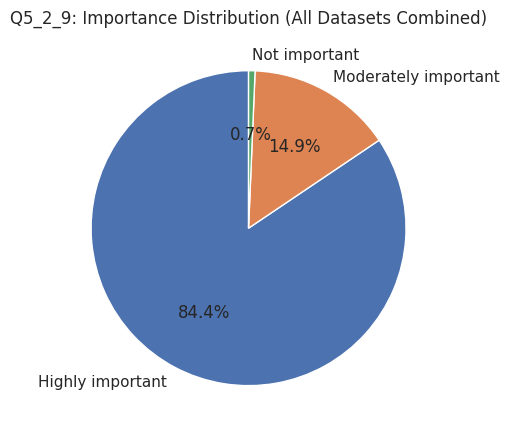

In [42]:
##Percentage Table + Pie Charts

# --- Step 1: Assume you already have regroup_labeled_df from previous step ---
# regroup_labeled_df includes text labels ("Not important", "Moderately important", "Highly important") and "dataset" column

# --- Step 2: Calculate percentage of each response for each column ---
percentage_tables = {}

for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    # Count occurrences of each category
    counts = regroup_labeled_df[col].value_counts(dropna=True)

    # Convert to percentages
    percentages = (counts / counts.sum() * 100).round(1)

    # Store results
    percentage_tables[col] = percentages

# Combine into a single DataFrame for easy viewing
percentage_df = pd.DataFrame(percentage_tables).fillna(0).T  # transpose for readability
print("=== Percentage distribution (all datasets combined) ===")
print(percentage_df)

# --- Step 3: If you want percentages grouped by dataset ---
grouped_percentages = {}

for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    grouped = (
        regroup_labeled_df.groupby("dataset")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )
    grouped_percentages[col] = grouped

# Example: show percentages for one question
print("\n=== Example grouped percentage for Q2.2_1 ===")
print(grouped_percentages["Q2_2_1"].head())

# --- Step 4: Plot pie charts for each question (combined data) ---
for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    counts = regroup_labeled_df[col].value_counts(dropna=True)
    plt.figure(figsize=(5, 5))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f"{col}: Importance Distribution (All Datasets Combined)")
    plt.tight_layout()
    plt.show()


In [43]:
 sns.barplot?

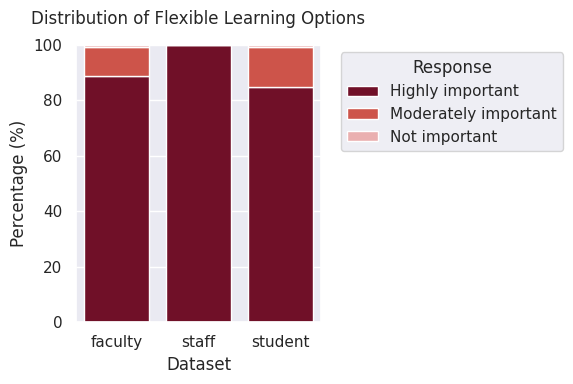

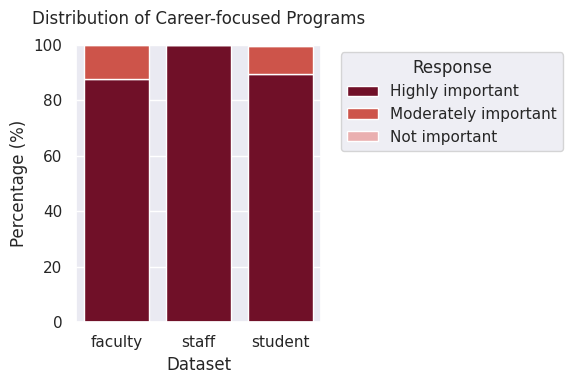

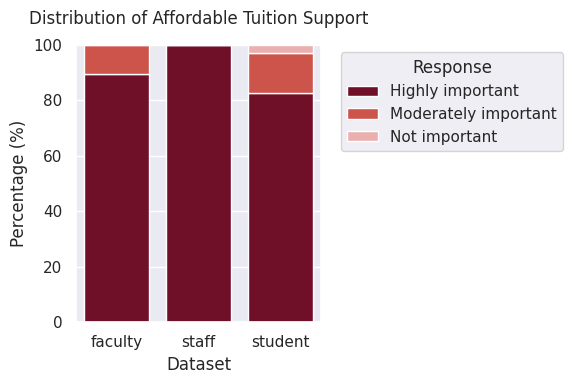

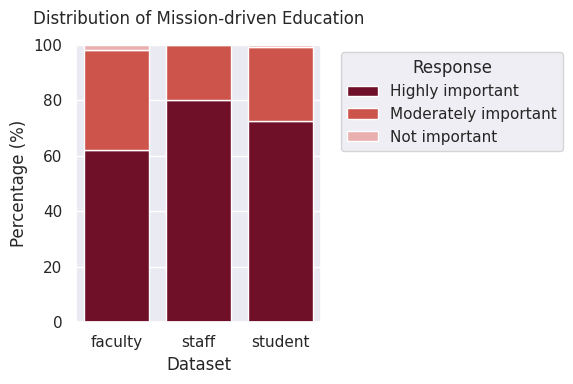

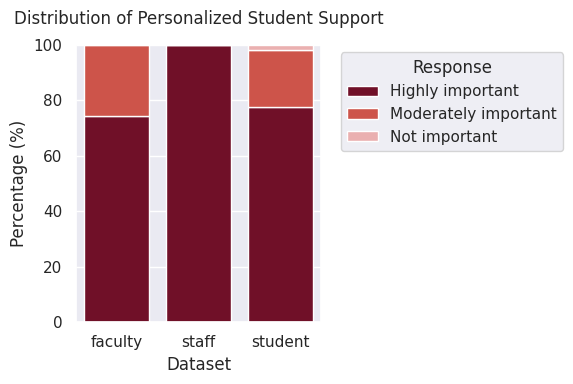

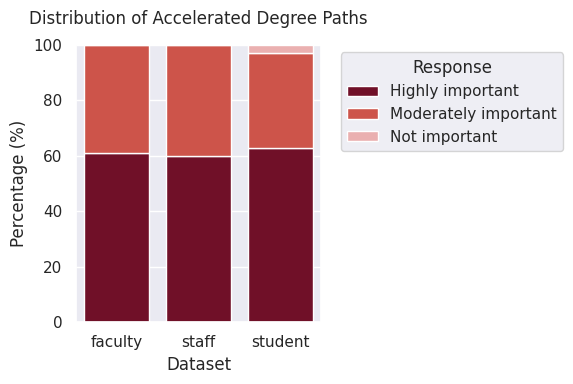

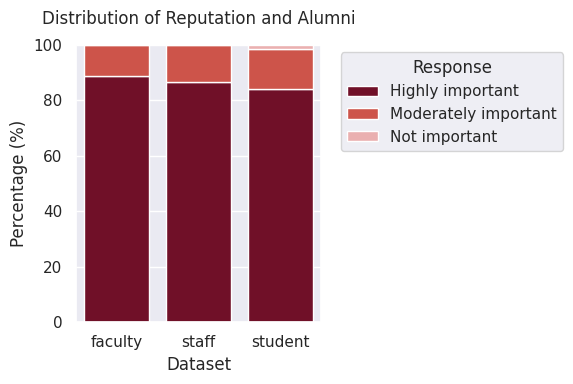

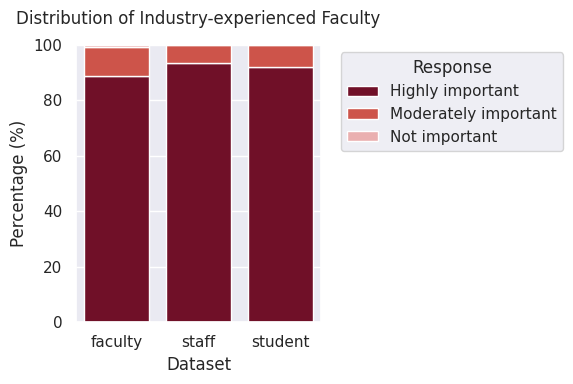

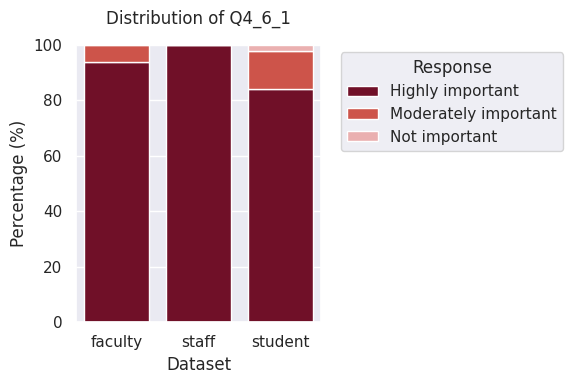

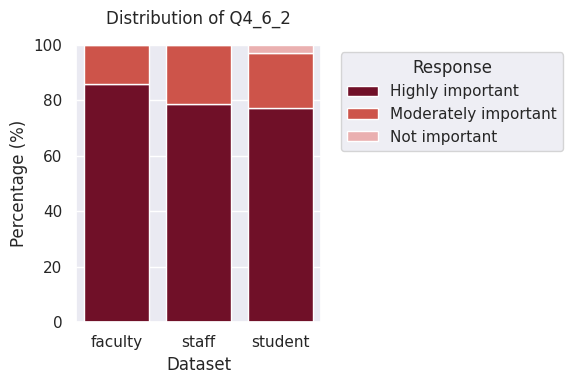

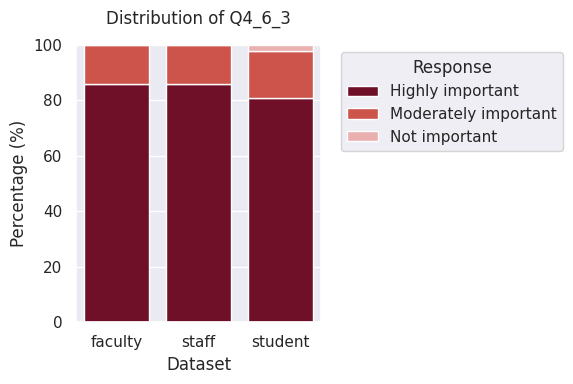

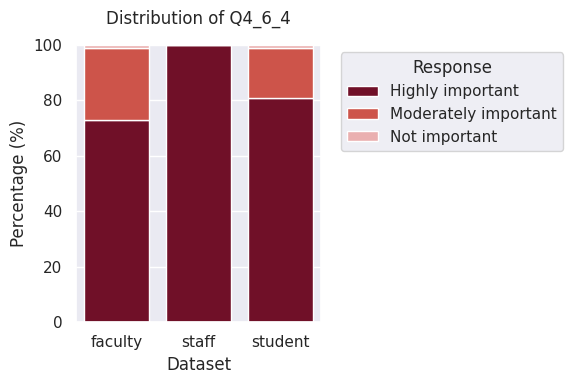

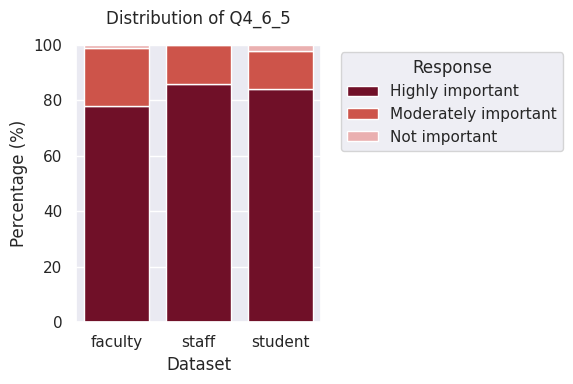

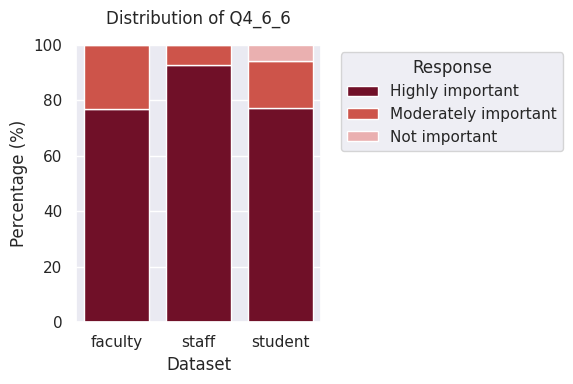

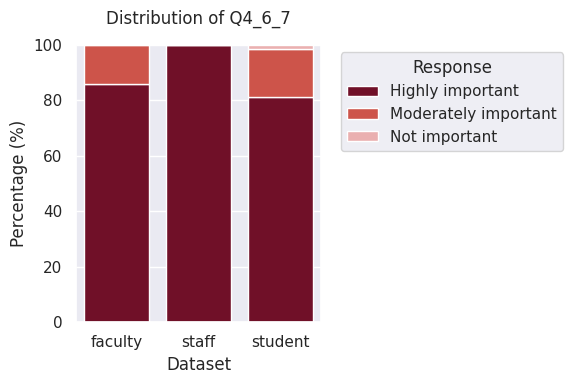

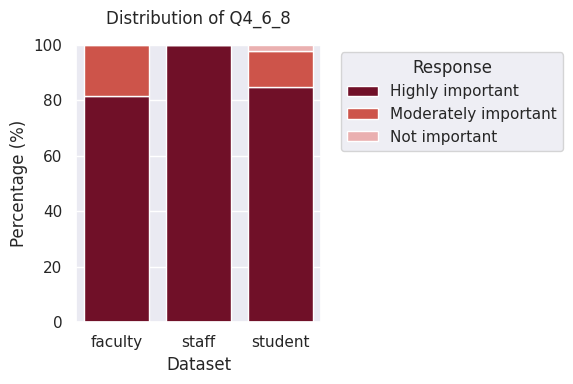

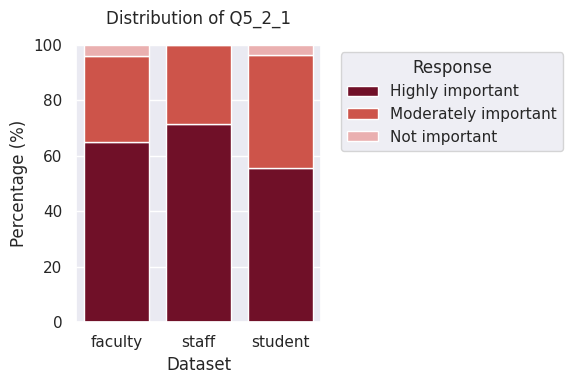

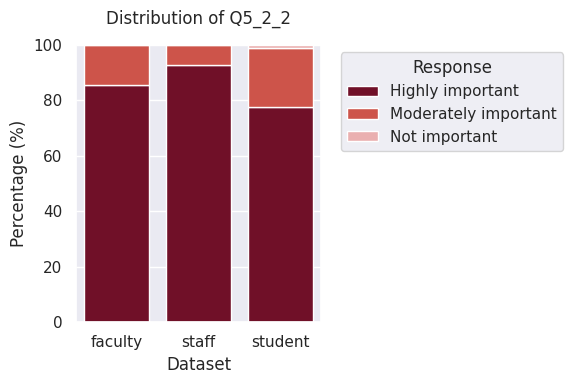

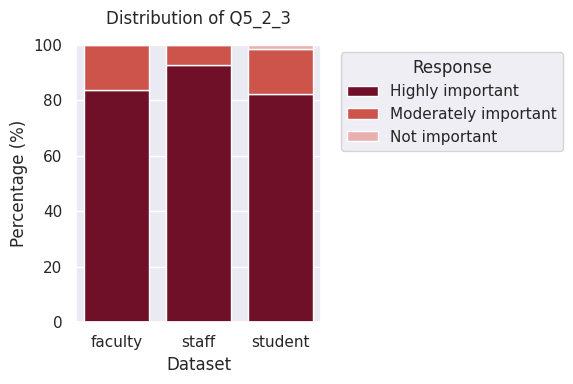

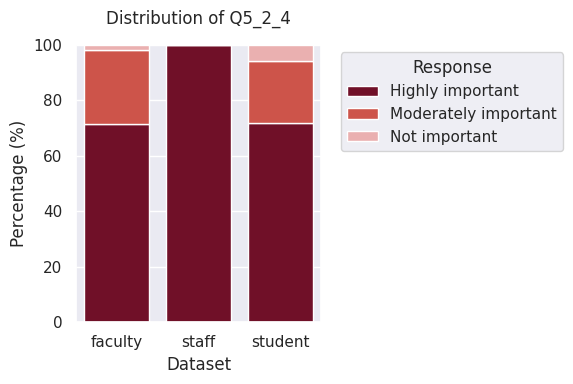

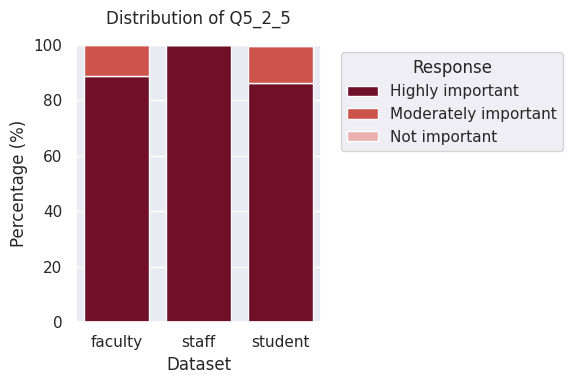

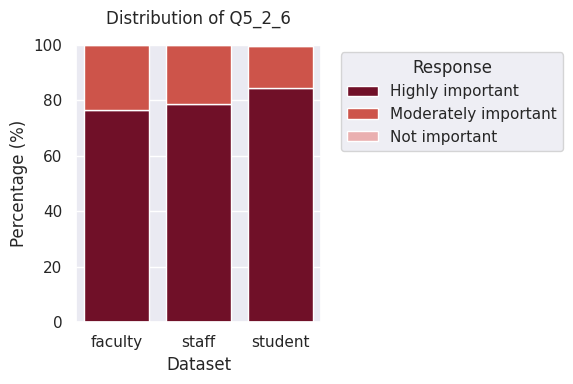

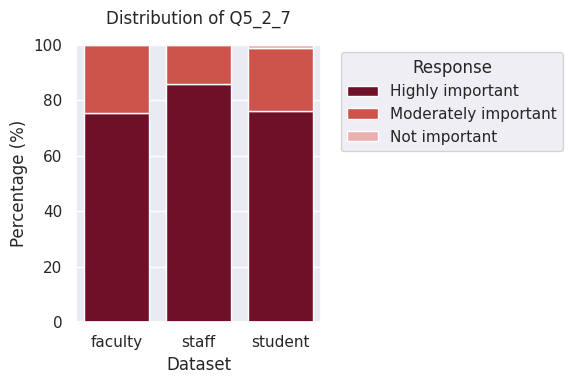

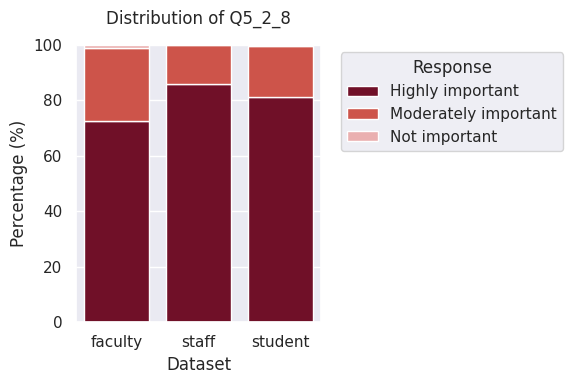

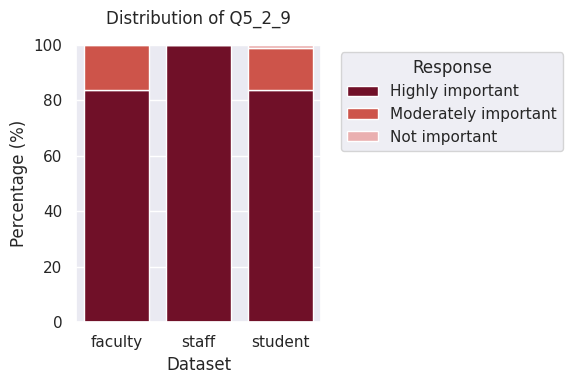

In [44]:
## Stacked Bar Charts
# --- Step 1: Define the response order (so colors stay consistent) ---
response_order = ["Highly important", "Moderately important", "Not important"]

# --- Step 2: Define the mapping for titles ---
title_mapping = {
    'Q2_2_1': 'Flexible Learning Options',
    'Q2_2_2': 'Career-focused Programs',
    'Q2_2_3': 'Affordable Tuition Support',
    'Q2_2_4': 'Mission-driven Education',
    'Q2_2_5': 'Personalized Student Support',
    'Q2_2_6': 'Accelerated Degree Paths',
    'Q2_2_7': 'Reputation and Alumni',
    'Q2_2_8': 'Industry-experienced Faculty'
}

# --- Step 3: Loop through each question ---
for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    # Calculate percentage distribution by dataset
    grouped = (
        regroup_labeled_df.groupby("dataset")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )

    # Pivot to wide format
    pivot = grouped.pivot(index="dataset", columns=col, values="Percentage").fillna(0)

    # Reorder columns for consistent color order
    pivot = pivot.reindex(columns=response_order, fill_value=0)

    # --- Step 4: Plot stacked bar chart using seaborn.barplot ---
    plt.figure(figsize=(6, 4))
    bottom = None
    for response in response_order:
        sns.barplot(
            x=pivot.index,
            y=pivot[response],
            label=response,
            color=["#800020", "#E34234", "#F4A6A6"][response_order.index(response)], # use consistent colors
            bottom=bottom,
            errorbar=('ci', 95) # display 95% confidence interval
        )
        if bottom is None:
            bottom = pivot[response]
        else:
            bottom += pivot[response]

    # Get the title text from mapping
    title_text = title_mapping.get(col, col)  # fallback to col if not in mapping
    plt.title(f"Distribution of {title_text}", fontsize=12, pad=15)  # pad adds space
    plt.ylabel("Percentage (%)")
    plt.xlabel("Dataset")
    plt.xticks(rotation=0)
    plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

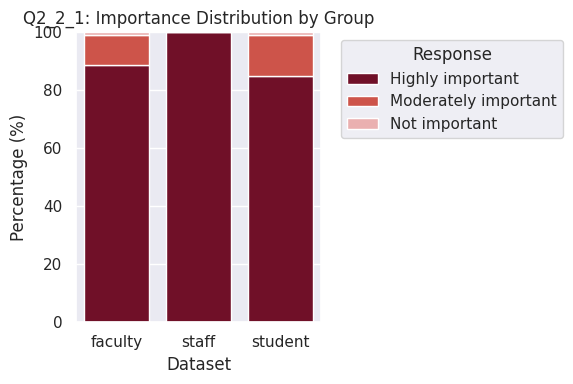

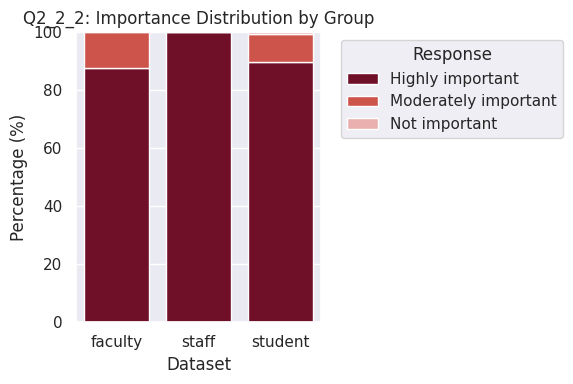

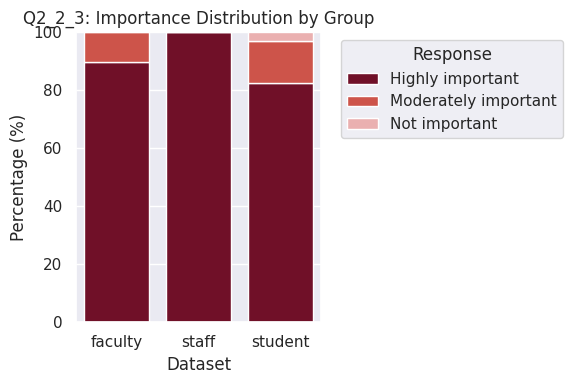

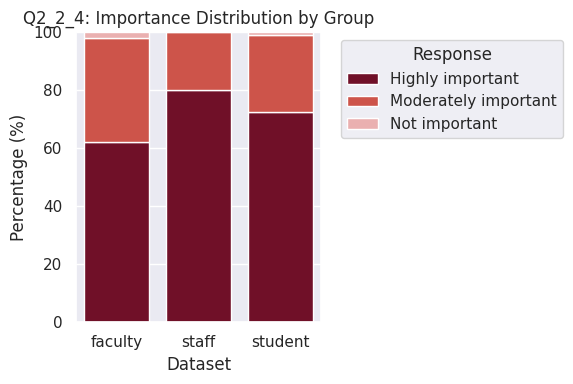

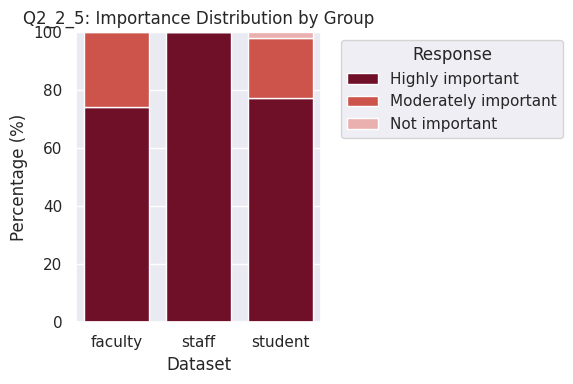

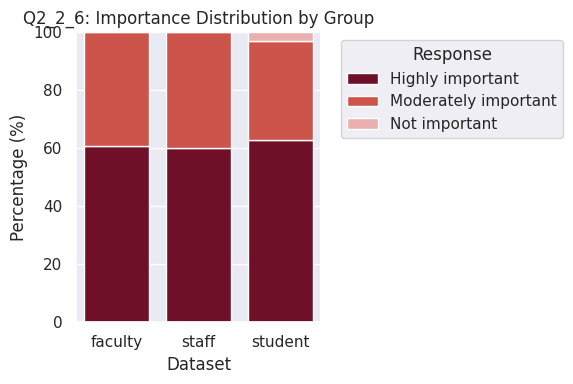

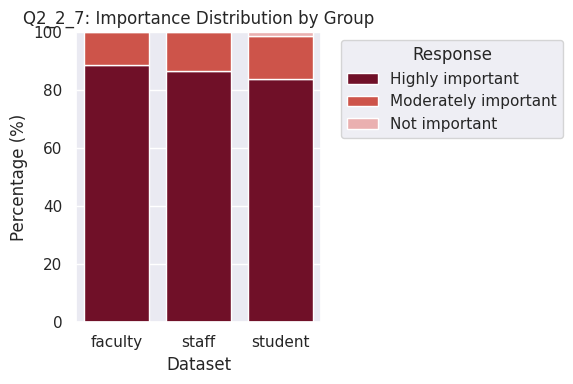

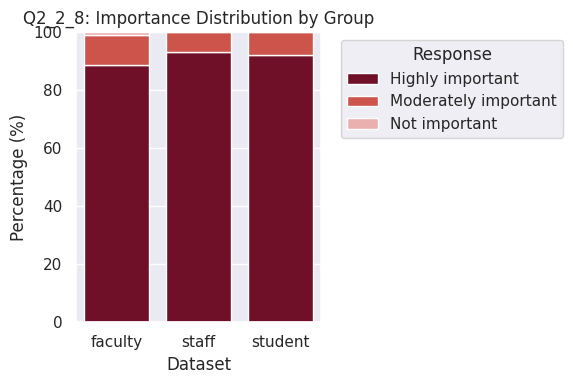

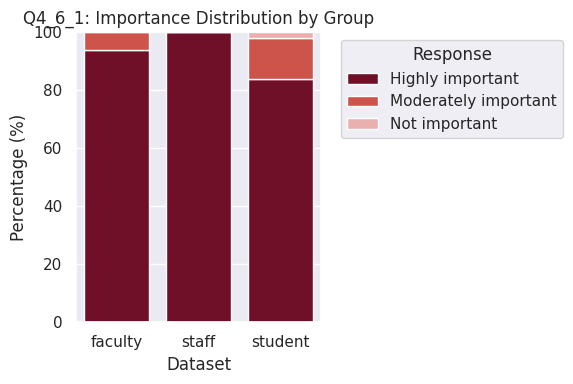

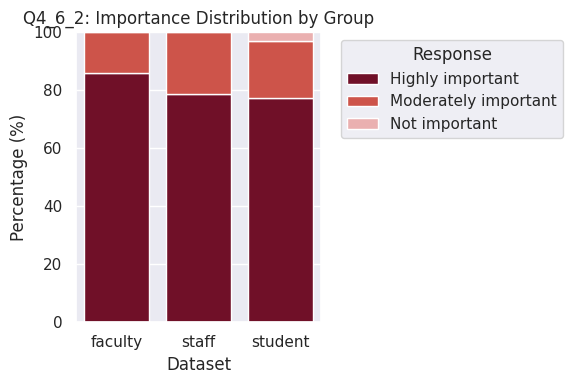

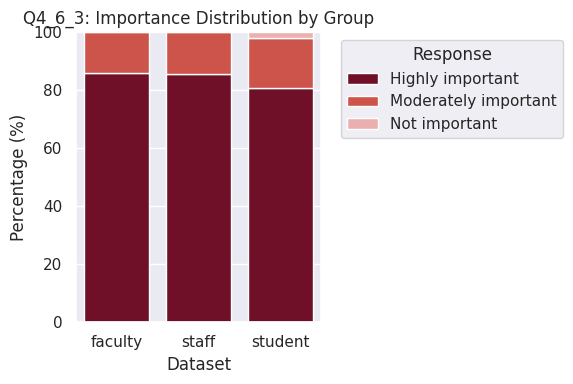

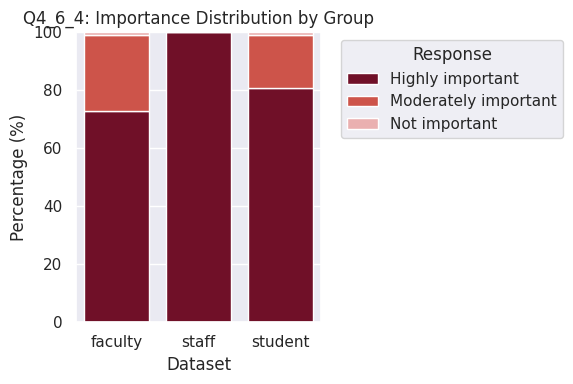

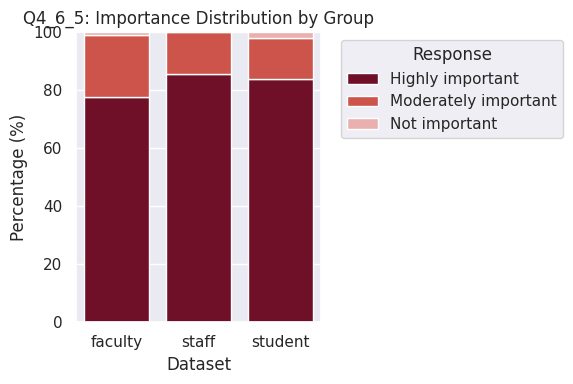

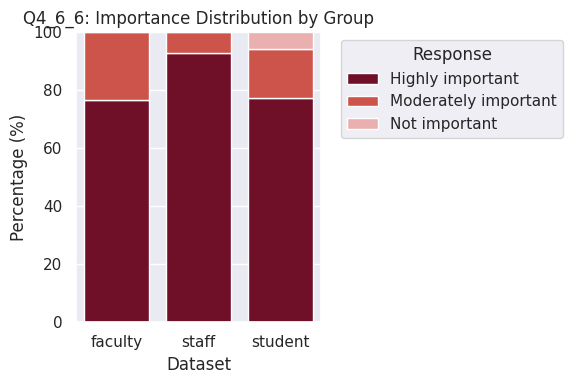

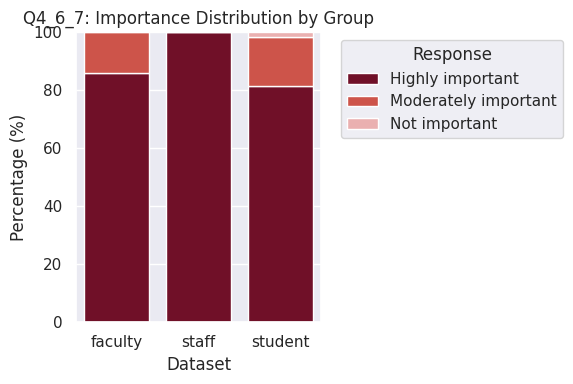

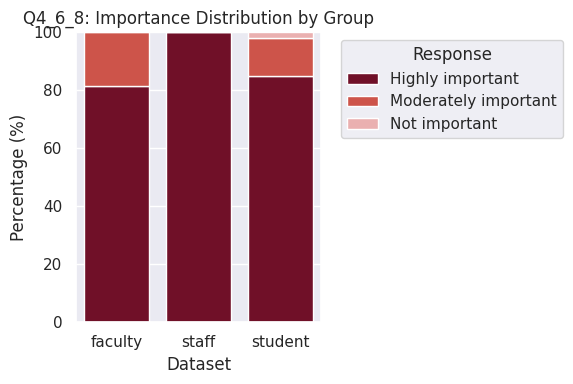

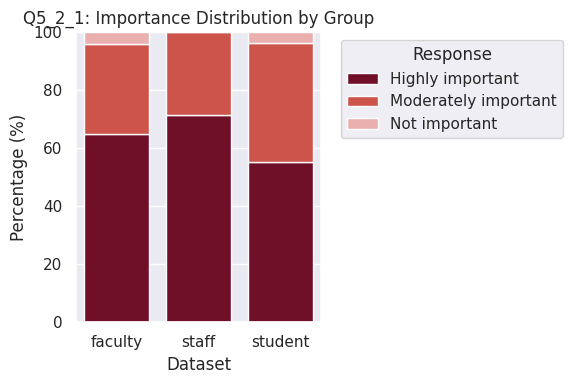

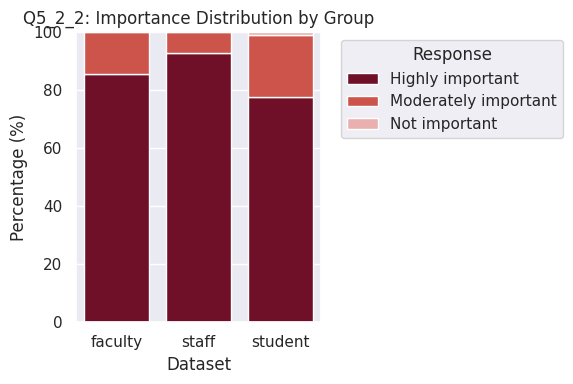

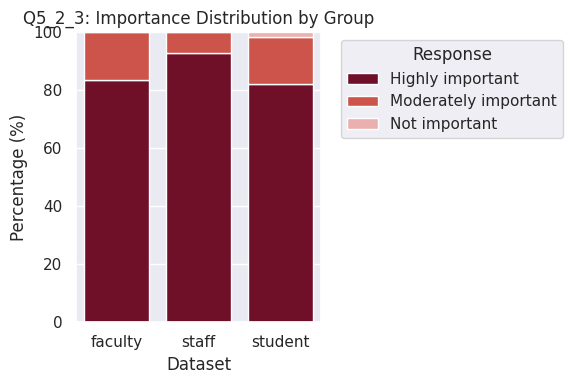

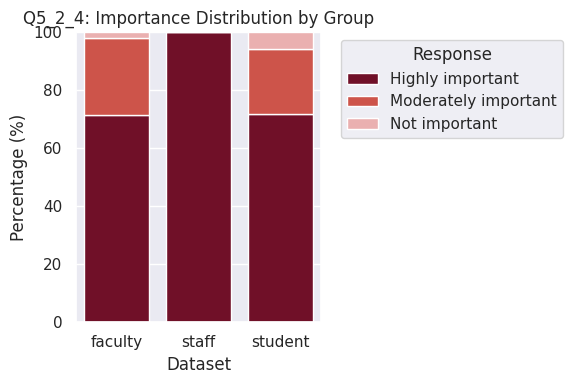

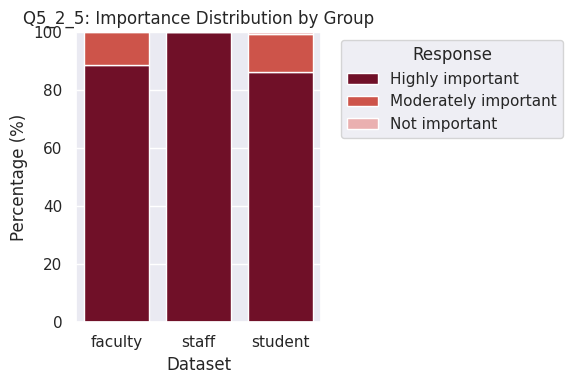

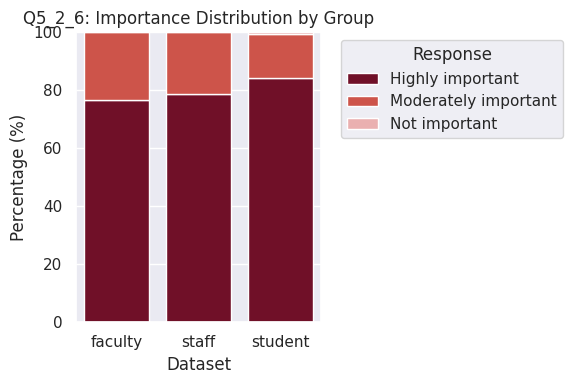

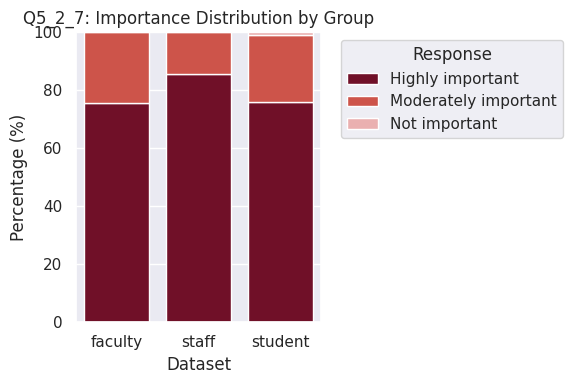

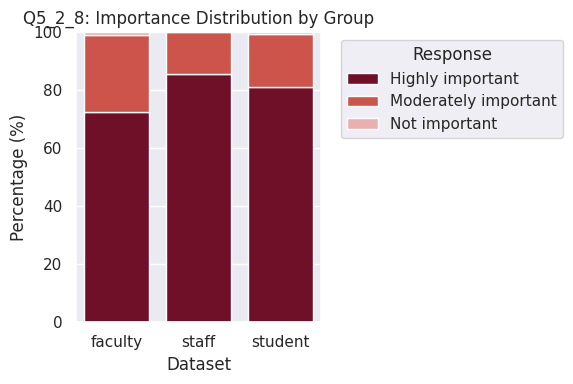

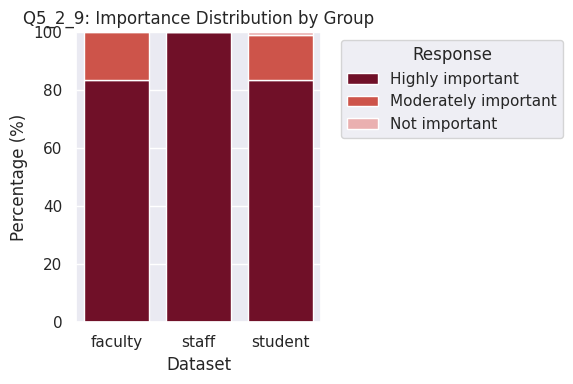

In [45]:
## Stacked Bar Charts
# --- Step 1: Define the response order (so colors stay consistent) ---
response_order = ["Highly important", "Moderately important", "Not important"]

# --- Step 2: Loop through each question ---
for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    # Calculate percentage distribution by dataset
    grouped = (
        regroup_labeled_df.groupby("dataset")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )

    # Pivot to wide format
    pivot = grouped.pivot(index="dataset", columns=col, values="Percentage").fillna(0)

    # Reorder columns for consistent color order
    pivot = pivot.reindex(columns=response_order, fill_value=0)

    # --- Step 3: Plot stacked bar chart using seaborn.barplot ---
    plt.figure(figsize=(6, 4))
    bottom = None
    for response in response_order:
        sns.barplot(
            x=pivot.index,
            y=pivot[response],
            label=response,
            color=["#800020", "#E34234", "#F4A6A6"][response_order.index(response)], # use consistent colors
            bottom=bottom,
            errorbar=('ci', 95) # display 95% confidence interval
        )
        if bottom is None:
            bottom = pivot[response]
        else:
            bottom += pivot[response]

    plt.title(f"{col}: Importance Distribution by Group", fontsize=12)
    plt.ylabel("Percentage (%)")
    plt.xlabel("Dataset")
    plt.xticks(rotation=0)
    plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

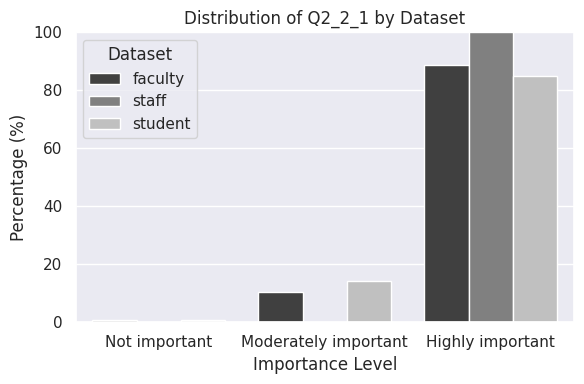

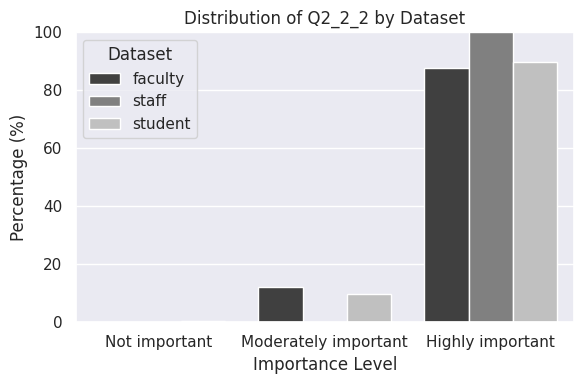

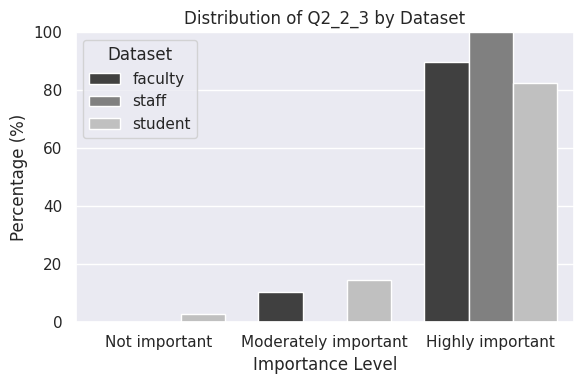

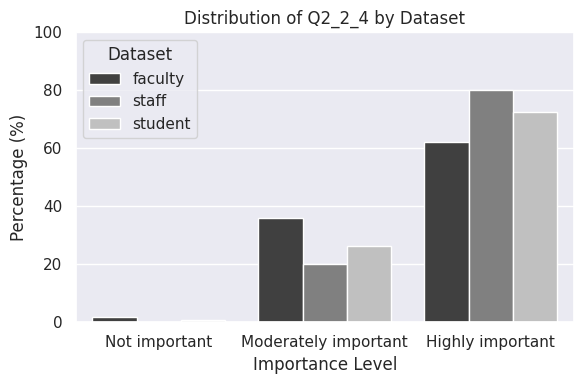

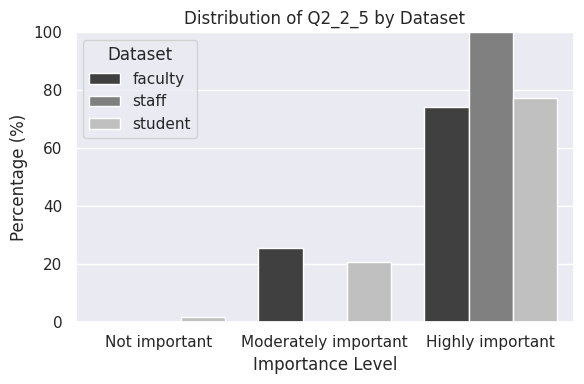

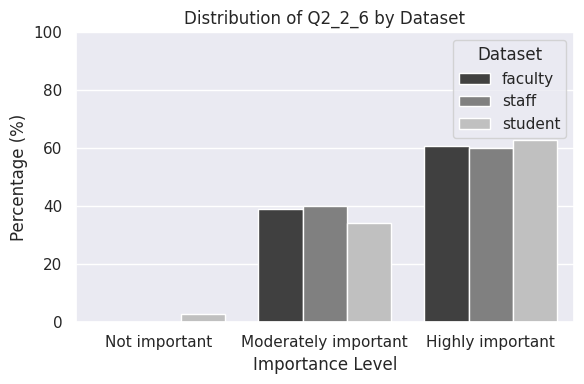

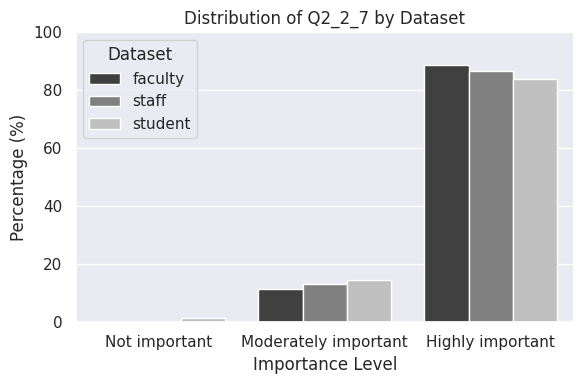

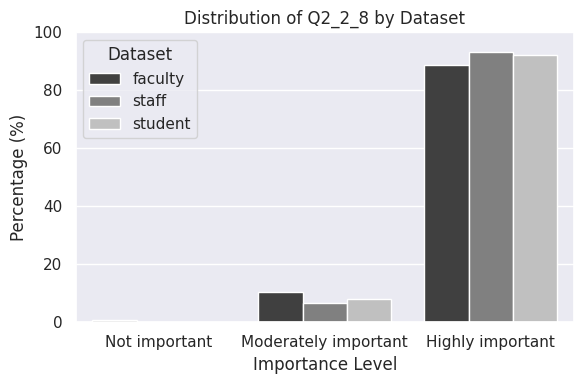

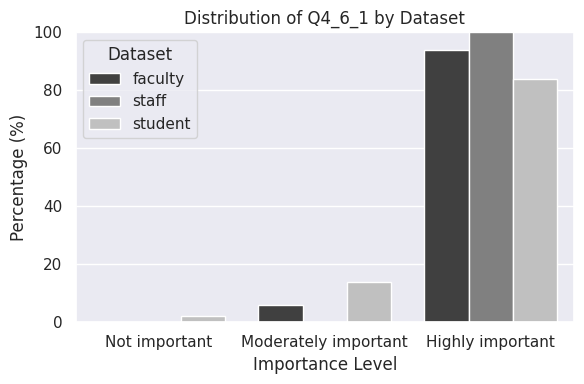

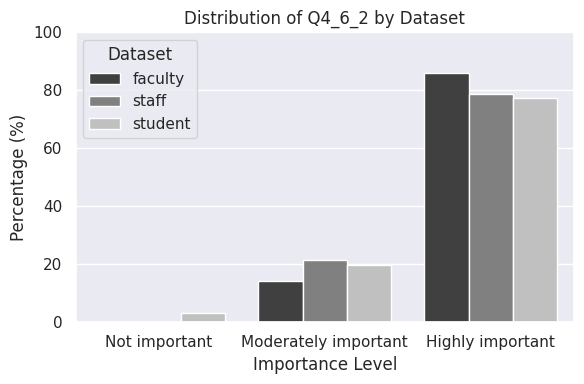

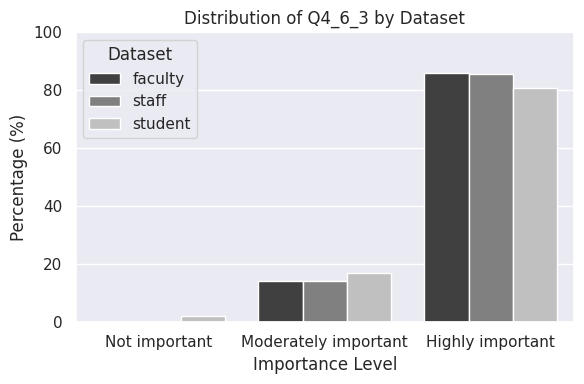

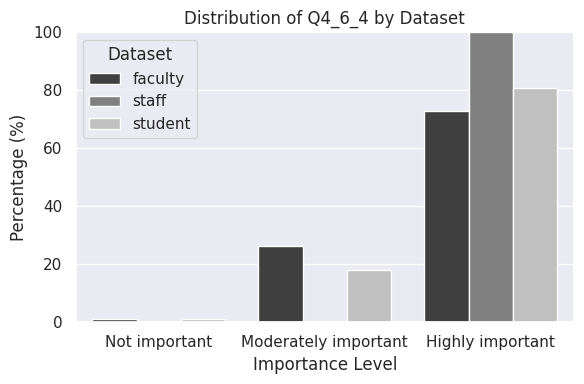

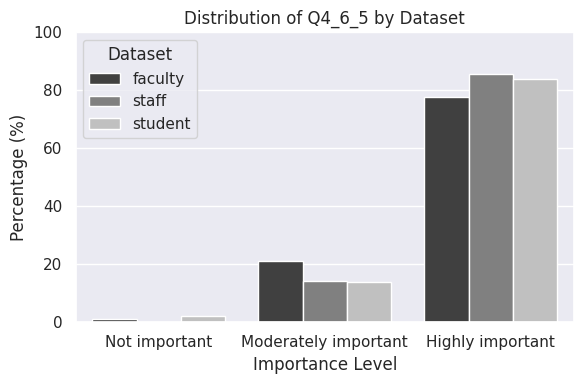

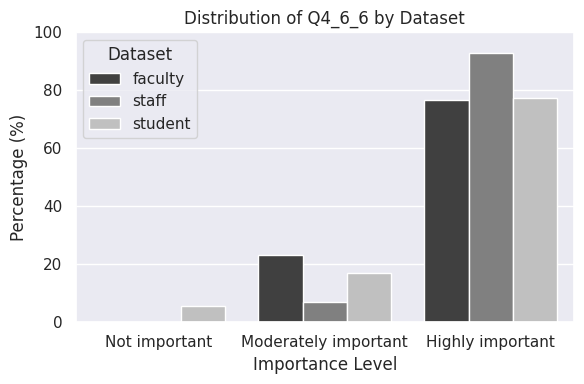

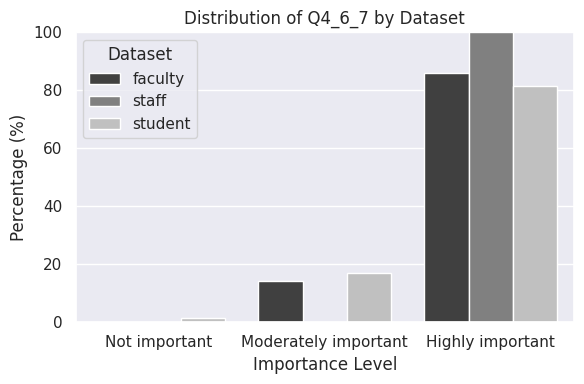

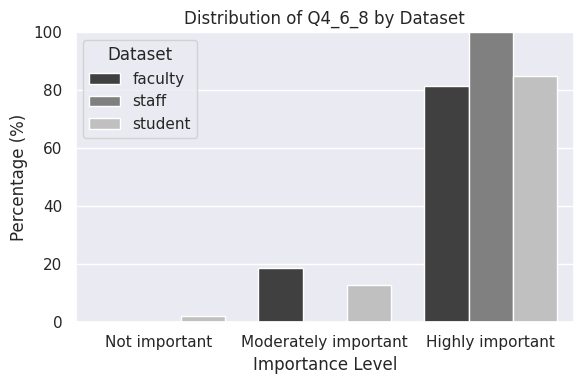

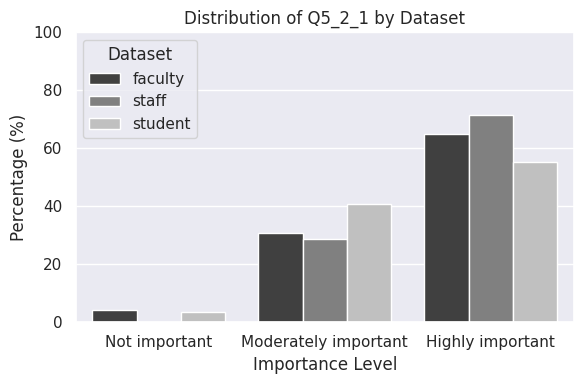

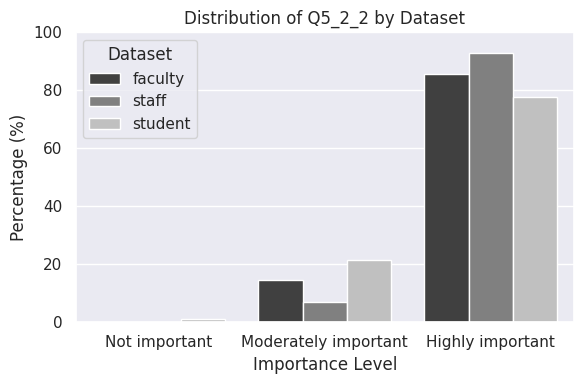

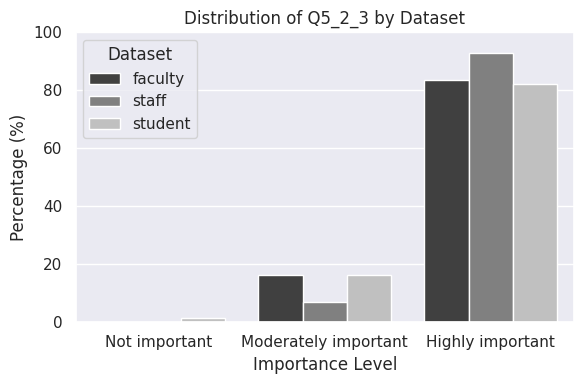

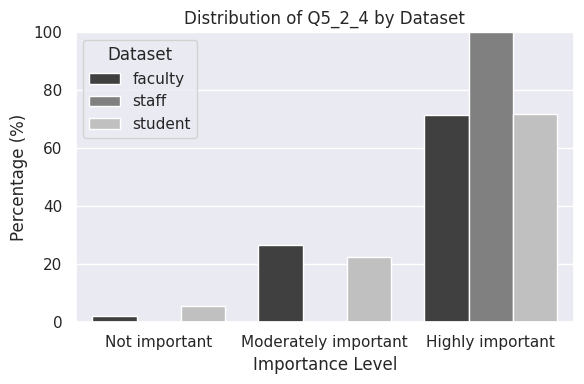

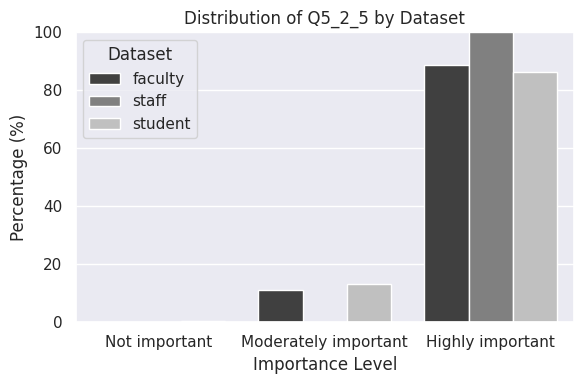

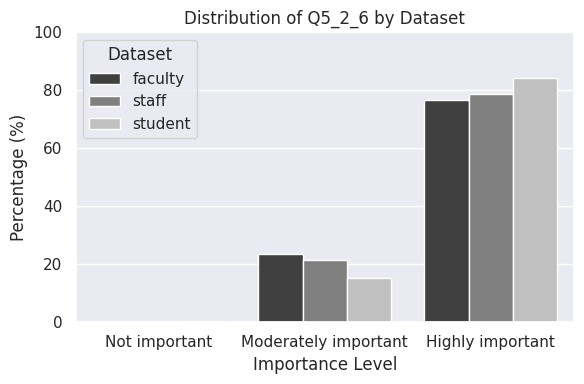

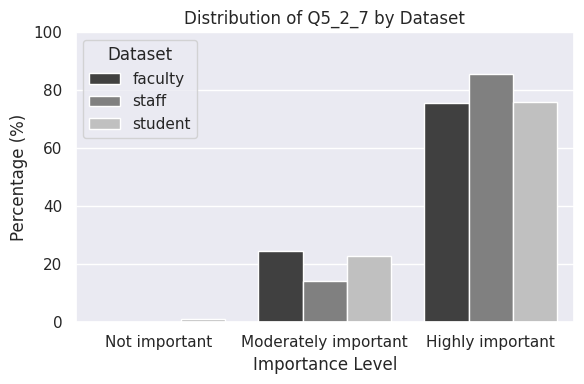

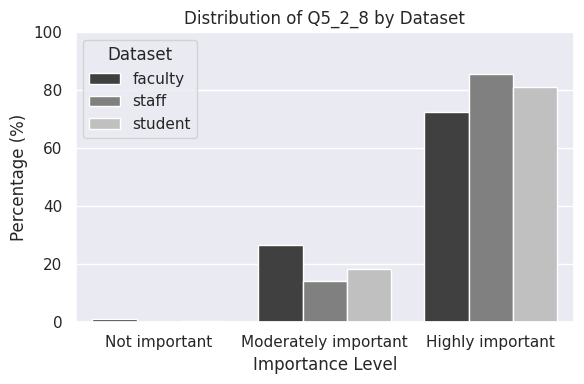

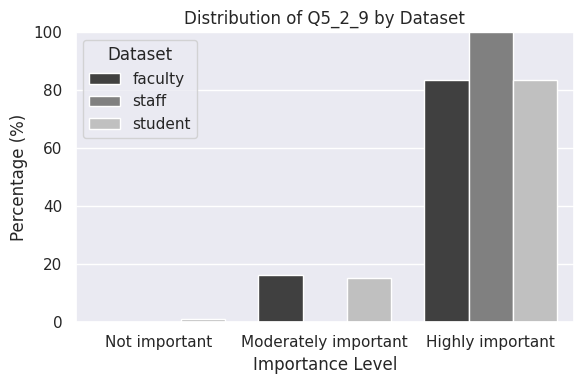

In [46]:
# Define the order of response categories
response_order = ["Not important", "Moderately important", "Highly important"]

cols = [col for col in regroup_labeled_df.columns if col != 'dataset']

# Step 1: Calculate percentage distribution by dataset and restructure for barplot
percentage_data_list = []
for col in cols:
    grouped = (
        regroup_labeled_df.groupby("dataset")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )
    grouped['Question'] = col  # Add a column to identify the question
    percentage_data_list.append(grouped)

percentage_df_long = pd.concat(percentage_data_list)

# Step 2: plot each column with the same y-axis
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=percentage_df_long[percentage_df_long['Question'] == col], # Filter data for the current question
        x=col,
        y='Percentage',
        hue='dataset',
        order=response_order,
        palette='gray', # Changed color palette back to gray
        errorbar=('ci', 95), # errorbar is supported by barplot
        capsize=0.1 # Add caps to the error bars for better visibility
    )
    plt.title(f'Distribution of {col} by Dataset')
    plt.xlabel('Importance Level')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 100) # Set y-limit to 100%
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()

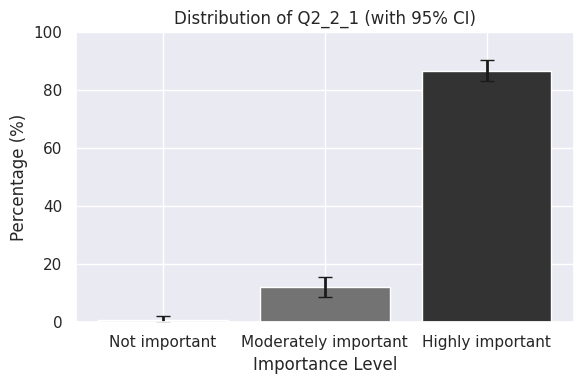

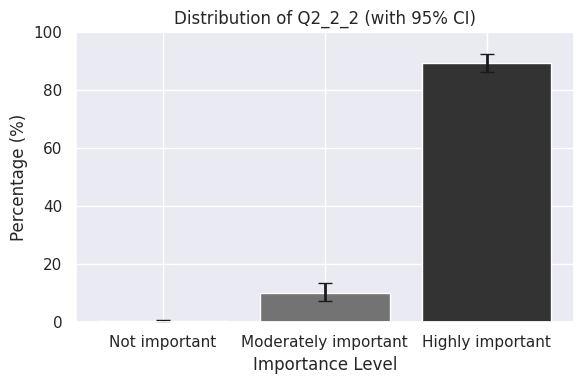

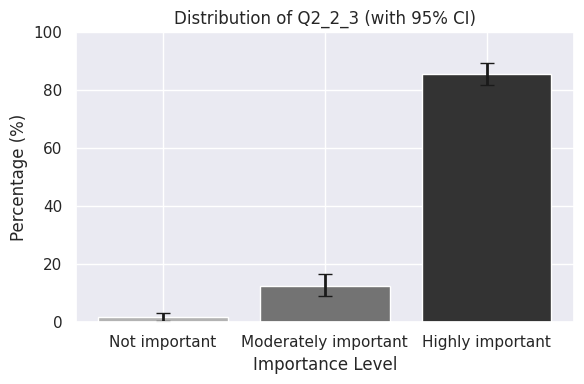

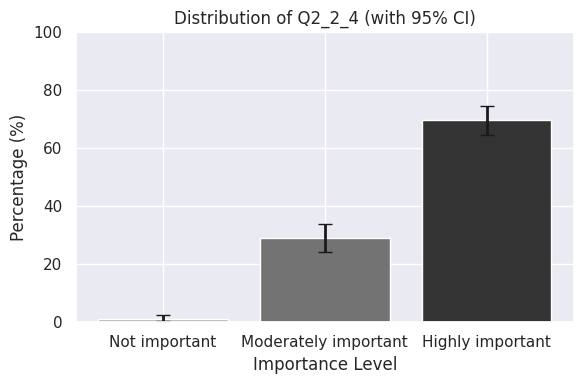

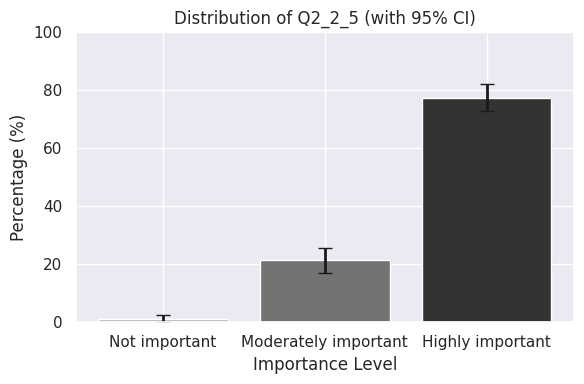

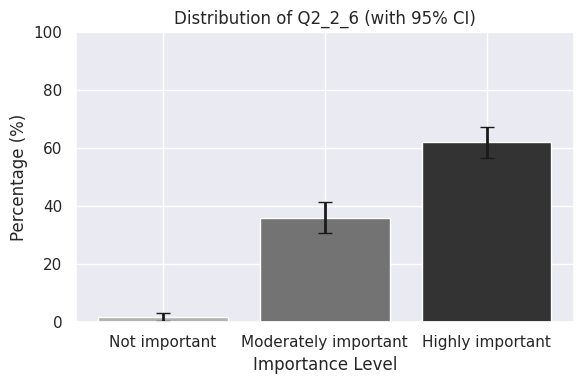

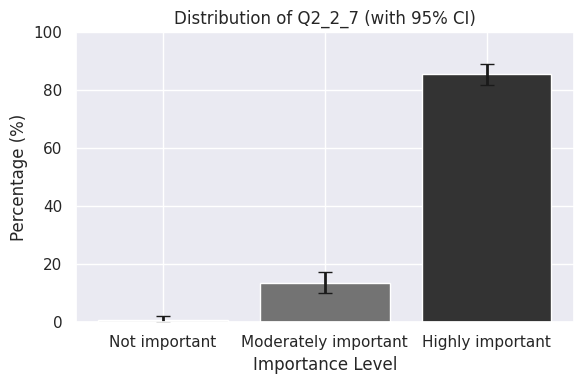

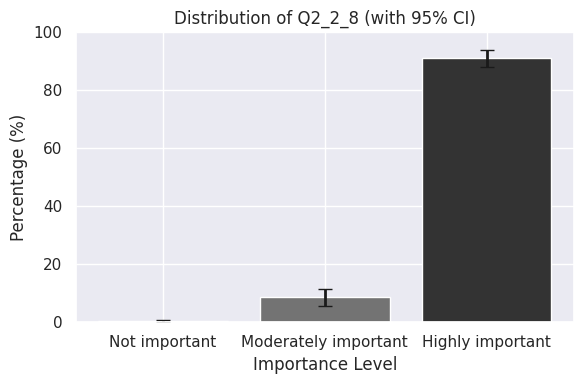

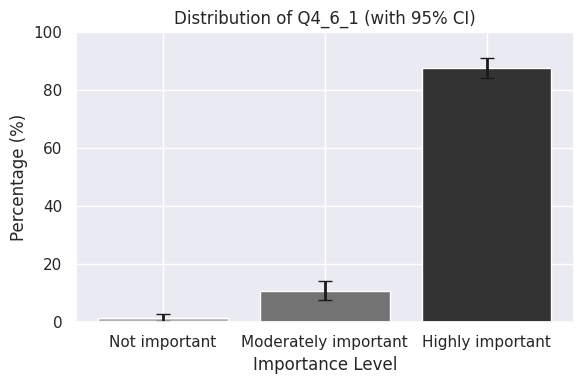

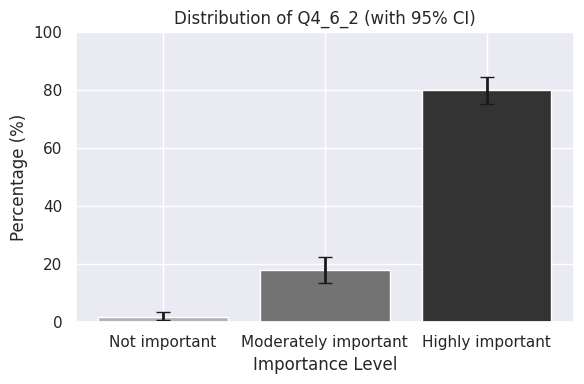

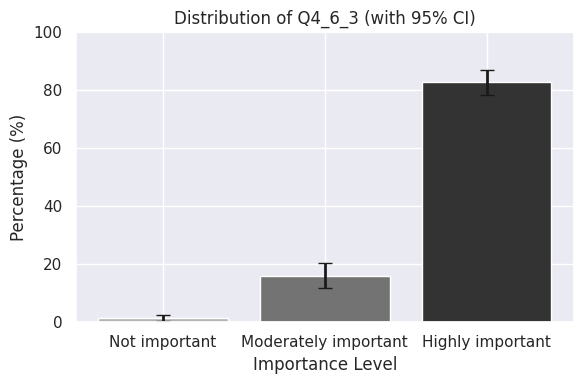

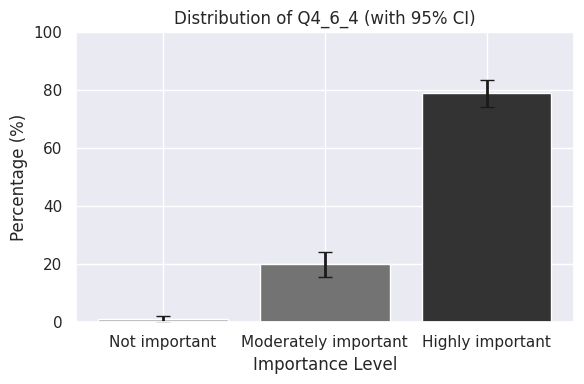

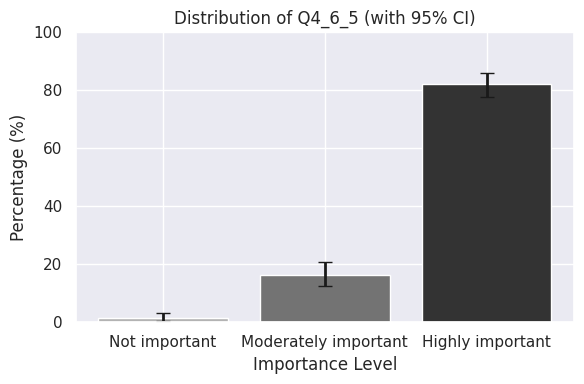

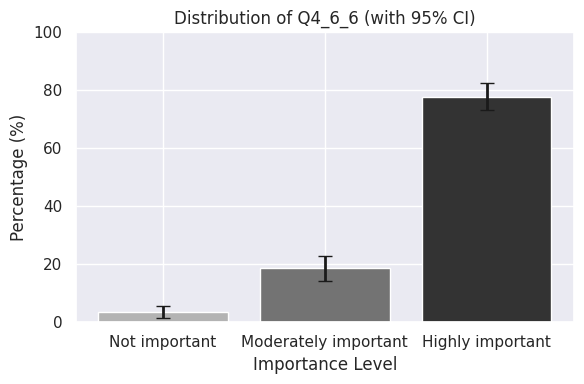

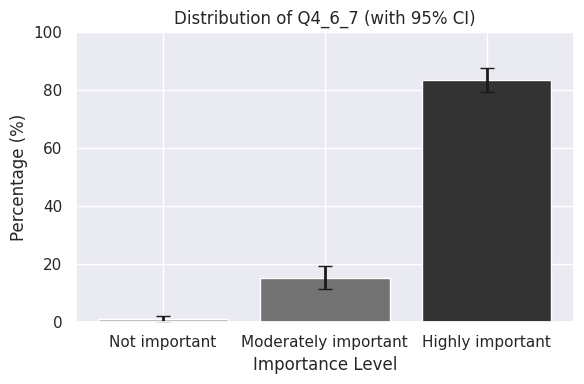

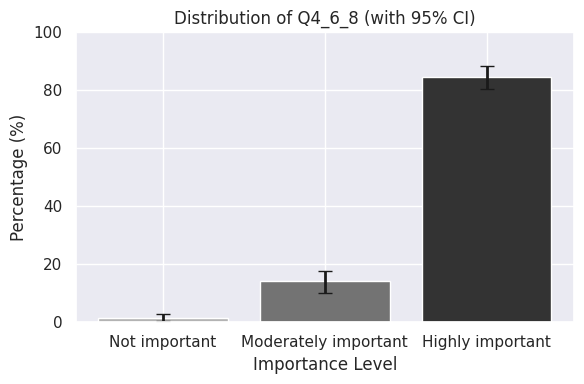

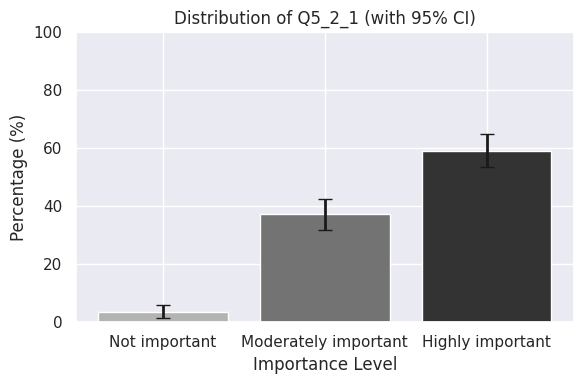

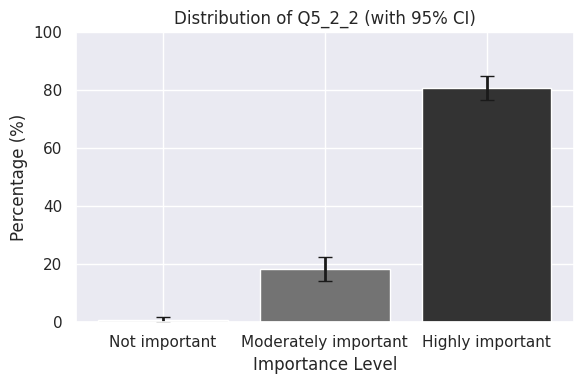

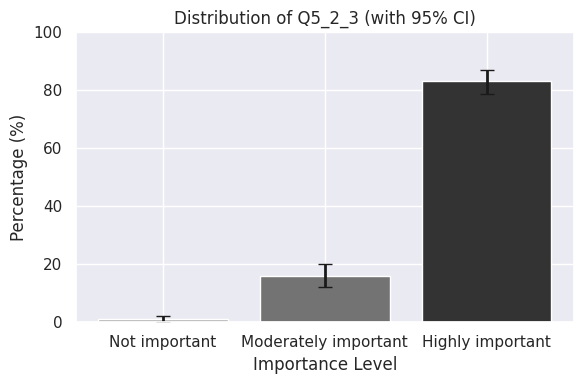

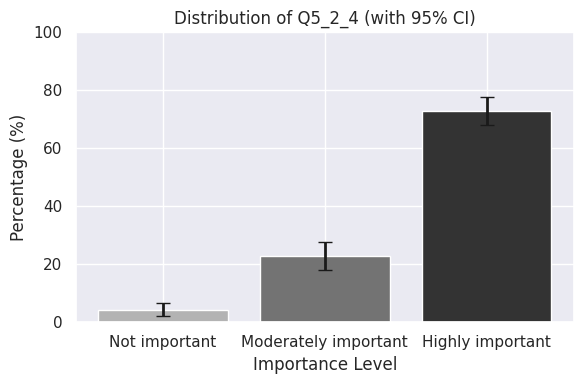

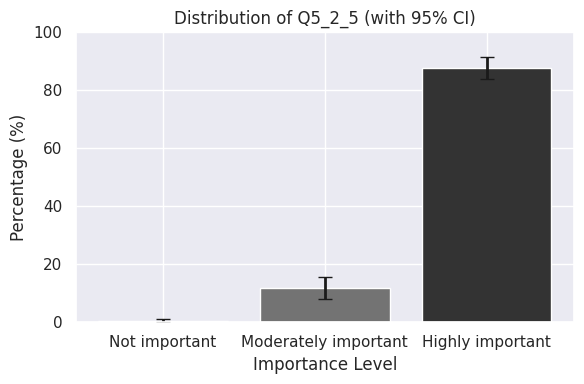

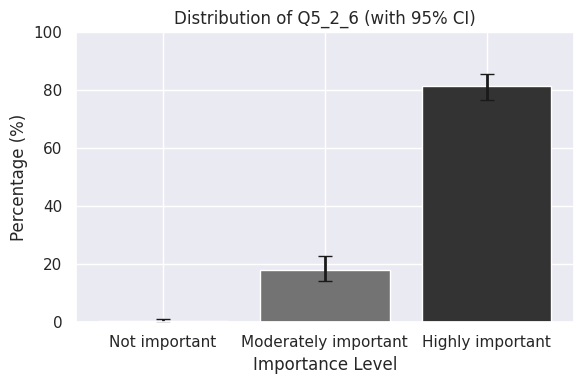

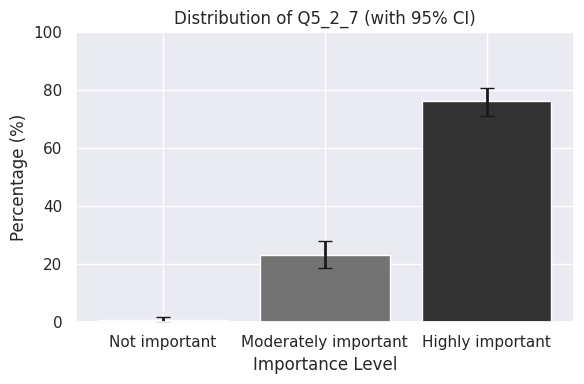

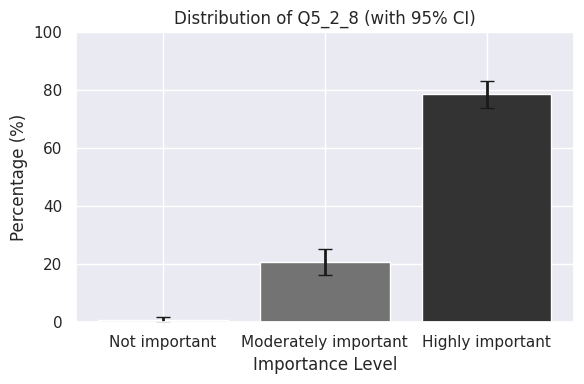

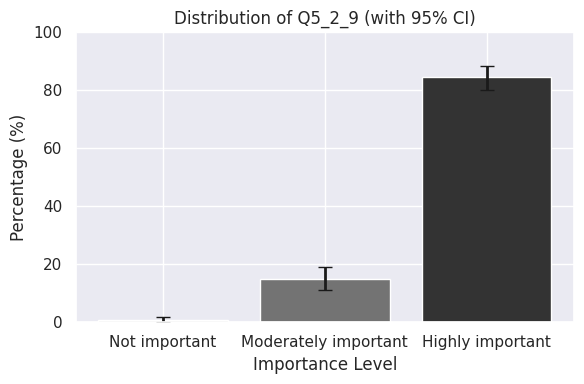

In [47]:
for col in cols:
    plt.figure(figsize=(6, 4))

    # Calculate observed proportions
    value_counts = regroup_labeled_df[col].value_counts(normalize=True).mul(100)
    value_counts = value_counts.reindex(response_order, fill_value=0)

    # Bootstrap to calculate confidence intervals
    n_bootstrap = 1000
    bootstrap_props = {category: [] for category in response_order}

    for _ in range(n_bootstrap):
        # Resample with replacement
        bootstrap_sample = regroup_labeled_df[col].sample(n=len(regroup_labeled_df), replace=True)
        bootstrap_counts = bootstrap_sample.value_counts(normalize=True).mul(100)

        for category in response_order:
            bootstrap_props[category].append(bootstrap_counts.get(category, 0))

    # Calculate CI for each category
    ci_lower = []
    ci_upper = []
    for category in response_order:
        ci = np.percentile(bootstrap_props[category], [2.5, 97.5])
        ci_lower.append(value_counts[category] - ci[0])
        ci_upper.append(ci[1] - value_counts[category])

    # Plot with error bars
    x_pos = np.arange(len(response_order))
    colors = plt.cm.gray_r(np.linspace(0.3, 0.8, len(response_order)))

    plt.bar(x_pos, value_counts.values, color=colors, yerr=[ci_lower, ci_upper],
            capsize=5, error_kw={'linewidth': 2})

    plt.xticks(x_pos, response_order)
    plt.title(f'Distribution of {col} (with 95% CI)')
    plt.xlabel('Importance Level')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [48]:
# --- Calculate percentage of each response for all questions ---
percentage_tables = {}
for col in [c for c in regroup_labeled_df.columns if c != "dataset"]:
    counts = regroup_labeled_df[col].value_counts(dropna=True)
    percentages = (counts / counts.sum() * 100).round(1)
    percentage_tables[col] = percentages

# Convert to DataFrame and transpose: questions as rows
percentage_df = pd.DataFrame(percentage_tables).fillna(0).T
percentage_df.index.name = "Question"
percentage_df.reset_index(inplace=True)

# --- Order by 'Highly important' descending and select top 10 ---
top_10_df = percentage_df.sort_values(by='Highly important', ascending=False).head(10)

# --- Map question IDs to full question text ---
# Need to use original column names from student DataFrame
second_row = student.iloc[0]  # Use index 0 for the row with full question text
# Create a mapping from modified column names (with underscores) to original column names (with dots)
col_name_mapping = {c.replace('.', '_'): c for c in student.columns}

# Map the question IDs in top_10_df to the original column names
original_cols = [col_name_mapping[col] for col in top_10_df['Question']]

top_10_questions = second_row[original_cols]
top_10_df['Question Text'] = top_10_questions.values


# --- Keep relevant columns ---
top_10_df = top_10_df[['Question', 'Question Text', 'Not important', 'Moderately important', 'Highly important']]

# Display
pd.set_option('display.max_colwidth', None)
top_10_df

,Question,Question Text,Not important,Moderately important,Highly important
7,Q2_2_8,How important are the following aspects for promoting Augustin College to future students? - Strong faculty with industry experience,0.3,8.7,91.0
1,Q2_2_2,How important are the following aspects for promoting Augustin College to future students? - Career-focused programs aligned with workforce needs,0.3,10.2,89.5
8,Q4_6_1,How important are the following priorities for preparing students for life after Augustin College? - Opportunities for career networking,1.3,10.8,87.9
20,Q5_2_5,How important should each of the following ideas be in shaping the future mission of Augustin College? - Focusing on real-world impact and professional advancement,0.3,11.9,87.8
0,Q2_2_1,"How important are the following aspects for promoting Augustin College to future students? - Flexible learning Options (e.g., online, evening, hybrid)",0.9,12.3,86.8
6,Q2_2_7,How important are the following aspects for promoting Augustin College to future students? - Strong Veritus Imperial University reputation and alumni network,0.9,13.5,85.6
2,Q2_2_3,How important are the following aspects for promoting Augustin College to future students? - Competitive tuition and robust financial aid support,1.8,12.7,85.5
15,Q4_6_8,How important are the following priorities for preparing students for life after Augustin College? - Clearer alignment between academic programs and professional goals,1.3,14.2,84.5
24,Q5_2_9,How important should each of the following ideas be in shaping the future mission of Augustin College? - Aligning with the evolving challenges and opportunities of the future workforce,0.7,14.9,84.4
14,Q4_6_7,How important are the following priorities for preparing students for life after Augustin College? - Networking,1.0,15.4,83.7


In [49]:
top_10_df = top_10_df[['Question', 'Not important', 'Moderately important', 'Highly important']]

# Display
pd.set_option('display.max_colwidth', None)
top_10_df

,Question,Not important,Moderately important,Highly important
7,Q2_2_8,0.3,8.7,91.0
1,Q2_2_2,0.3,10.2,89.5
8,Q4_6_1,1.3,10.8,87.9
20,Q5_2_5,0.3,11.9,87.8
0,Q2_2_1,0.9,12.3,86.8
6,Q2_2_7,0.9,13.5,85.6
2,Q2_2_3,1.8,12.7,85.5
15,Q4_6_8,1.3,14.2,84.5
24,Q5_2_9,0.7,14.9,84.4
14,Q4_6_7,1.0,15.4,83.7


In [50]:
## contingency table + chi-square test

# --- STEP 1: Identify question columns ---
# (Exclude non-question columns like 'dataset')
question_cols = [col for col in regroup_labeled_df.columns if col != 'dataset']

# --- STEP 2: Create an empty list to store results ---
results = []

# --- STEP 3: Loop over each question and run Chi-square ---
for col in question_cols:
    # Create contingency table: counts by answer and dataset group
    contingency_table = pd.crosstab(regroup_labeled_df[col], regroup_labeled_df['dataset'])

    # Skip if the table has missing or empty values
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        continue

    # Perform chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Store results
    results.append({
        'Question': col,
        'Chi2': chi2,
        'Degrees_of_Freedom': dof,
        'p_value': p,
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

# --- STEP 4: Convert to DataFrame and sort by significance ---
chi2_results_df = pd.DataFrame(results).sort_values(by='p_value')

# --- STEP 5: Display nicely ---
pd.set_option('display.max_colwidth', None)
display(chi2_results_df.head(15))  # top 15 most significant results


,Question,Chi2,Degrees_of_Freedom,p_value,Significant (p<0.05)
13,Q4_6_6,9.231981,4,0.055556,No
8,Q4_6_1,8.564972,4,0.072942,No
19,Q5_2_4,7.975370,4,0.092485,No
4,Q2_2_5,7.566289,4,0.108821,No
2,Q2_2_3,7.272881,4,0.122151,No
11,Q4_6_4,6.592042,4,0.159083,No
15,Q4_6_8,6.296093,4,0.178100,No
9,Q4_6_2,5.347342,4,0.253478,No
14,Q4_6_7,5.009824,4,0.286291,No
3,Q2_2_4,4.653689,4,0.324711,No


In [51]:

# --- STEP 1: Identify question columns ---
question_cols = [col for col in regroup_labeled_df.columns if col != 'dataset']

# --- STEP 2: Create an empty list to store results ---
results = []

# --- STEP 3: Loop through all questions and compute contingency tables ---
for col in question_cols:
    # Create contingency table: rows = answer categories, columns = dataset group
    contingency_table = pd.crosstab(regroup_labeled_df[col], regroup_labeled_df['dataset'])

    # Skip if not enough valid data
    if contingency_table.empty or contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        print(f"⚠️ Skipping {col}: insufficient data")
        continue

    # Run Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Store results
    results.append({
        'Question': col,
        'Chi2': chi2,
        'Degrees_of_Freedom': dof,
        'p_value': p,
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

# --- STEP 4: Summarize all results ---
chi2_results_df = pd.DataFrame(results).sort_values(by='p_value')
pd.set_option('display.max_colwidth', None)

# --- STEP 5: Display summary ---
print("🔹 Chi-Square Test Summary:")
display(chi2_results_df)

# --- STEP 6: Display full contingency tables for top 5 most significant questions ---
top_questions = chi2_results_df.head(5)['Question']

print("\n🔹 Top 5 Contingency Tables (most significant differences):\n")
for q in top_questions:
    print(f"\n📊 {q}")
    display(pd.crosstab(regroup_labeled_df[q], regroup_labeled_df['dataset']))


🔹 Chi-Square Test Summary:


,Question,Chi2,Degrees_of_Freedom,p_value,Significant (p<0.05)
13,Q4_6_6,9.231981,4,0.055556,No
8,Q4_6_1,8.564972,4,0.072942,No
19,Q5_2_4,7.975370,4,0.092485,No
4,Q2_2_5,7.566289,4,0.108821,No
2,Q2_2_3,7.272881,4,0.122151,No
11,Q4_6_4,6.592042,4,0.159083,No
15,Q4_6_8,6.296093,4,0.178100,No
9,Q4_6_2,5.347342,4,0.253478,No
14,Q4_6_7,5.009824,4,0.286291,No
3,Q2_2_4,4.653689,4,0.324711,No



🔹 Top 5 Contingency Tables (most significant differences):


📊 Q4_6_6


dataset,faculty,staff,student
Q4_6_6,,,
Highly important,76,13,150
Moderately important,23,1,33
Not important,0,0,11



📊 Q4_6_1


...

dataset,faculty,staff,student
Q5_2_4,,,
Highly important,70,14,138
Moderately important,26,0,43
Not important,2,0,11



📊 Q2_2_5


dataset,faculty,staff,student
Q2_2_5,,,
Highly important,78,15,165
Moderately important,27,0,44
Not important,0,0,4



📊 Q2_2_3


dataset,faculty,staff,student
Q2_2_3,,,
Highly important,95,15,174
Moderately important,11,0,31
Not important,0,0,6


In [52]:
# Define the order
response_order = ["Not important", "Moderately important", "Highly important"]
cols = [col for col in regroup_labeled_df.columns if col != 'dataset']

# Storage for results
results = []

for col in cols:
    # Calculate observed proportions
    value_counts = regroup_labeled_df[col].value_counts(normalize=True).mul(100)
    value_counts = value_counts.reindex(response_order, fill_value=0)

    # Bootstrap to calculate confidence intervals for "Highly important"
    n_bootstrap = 1000
    bootstrap_props_high = []

    for _ in range(n_bootstrap):
        bootstrap_sample = regroup_labeled_df[col].sample(n=len(regroup_labeled_df), replace=True)
        bootstrap_counts = bootstrap_sample.value_counts(normalize=True).mul(100)
        bootstrap_props_high.append(bootstrap_counts.get("Highly important", 0))

    # Calculate 95% CI for "Highly important"
    ci_lower, ci_upper = np.percentile(bootstrap_props_high, [2.5, 97.5])

    # Store results
    results.append({
        'Question': col,
        'Not important': round(value_counts["Not important"], 1),
        'Moderately important': round(value_counts["Moderately important"], 1),
        'Highly important': round(value_counts["Highly important"], 1),
        '95% CI of Highly important': f"[{ci_lower:.1f}, {ci_upper:.1f}]",
        'CI_lower': ci_lower  # For sorting
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by lower bound of CI (descending)
results_df = results_df.sort_values('CI_lower', ascending=False).reset_index(drop=True)

# Drop the sorting column for final display
results_df_display = results_df.drop('CI_lower', axis=1)

# Add ranking
results_df_display.insert(0, 'Rank', range(1, len(results_df_display) + 1))

print(results_df_display)

# Optional: Save to CSV
# results_df_display.to_csv('importance_ranking.csv', index=False)

    Rank Question  Not important  Moderately important  Highly important  \
0      1   Q2_2_8            0.3                   8.7              91.0   
1      2   Q2_2_2            0.3                  10.2              89.5   
2      3   Q5_2_5            0.3                  11.9              87.8   
3      4   Q4_6_1            1.3                  10.8              87.9   
4      5   Q2_2_1            0.9                  12.3              86.8   
5      6   Q2_2_7            0.9                  13.5              85.6   
6      7   Q2_2_3            1.8                  12.7              85.5   
7      8   Q5_2_9            0.7                  14.9              84.4   
8      9   Q4_6_8            1.3                  14.2              84.5   
9     10   Q4_6_7            1.0                  15.4              83.7   
10    11   Q5_2_3            1.0                  15.8              83.2   
11    12   Q4_6_3            1.3                  16.0              82.7   
12    13   Q

In [53]:
sns.barplot?

/tmp/ipython-input-39751254.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


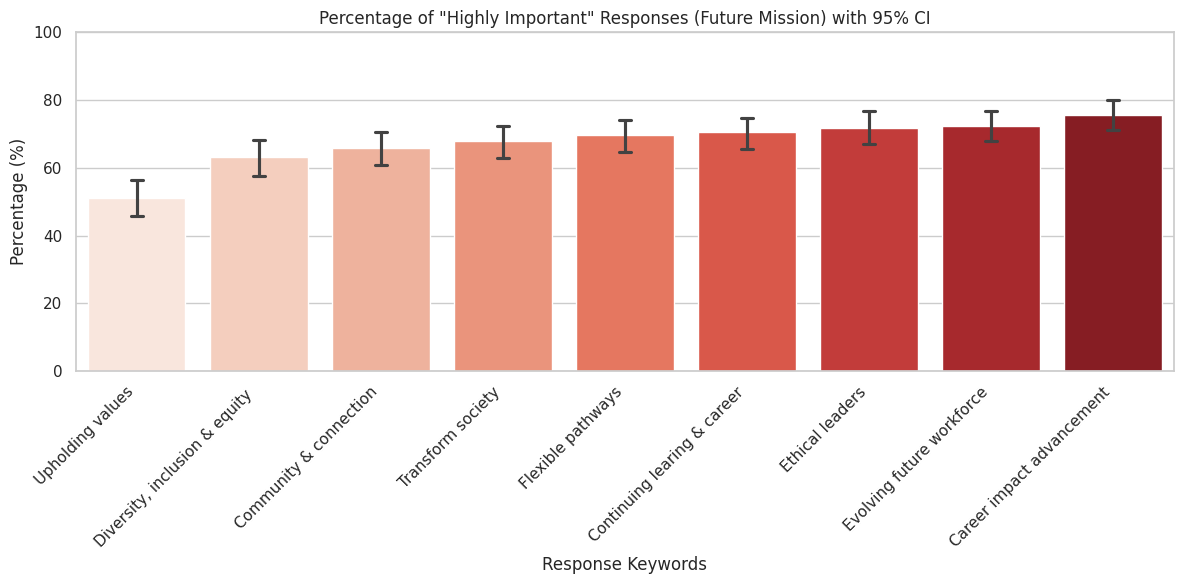

In [54]:
# Filter columns Q5_2_1 to Q5_2_9
q5_cols = [col for col in regroup_labeled_df.columns if col.startswith('Q5_2_') and col != 'Q5_2_0']

# Create mapping dictionary
label_mapping = {
    'Q5_2_1': 'Upholding values',
    'Q5_2_2': 'Flexible pathways',
    'Q5_2_3': 'Ethical leaders',
    'Q5_2_4': 'Diversity, inclusion & equity ',
    'Q5_2_5': 'Career impact advancement',
    'Q5_2_6': 'Continuing learing & career',
    'Q5_2_7': 'Community & connection',
    'Q5_2_8': 'Transform society',
    'Q5_2_9': 'Evolving future workforce'
}

# Prepare data in long format
q5_data = []
for col in q5_cols:
    for idx, value in regroup_labeled_df[col].items():
        q5_data.append({
            'Question': col,
            'Response': value,
            'is_highly_important': 1 if value == "Highly important" else 0
        })

q5_long = pd.DataFrame(q5_data)

# Calculate mean percentage for sorting
q5_means = q5_long.groupby('Question')['is_highly_important'].mean().mul(100).sort_values()

# Create the plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=q5_long,
    x='Question',
    y='is_highly_important',
    hue='Question',
    order=q5_means.index,
    hue_order=q5_means.index,
    palette='Reds',
    errorbar=('ci', 95),
    capsize=0.1,
    n_boot=1000,
    estimator=lambda x: np.mean(x) * 100
)

plt.xlabel('Response Keywords')
plt.ylabel('Percentage (%)')
plt.title('Percentage of "Highly Important" Responses (Future Mission) with 95% CI')
plt.ylim(0, 100)

# Replace x-axis labels with mapped values
ax = plt.gca()
labels = [label_mapping.get(item.get_text(), item.get_text()) for item in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3472725611.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


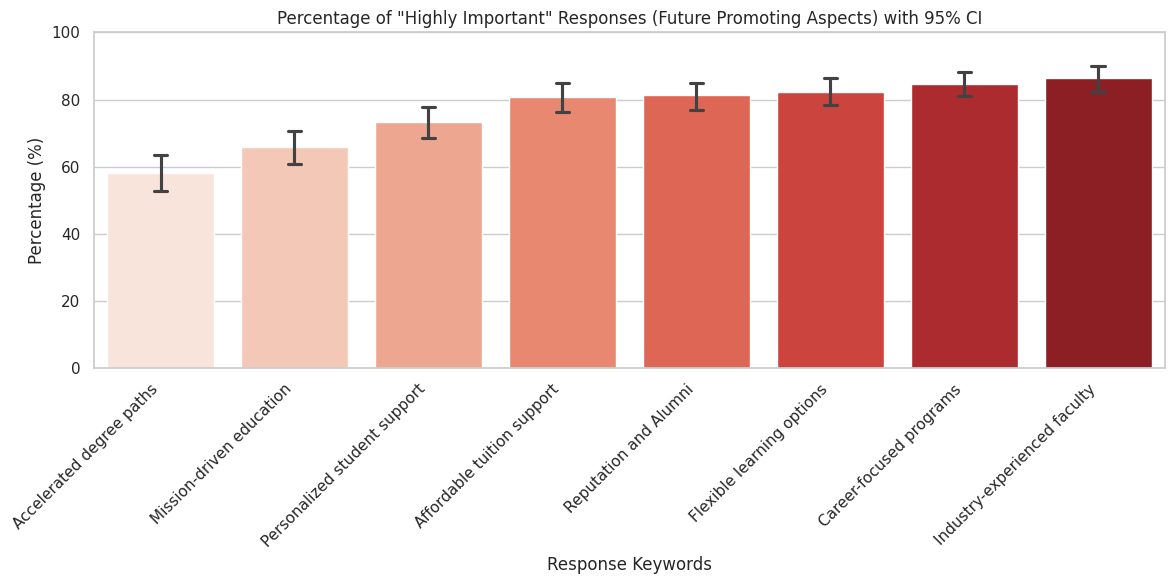

In [55]:
# Filter columns Q2_2_1 to Q2_2_8
q2_cols = [col for col in regroup_labeled_df.columns if col.startswith('Q2_2_')]

# Create mapping dictionary
label_mapping = {
    'Q2_2_1': 'Flexible learning options',
    'Q2_2_2': 'Career-focused programs',
    'Q2_2_3': 'Affordable tuition support',
    'Q2_2_4': 'Mission-driven education',
    'Q2_2_5': 'Personalized student support',
    'Q2_2_6': 'Accelerated degree paths',
    'Q2_2_7': 'Reputation and Alumni',
    'Q2_2_8': 'Industry-experienced faculty'
}


# Prepare data in long format
q2_data = []
for col in q2_cols:
    for idx, value in regroup_labeled_df[col].items():
        q2_data.append({
            'Question': col,
            'Response': value,
            'is_highly_important': 1 if value == "Highly important" else 0
        })

q2_long = pd.DataFrame(q2_data)

# Calculate mean percentage for sorting
q2_means = q2_long.groupby('Question')['is_highly_important'].mean().mul(100).sort_values()

# Create the plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=q2_long,
    x='Question',
    y='is_highly_important',
    hue ='Question',
    order=q2_means.index,  # Sort by height
    hue_order=q2_means.index,
    palette='Reds',
    errorbar=('ci', 95),
    capsize=0.1,
    n_boot=1000,
    estimator=lambda x: np.mean(x) * 100  # Convert to percentage
)

plt.xlabel('Response Keywords')
plt.ylabel('Percentage (%)')
plt.title('Percentage of "Highly Important" Responses (Future Promoting Aspects) with 95% CI')
plt.ylim(0, 100)

# Replace x-axis labels with mapped values
ax = plt.gca()
labels = [label_mapping.get(item.get_text(), item.get_text()) for item in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [56]:
# Filter columns Q3_2_1 to Q3_2_7
q3_cols = [col for col in regroup_labeled_df.columns if col.startswith('Q3_2_')]

print(f"Found columns: {q3_cols}")  # Debug: check what columns were found

# Prepare data in long format
q3_data = []
for col in q3_cols:
    for idx, value in regroup_labeled_df[col].items():
        q3_data.append({
            'Question': col,
            'Response': value,
            'is_highly_important': 1 if value == "Highly important" else 0
        })

q3_long = pd.DataFrame(q3_data)

print(f"Q3_long shape: {q3_long.shape}")  # Debug: check dataframe size
print(f"Q3_long head:\n{q3_long.head()}")  # Debug: check first few rows

# Only proceed if we have data
if len(q3_long) > 0:
    # Calculate mean percentage for sorting
    q3_means = q3_long.groupby('Question')['is_highly_important'].mean().mul(100).sort_values()

    # Create the plot
    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=q3_long,
        x='Question',
        y='is_highly_important',
        order=q3_means.index,  # Sort by height
        palette='gray_r',
        errorbar=('ci', 95),
        capsize=0.1,
        n_boot=1000,
        estimator=lambda x: np.mean(x) * 100  # Convert to percentage
    )

    plt.xlabel('Question')
    plt.ylabel('Percentage (%)')
    plt.title('Percentage of "Highly Important" Responses (Q3_2_1 to Q3_2_7) with 95% CI')
    plt.ylim(0, 100)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No Q3_2_ columns found or no data available")

Found columns: []
Q3_long shape: (0, 0)
Q3_long head:
Empty DataFrame
Columns: []
Index: []
No Q3_2_ columns found or no data available


In [57]:
# Select all columns that match your desired ranges
cols_3_2 = [f'Q3.2_{i}' for i in range(1, 8)]

# Filter your DataFrame
student_3_2 = student_cleaned[cols_3_2]
staff_3_2 = staff_cleaned[cols_3_2]
faculty_3_2 = faculty_cleaned[cols_3_2]

# Preview result
student_3_2.head()
staff_3_2.head()
faculty_3_2.head()


,Q3.2_1,Q3.2_2,Q3.2_3,Q3.2_4,Q3.2_5,Q3.2_6,Q3.2_7
0,Moderately important,Moderately important,Moderately important,Moderately important,Moderately important,Very important,Extremely important
1,Very important,Extremely important,Very important,Very important,Moderately important,Very important,Moderately important
2,Moderately important,Slightly important,Very important,Very important,Not Important,Moderately important,Very important
3,Moderately important,Extremely important,Extremely important,Moderately important,Moderately important,Extremely important,Extremely important
4,Moderately important,Very important,Very important,Moderately important,Moderately important,Extremely important,Extremely important


In [58]:
# Check column names
print("Student columns:", list(student_3_2.columns))
print("Faculty columns:", list(faculty_3_2.columns))
print("Staff columns:", list(staff_3_2.columns))

Student columns: ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']
Faculty columns: ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']
Staff columns: ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']


In [59]:
# Compare column sets
columns_match = (list(student_3_2.columns) == list(faculty_3_2.columns) == list(staff_3_2.columns))
print("Do all three datasets have the same columns?", columns_match)

Do all three datasets have the same columns? True


In [60]:
faculty_3_2['dataset'] = 'faculty'
student_3_2['dataset'] = 'student'
staff_3_2['dataset'] = 'staff'

/tmp/ipython-input-1199526808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faculty_3_2['dataset'] = 'faculty'
/tmp/ipython-input-1199526808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_3_2['dataset'] = 'student'
/tmp/ipython-input-1199526808.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [61]:
combined_3_2 = pd.concat([student_3_2, faculty_3_2, staff_3_2], ignore_index=True)
combined_3_2.head()
#combined_3_2.shape

,Q3.2_1,Q3.2_2,Q3.2_3,Q3.2_4,Q3.2_5,Q3.2_6,Q3.2_7,dataset
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student
1,Moderately important,Very important,NaN,Very important,Very important,Very important,Very important,student
2,Moderately important,Very important,Very important,Very important,Very important,Very important,Very important,student
3,Moderately important,Not Important,Very important,Not Important,Not Important,Not Important,Extremely important,student
4,Moderately important,Very important,Very important,Moderately important,Moderately important,Very important,Extremely important,student


In [62]:
combined_3_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Q3.2_1   322 non-null    object
 1   Q3.2_2   320 non-null    object
 2   Q3.2_3   321 non-null    object
 3   Q3.2_4   322 non-null    object
 4   Q3.2_5   318 non-null    object
 5   Q3.2_6   322 non-null    object
 6   Q3.2_7   322 non-null    object
 7   dataset  352 non-null    object
dtypes: object(8)
memory usage: 22.1+ KB


In [63]:
# Step 1: Define direct mapping to three groups
importance_groups = {
    'not at all important': 'Not important',
    'slightly important': 'Moderately important',
    'moderately important': 'Moderately important',
    'very important': 'Highly important',
    'extremely important': 'Highly important'
}

# Step 2: Function to map text directly to groups
def map_to_groups(x):
    if pd.isna(x):
        return np.nan
    x_clean = str(x).strip().lower()
    return importance_groups.get(x_clean, np.nan)

# Step 3: Select columns to map
cols_to_map = ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']

# Step 4: Apply mapping to selected columns
combined_3_2[cols_to_map] = combined_3_2[cols_to_map].applymap(map_to_groups)

# Step 5: Verify the mapping
for col in cols_to_map:
    print(col, combined_3_2[col].unique())

Q3.2_1 [nan 'Moderately important' 'Highly important']
Q3.2_2 [nan 'Highly important' 'Moderately important']
Q3.2_3 [nan 'Highly important' 'Moderately important']
Q3.2_4 [nan 'Highly important' 'Moderately important']
Q3.2_5 [nan 'Highly important' 'Moderately important']
Q3.2_6 [nan 'Highly important' 'Moderately important']
Q3.2_7 [nan 'Highly important' 'Moderately important']


/tmp/ipython-input-84431052.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined_3_2[cols_to_map] = combined_3_2[cols_to_map].applymap(map_to_groups)


In [64]:
## Percentage Table for Q3.2 Questions

# --- Step 1: Calculate percentage of each response for each column ---
percentage_tables = {}

for col in ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']:
    # Count occurrences of each category
    counts = combined_3_2[col].value_counts(dropna=True)

    # Convert to percentages
    percentages = (counts / counts.sum() * 100).round(1)

    # Store results
    percentage_tables[col] = percentages

# Combine into a single DataFrame for easy viewing
percentage_3_2 = pd.DataFrame(percentage_tables).fillna(0).T  # transpose for readability

print("=== Percentage distribution for Q3.2 questions ===")
print(percentage_3_2)

=== Percentage distribution for Q3.2 questions ===
        Highly important  Moderately important
Q3.2_1              64.6                  35.4
Q3.2_2              67.0                  33.0
Q3.2_3              82.0                  18.0
Q3.2_4              58.6                  41.4
Q3.2_5              27.7                  72.3
Q3.2_6              56.9                  43.1
Q3.2_7              80.6                  19.4


/tmp/ipython-input-3505070481.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


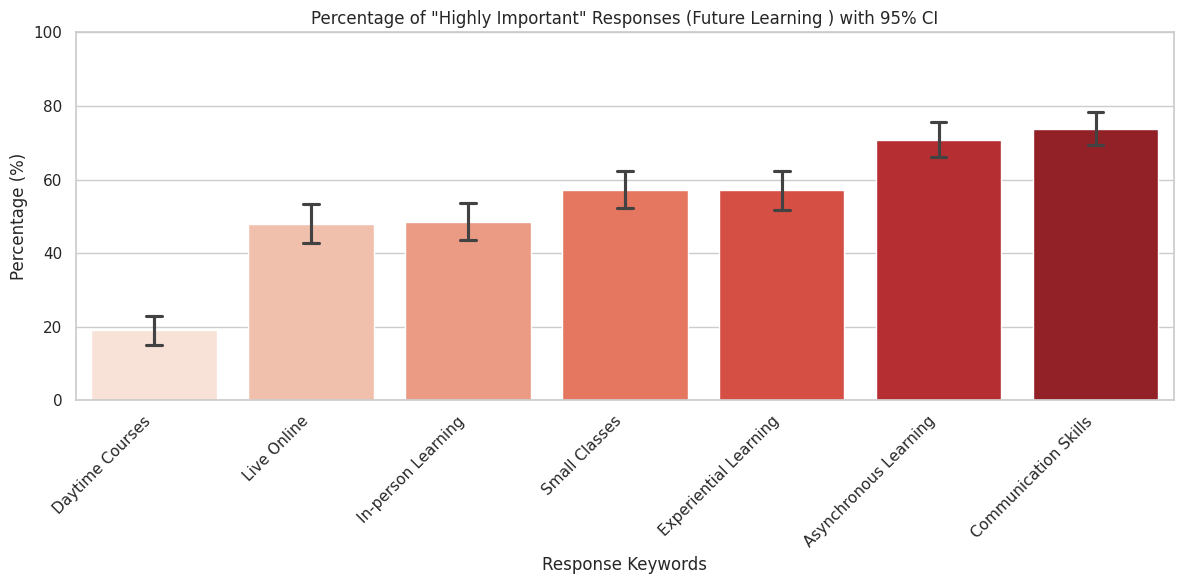

In [67]:
# Filter columns Q3.2_1 to Q3.2_7
q3_cols = ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']

# Create mapping dictionary
label_mapping = {
    'Q3.2_1': 'Small Classes',
    'Q3.2_2': 'Experiential Learning',
    'Q3.2_3': 'Communication Skills',
    'Q3.2_4': 'In-person Learning',
    'Q3.2_5': 'Daytime Courses',
    'Q3.2_6': 'Live Online',
    'Q3.2_7': 'Asynchronous Learning'
}

# Prepare data in long format
q3_data = []
for col in q3_cols:
    for idx, value in combined_3_2[col].items():
        q3_data.append({
            'Question': col,
            'Response': value,
            'is_highly_important': 1 if value == "Highly important" else 0
        })

q3_long = pd.DataFrame(q3_data)

# Calculate mean percentage for sorting
q3_means = q3_long.groupby('Question')['is_highly_important'].mean().mul(100).sort_values()

# Create the plot
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=q3_long,
    x='Question',
    y='is_highly_important',
    hue='Question',
    order=q3_means.index,
    hue_order=q3_means.index,
    palette='Reds',
    errorbar=('ci', 95),
    capsize=0.1,
    n_boot=1000,
    estimator=lambda x: np.mean(x) * 100
)

plt.xlabel('Response Keywords')
plt.ylabel('Percentage (%)')
plt.title('Percentage of "Highly Important" Responses (Future Learning ) with 95% CI')
plt.ylim(0, 100)

# Replace x-axis labels with mapped values
ax = plt.gca()
labels = [label_mapping.get(item.get_text(), item.get_text()) for item in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

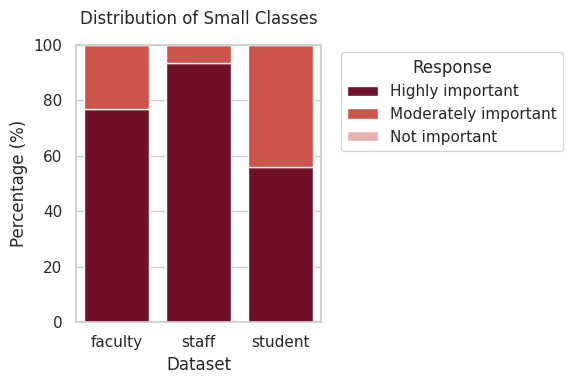

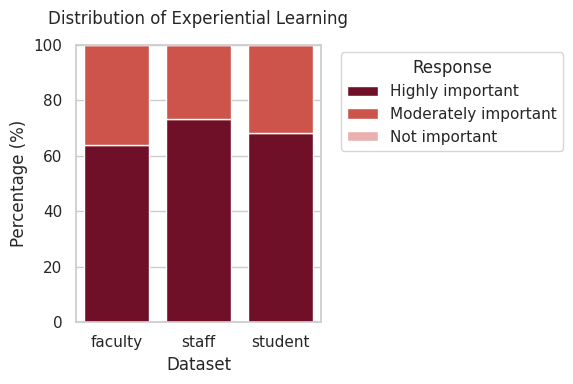

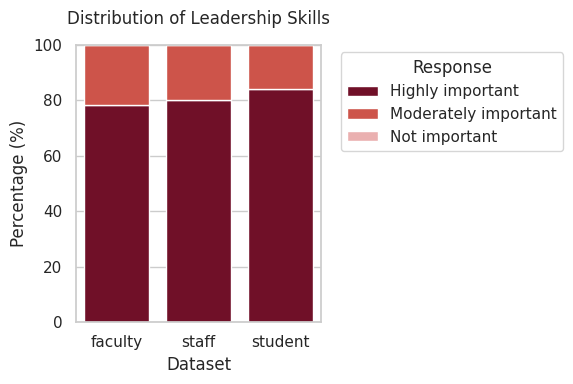

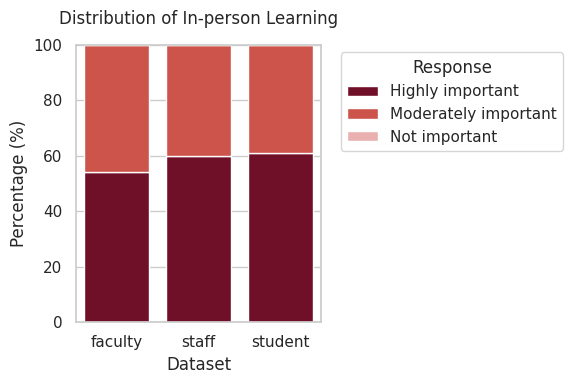

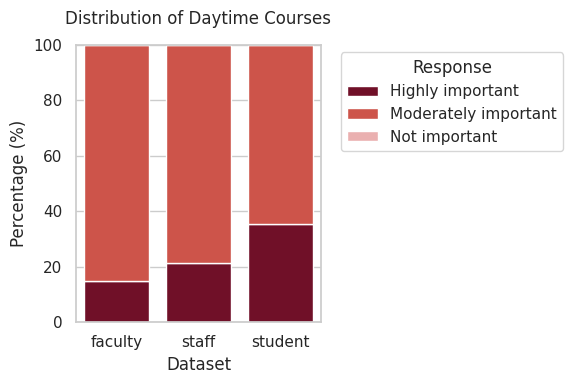

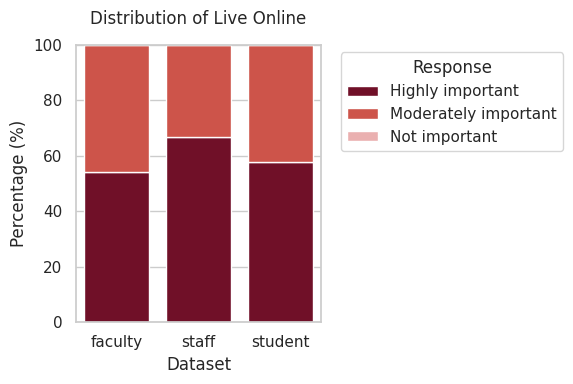

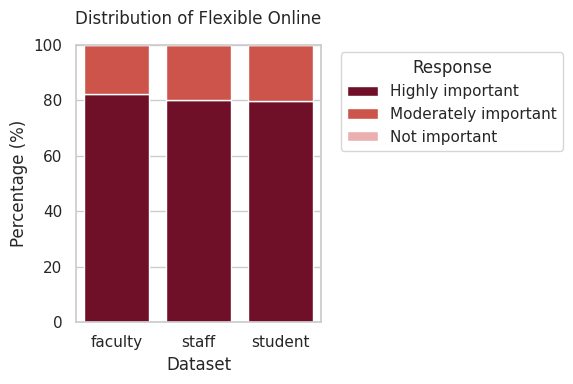

In [66]:
## Stacked Bar Charts for Q3.2
# --- Step 1: Define the response order (so colors stay consistent) ---
response_order = ["Highly important", "Moderately important", "Not important"]

# --- Step 2: Define the mapping for titles ---
title_mapping = {
    'Q3.2_1': 'Small Classes',
    'Q3.2_2': 'Experiential Learning',
    'Q3.2_3': 'Leadership Skills',
    'Q3.2_4': 'In-person Learning',
    'Q3.2_5': 'Daytime Courses',
    'Q3.2_6': 'Live Online',
    'Q3.2_7': 'Flexible Online'
}

# --- Step 3: Loop through each question ---
q3_cols = ['Q3.2_1', 'Q3.2_2', 'Q3.2_3', 'Q3.2_4', 'Q3.2_5', 'Q3.2_6', 'Q3.2_7']

for col in q3_cols:
    # Calculate percentage distribution by dataset
    grouped = (
        combined_3_2.groupby("dataset")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )

    # Pivot to wide format
    pivot = grouped.pivot(index="dataset", columns=col, values="Percentage").fillna(0)

    # Reorder columns for consistent color order
    pivot = pivot.reindex(columns=response_order, fill_value=0)

    # --- Step 4: Plot stacked bar chart using seaborn.barplot ---
    plt.figure(figsize=(6, 4))
    bottom = None
    for response in response_order:
        sns.barplot(
            x=pivot.index,
            y=pivot[response],
            label=response,
            color=["#800020", "#E34234", "#F4A6A6"][response_order.index(response)], # use consistent colors
            bottom=bottom,
            errorbar=('ci', 95) # display 95% confidence interval
        )
        if bottom is None:
            bottom = pivot[response]
        else:
            bottom += pivot[response]

    # Get the title text from mapping
    title_text = title_mapping.get(col, col)  # fallback to col if not in mapping
    plt.title(f"Distribution of {title_text}", fontsize=12, pad=15)  # pad adds space
    plt.ylabel("Percentage (%)")
    plt.xlabel("Dataset")
    plt.xticks(rotation=0)
    plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()